# III. Prescriptive / Multivariate Analysis

## Hospitalized Patients with Heart Failure

### Objective

The Descriptive Analysis established the baseline characteristics, clinical severity, comorbidity burden, laboratory patterns, treatment patterns, hospitalization outcomes, and readmission/mortality rates in the cohort.

The Prescriptive / Multivariate Analysis builds on those findings by investigating relationships between multiple clinical, demographic, treatment, and outcome variables.

The objective is to identify:

- factors associated with clinical severity and outcomes,
- combinations of factors that identify different patient profiles,
- relationships between clinical condition and hospitalization/resource use,
- factors that provide information beyond individual severity measures,
- and evidence-supported candidate features for the Predictive Analysis.

Rather than analyzing variables independently, this stage focuses on clinically meaningful relationships and combinations of variables.

### Analytical Flow

Descriptive Findings
        ↓
Identify Important Patterns
        ↓
Formulate Analytical Questions
        ↓
Test Relationships and Interactions
        ↓
Identify Meaningful Patient Profiles
        ↓
Evaluate Incremental Information
        ↓
Select Evidence-Supported Candidate Predictors
        ↓
Predictive Analysis

## 1. Import Libraries
The Prescriptive Analysis requires statistical comparisons, association testing, subgroup analysis, and visualization.
We will use a focused set of Python libraries rather than importing unnecessary packages.


In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf


# Statistical analysis
from scipy import stats
from scipy.stats import chi2
from scipy.stats import chi2_contingency
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Cleaned Master Patient Dataset
The data-cleaning stage has already produced the patient-level analytical dataset.

The Prescriptive Analysis should use the cleaned master dataset so that all questions are based on the same patient population and the same previously validated definitions.

#### What will we do?
Load the finalized `patient_master.csv` created during the Data Cleaning stage.

A single patient-level dataset containing the clinical, demographic, hospitalization, outcome, and treatment information required for the Prescriptive Analysis.

In [180]:
from pathlib import Path

# Try the team's shared folder structure first,
# then common locations relative to this notebook.

MASTER_FILE = "Team11_PyInsights_cleaned_data.csv"

DATA_PATH = Path(
    r"C:\Users\arjai\Documents\Shraddha Job Search\Data Science\Python\Hackathon Sept 2026\Python_Hackathon_Sep_2026"
)

candidates = [
    DATA_PATH / "cleaned_data" / MASTER_FILE
]

# Also check locations relative to the notebook
for base in [Path.cwd(), *Path.cwd().parents]:
    candidates += [
        base / "cleaned_data" / MASTER_FILE,
        base / MASTER_FILE
    ]

MASTER_PATH = next(
    (p for p in candidates if p.is_file()),
    None
)

if MASTER_PATH is None:
    raise FileNotFoundError(
        f"Could not find {MASTER_FILE}. "
        "Make sure the cleaned master file is available "
        "in the cleaned_data folder."
    )

CLEANED_PATH = MASTER_PATH.parent

df = pd.read_csv(MASTER_PATH)

print("Master dataset loaded:", MASTER_PATH)
print(f"Rows: {len(df):,}; columns: {df.shape[1]:,}")

Master dataset loaded: C:\Users\arjai\Documents\Shraddha Job Search\Data Science\Python\Hackathon Sept 2026\Python_Hackathon_Sep_2026\cleaned_data\Team11_PyInsights_cleaned_data.csv
Rows: 2,008; columns: 198


## 3. Analytical Dataset Validation

Before beginning multivariate analysis, we need to confirm that the analytical dataset has the expected patient-level structure.
This prevents accidental use of duplicate records, incorrect joins, or unexpected changes to the cleaned dataset.

- Number of patients
- Unique patient identifiers
- Duplicate patient records
- Availability of key variables
- Data types of variables used in Category 3

Confirm that the Prescriptive Analysis is based on the same 2,008-patient master cohort established during data cleaning.

In [3]:
# Verify patient-level structure and names from the final cleaning notebook.
print("Dataset shape:", df.shape)
print("Unique patients:", df["inpatient_number"].nunique())
print("Duplicate patient IDs:", df["inpatient_number"].duplicated().sum())
key_variables = [
    "inpatient_number", "glomerular_filtration_rate", "cci_score",
    "nyha_cardiac_function_classification", "killip_grade",
    "brain_natriuretic_peptide", "dischargeday",
    "re_admission_within_6_months", "death_within_6_months",
    "age_category", "diabetes", "moderate_to_severe_chronic_kidney_disease"
]
available = [name for name in key_variables if name in df.columns]
missing = [name for name in key_variables if name not in df.columns]
print("Available:", available)
print("Missing:", missing)
if missing or df["inpatient_number"].duplicated().any():
    raise ValueError("The master CSV does not match the final cleaned patient dataset.")

Dataset shape: (2008, 198)
Unique patients: 2008
Duplicate patient IDs: 0
Available: ['inpatient_number', 'glomerular_filtration_rate', 'cci_score', 'nyha_cardiac_function_classification', 'killip_grade', 'brain_natriuretic_peptide', 'dischargeday', 're_admission_within_6_months', 'death_within_6_months', 'age_category', 'diabetes', 'moderate_to_severe_chronic_kidney_disease']
Missing: []


### 4. Transition from Descriptive to Prescriptive / Multivariate Analysis

The Descriptive Analysis established several important characteristics of the cohort.

Key observations included:

- A substantial proportion of patients had reduced renal function based on measured GFR.
- The prevalence of the CKD indicator was lower than the proportion with measured GFR <60 mL/min/1.73 m².
- Admission severity was characterized using NYHA and Killip classifications.
- BNP showed a strongly right-skewed distribution and varied across NYHA severity groups.
- Comorbidity burden was present across the cohort, with CKD and diabetes among the more prevalent conditions.
- Six-month readmission occurred considerably more frequently than six-month mortality.
- Length of stay varied across patients, and exploratory analysis showed an association between medication burden and length of stay.

These findings generate questions that cannot be answered by descriptive statistics alone.

The Prescriptive / Multivariate Analysis therefore moves from:

**"What do we observe?"**

to: **"How are these factors related, do they provide additional information when considered together, and which combinations identify meaningful patient profiles?"**

## Section 1 — Renal Function & Admission Severity

### Q1. Does the CKD flag identify the same renal-risk population as measured GFR <60 mL/min/1.73m²?

**Why:** Descriptive analysis flagged a gap between the coded CKD comorbidity indicator and the share of patients with measured GFR<60. The data dictionary defines that exact indicator using the same <60 cutoff, so the two should largely agree — testing whether they actually do determines which one we trust as the primary renal-risk variable for every downstream question in this section.

**What We Expect:** Given the shared cutoff, we expect substantial but not perfect overlap — some disagreement is plausible if the CKD flag reflects a historical diagnosis while GFR reflects current lab values, but a large gap would suggest the flag under-captures current renal risk.

moderate_to_severe_chronic_kidney_disease,CKD not flagged,CKD flagged
low_gfr,,
GFR >=60,1003,55
GFR <60,479,406


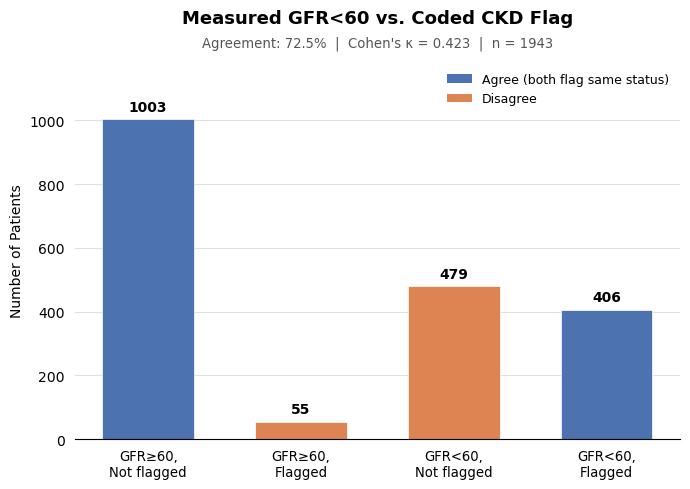

In [4]:
# Recreate the contingency table so the starter Q1 chart works when run from the top.
q1 = df[["glomerular_filtration_rate", "moderate_to_severe_chronic_kidney_disease"]].copy()
q1["glomerular_filtration_rate"] = pd.to_numeric(q1["glomerular_filtration_rate"], errors="coerce")
q1["moderate_to_severe_chronic_kidney_disease"] = pd.to_numeric(
    q1["moderate_to_severe_chronic_kidney_disease"], errors="coerce"
)
q1 = q1.dropna()
q1 = q1[q1["moderate_to_severe_chronic_kidney_disease"].isin([0, 1])]
q1["low_gfr"] = (q1["glomerular_filtration_rate"] < 60).astype(int)
ct = pd.crosstab(q1["low_gfr"], q1["moderate_to_severe_chronic_kidney_disease"])
ct = ct.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
n = int(ct.to_numpy().sum())
if n == 0:
    raise ValueError("No usable GFR and CKD flag pairs for the Q1 chart.")
po = (ct.loc[0, 0] + ct.loc[1, 1]) / n
row_share = ct.sum(axis=1) / n
col_share = ct.sum(axis=0) / n
pe = row_share.loc[0] * col_share.loc[0] + row_share.loc[1] * col_share.loc[1]
kappa = (po - pe) / (1 - pe) if pe < 1 else float("nan")
display(ct.rename(index={0: "GFR >=60", 1: "GFR <60"},
                  columns={0: "CKD not flagged", 1: "CKD flagged"}))

# Visualization — cleaner version
fig, ax = plt.subplots(figsize=(7, 5))

labels = ["GFR≥60,\nNot flagged", "GFR≥60,\nFlagged", "GFR<60,\nNot flagged", "GFR<60,\nFlagged"]
values = [ct.loc[0,0], ct.loc[0,1], ct.loc[1,0], ct.loc[1,1]]

agree_color = "#4C72B0"     # the two cells where GFR and flag agree
disagree_color = "#DD8452"  # the two cells where they disagree
colors = [agree_color, disagree_color, disagree_color, agree_color]

bars = ax.bar(labels, values, color=colors, width=0.6, edgecolor="white", linewidth=0.5)

# Labels above bars, with enough headroom so nothing touches the top
ax.bar_label(bars, padding=4, fontsize=10, fontweight="bold")
ax.set_ylim(0, max(values) * 1.18)

# Clean up the frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(left=False, bottom=False)

ax.set_ylabel("Number of Patients", fontsize=10)
ax.set_title("Measured GFR<60 vs. Coded CKD Flag", fontsize=13, fontweight="bold", pad=28)
ax.text(0.5, 1.04, f"Agreement: {po*100:.1f}%  |  Cohen's κ = {kappa:.3f}  |  n = {n}",
        transform=ax.transAxes, ha="center", fontsize=9.5, color="#555555")

plt.xticks(fontsize=9.5)

# Legend explaining the color coding
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=agree_color, label="Agree (both flag same status)"),
    Patch(facecolor=disagree_color, label="Disagree"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

**Finding**

885/1,943 (45.55%) have GFR<60; only 461 (23.73%) carry the CKD flag. 479 patients (24.7%) are low-GFR but unflagged; only 55 (2.8%) are flagged with normal GFR. Agreement = 72.5%, but Cohen's κ = 0.423 (moderate, not strong). Chi-square p ≈ 2.46e-97 — significant, but with n=1,943 that reflects sample size, not interchangeability.

**Observation & Implication**

The two measures disagree more than they agree meaningfully (κ=0.423), and the flag under-catches far more than it over-flags. Measured GFR will be used as the primary renal-function variable going forward; the CKD flag stays separate as a comorbidity variable, not a GFR proxy. Sets up Q2 (GFR vs. severity) using the lab value.

**Counter-Argument:** CKD is a chronic diagnosis — some "missed" patients may just have a normal GFR at this admission despite a history of impairment. Doesn't change the choice: current GFR is still the right variable for a cross-sectional analysis.

### Q2. Is reduced GFR associated with greater admission severity as measured by NYHA and Killip?

**Why:** Q1 established that measured GFR is the more reliable renal-function variable going forward. We now test whether reduced renal function is associated with greater clinical severity at admission — checking both NYHA and Killip since they measure different aspects of severity.

**What We Expect:** Physiologically, worse cardiac function should coincide with worse renal function (cardiorenal syndrome) — we expect both NYHA and Killip to show lower GFR at higher severity classes.

In [5]:
# Q2 — GFR vs. admission severity (NYHA and Killip)

q2 = df[["glomerular_filtration_rate",
         "nyha_cardiac_function_classification",
         "killip_grade"]].copy()
q2 = q2.dropna()
q2["GFR_Risk"] = np.where(q2["glomerular_filtration_rate"] < 60, "GFR <60", "GFR >=60")

print(f"Patients analyzed: {len(q2):,}")
print(q2["GFR_Risk"].value_counts())

# --- NYHA vs GFR group ---
nyha_table = pd.crosstab(q2["GFR_Risk"], q2["nyha_cardiac_function_classification"])
nyha_pct = pd.crosstab(q2["GFR_Risk"], q2["nyha_cardiac_function_classification"], normalize="index") * 100
chi2_n, p_n, dof_n, _ = stats.chi2_contingency(nyha_table)
print("\nNYHA distribution by GFR group (%):\n", nyha_pct.round(1))
print(f"NYHA vs GFR: chi2={chi2_n:.3f}, dof={dof_n}, p={p_n:.6f}")

# --- Killip vs GFR group ---
killip_table = pd.crosstab(q2["GFR_Risk"], q2["killip_grade"])
killip_pct = pd.crosstab(q2["GFR_Risk"], q2["killip_grade"], normalize="index") * 100
chi2_k, p_k, dof_k, _ = stats.chi2_contingency(killip_table)
print("\nKillip distribution by GFR group (%):\n", killip_pct.round(1))
print(f"Killip vs GFR: chi2={chi2_k:.3f}, dof={dof_k}, p={p_k:.6f}")

# --- Median GFR by severity class ---
print("\nGFR by NYHA class:\n", q2.groupby("nyha_cardiac_function_classification")["glomerular_filtration_rate"]
      .agg(Count="count", Median="median", Mean="mean").round(2))
print("\nGFR by Killip class:\n", q2.groupby("killip_grade")["glomerular_filtration_rate"]
      .agg(Count="count", Median="median", Mean="mean").round(2))

# --- Spearman correlations ---
rho_n, p_rn = stats.spearmanr(q2["nyha_cardiac_function_classification"], q2["glomerular_filtration_rate"])
rho_k, p_rk = stats.spearmanr(q2["killip_grade"], q2["glomerular_filtration_rate"])
print(f"\nSpearman NYHA vs GFR: rho={rho_n:.3f}, p={p_rn:.6f}")
print(f"Spearman Killip vs GFR: rho={rho_k:.3f}, p={p_rk:.6f}")

Patients analyzed: 1,945
GFR_Risk
GFR >=60    1059
GFR <60      886
Name: count, dtype: int64

NYHA distribution by GFR group (%):
 nyha_cardiac_function_classification      2      3      4
GFR_Risk                                                 
GFR <60                              14.300 49.900 35.800
GFR >=60                             20.000 53.800 26.200
NYHA vs GFR: chi2=25.006, dof=2, p=0.000004

Killip distribution by GFR group (%):
 killip_grade      1      2      3     4
GFR_Risk                               
GFR <60      22.600 54.000 19.400 4.100
GFR >=60     29.200 48.900 19.800 2.100
Killip vs GFR: chi2=16.853, dof=3, p=0.000758

GFR by NYHA class:
                                       Count  Median   Mean
nyha_cardiac_function_classification                      
2                                       339  70.130 73.470
3                                      1012  67.230 71.120
4                                       594  56.820 61.740

GFR by Killip class:
        

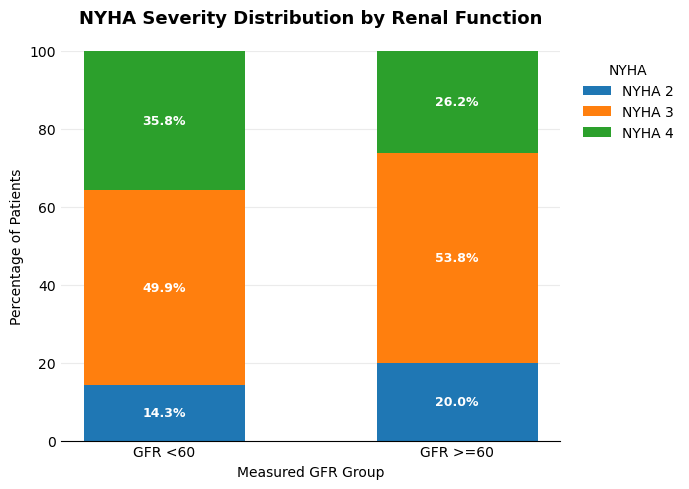

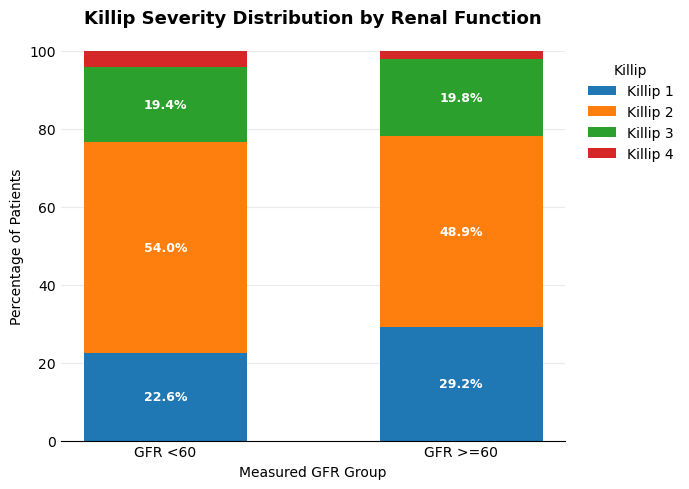

In [6]:
# Q2 Visualizations — severity distribution by GFR group

def plot_severity_by_gfr(pct_table, title_label):
    fig, ax = plt.subplots(figsize=(7, 5))
    pct_table = pct_table.reindex(columns=sorted(pct_table.columns))
    bottom = np.zeros(len(pct_table))
    for cls in pct_table.columns:
        values = pct_table[cls].values
        ax.bar(pct_table.index, values, bottom=bottom, width=0.55, label=f"{title_label} {cls}")
        for i, v in enumerate(values):
            if v >= 5:
                ax.text(i, bottom[i] + v/2, f"{v:.1f}%", ha="center", va="center",
                        fontsize=9, fontweight="bold", color="white")
        bottom += values

    ax.set_title(f"{title_label} Severity Distribution by Renal Function", fontsize=13, fontweight="bold", pad=20)
    ax.set_ylabel("Percentage of Patients")
    ax.set_xlabel("Measured GFR Group")
    ax.set_ylim(0, 100)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.yaxis.grid(True, alpha=0.25)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    ax.legend(title=title_label, frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_severity_by_gfr(nyha_pct, "NYHA")
plot_severity_by_gfr(killip_pct, "Killip")

#### Finding

Both NYHA and Killip are significantly associated with GFR group (NYHA: chi2=25.0, p=0.000004; Killip: chi2=16.9, p=0.00076), and median GFR declines across NYHA classes (70.1 → 67.2 → 56.8). But the Spearman correlations are weak (NYHA rho=-0.132; Killip rho=-0.085) — significant mainly because n is large (1,945). Killip's relationship isn't even monotonic (median GFR dips at class 2, partly recovers at class 3).

#### Observation & Implication

Cardiorenal syndrome is present but weak, and NYHA tracks it more cleanly than Killip. Statistical significance here reflects sample size, not a strong relationship — this won't be pitched as a headline finding. **NYHA is the preferred severity variable when pairing with renal function in later questions**; Killip's non-monotonic pattern makes it noisier for this specific comparison.

**Counter-Argument:** Killip reflects acute hemodynamic congestion at admission, not chronic organ damage — it may simply not be expected to track a chronic marker like GFR as tightly as NYHA does. That's a reason the weak Killip result isn't a flaw, not evidence against the analysis.

### Q3. Does reduced GFR (<60) predict 6-month readmission?

**Why:** Q1 established measured GFR as the primary renal-function variable; Q2 showed it has only a weak link to admission severity. This question tests GFR directly against the outcome that matters — 6-month readmission — using the full-power outcome variable identified early in this project.

**What We Expect:** Given the cardiorenal literature, we expect patients with GFR<60 to have a meaningfully higher 6-month readmission rate than patients with normal renal function.

In [7]:
# ============================================================
# Q3. GFR <60 vs. 6-Month Readmission
# ============================================================

# ------------------------------------------------------------
# 1. Create Q3 analysis dataset
# ------------------------------------------------------------
q3 = df[
    [
        "glomerular_filtration_rate",
        "re_admission_within_6_months"
    ]
].dropna().copy()

# Create GFR risk group
q3["GFR_Risk"] = np.where(
    q3["glomerular_filtration_rate"] < 60,
    "GFR <60",
    "GFR ≥60"
)

# ------------------------------------------------------------
# 2. Basic dataset information
# ------------------------------------------------------------
print("=" * 60)
print("Q3 ANALYSIS: GFR <60 vs. 6-MONTH READMISSION")
print("=" * 60)

print(f"\nPatients analyzed: {len(q3):,}")

print("\nPatients by GFR group:")
print(
    q3["GFR_Risk"]
    .value_counts()
    .reindex(["GFR <60", "GFR ≥60"])
)

# ------------------------------------------------------------
# 3. Cross-tabulation
# ------------------------------------------------------------
ct = pd.crosstab(
    q3["GFR_Risk"],
    q3["re_admission_within_6_months"]
)

# Make sure both outcome columns are present
ct = ct.reindex(
    index=["GFR <60", "GFR ≥60"],
    columns=[0, 1],
    fill_value=0
)

ct.columns = [
    "No 6M Readmission",
    "6M Readmission"
]

print("\n6-Month Readmission Counts:")
display(ct)

# ------------------------------------------------------------
# 4. Readmission rates
# ------------------------------------------------------------
rate_low = (
    q3.loc[
        q3["GFR_Risk"] == "GFR <60",
        "re_admission_within_6_months"
    ].mean()
)

rate_normal = (
    q3.loc[
        q3["GFR_Risk"] == "GFR ≥60",
        "re_admission_within_6_months"
    ].mean()
)

absolute_difference = rate_low - rate_normal

relative_risk = rate_low / rate_normal

print("\n6-Month Readmission Rates:")
print(f"GFR <60 : {rate_low * 100:.1f}%")
print(f"GFR ≥60 : {rate_normal * 100:.1f}%")

print(
    f"\nAbsolute difference: "
    f"{absolute_difference * 100:.1f} percentage points"
)

print(
    f"Relative risk: "
    f"{relative_risk:.2f}x"
)

# ------------------------------------------------------------
# 5. Chi-square test
# ------------------------------------------------------------
chi2, p, dof, expected = stats.chi2_contingency(ct)

print("\nChi-Square Test:")
print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.6f}")

# ------------------------------------------------------------
# 6. Odds ratio
# ------------------------------------------------------------
a = ct.loc["GFR <60", "6M Readmission"]
b = ct.loc["GFR <60", "No 6M Readmission"]

c = ct.loc["GFR ≥60", "6M Readmission"]
d = ct.loc["GFR ≥60", "No 6M Readmission"]

odds_ratio = (a * d) / (b * c)

print(f"\nOdds ratio: {odds_ratio:.2f}")

# ------------------------------------------------------------
# 7. Cramer's V
# ------------------------------------------------------------
n = ct.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(ct.shape) - 1))
)

print(f"Cramer's V: {cramers_v:.3f}")

Q3 ANALYSIS: GFR <60 vs. 6-MONTH READMISSION

Patients analyzed: 1,945

Patients by GFR group:
GFR_Risk
GFR <60     886
GFR ≥60    1059
Name: count, dtype: int64

6-Month Readmission Counts:


,No 6M Readmission,6M Readmission
GFR_Risk,,
GFR <60,489,397
GFR ≥60,703,356



6-Month Readmission Rates:
GFR <60 : 44.8%
GFR ≥60 : 33.6%

Absolute difference: 11.2 percentage points
Relative risk: 1.33x

Chi-Square Test:
Chi-square statistic: 24.996
Degrees of freedom: 1
P-value: 0.000001

Odds ratio: 1.60
Cramer's V: 0.113


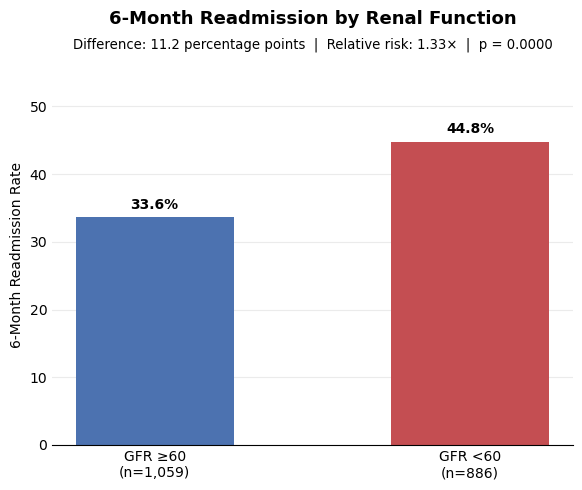

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
rates = [rate_normal * 100, rate_low * 100]
labels = ["GFR ≥60\n(n=1,059)", "GFR <60\n(n=886)"]
colors = ["#4C72B0", "#C44E52"]

bars = ax.bar(labels, rates, color=colors, width=0.5)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontweight="bold")
ax.set_ylim(0, max(rates) * 1.25)
ax.set_ylabel("6-Month Readmission Rate")
ax.set_title("6-Month Readmission by Renal Function", fontsize=13, fontweight="bold", pad=30)
ax.text(
    0.5,
    1.035,
    (
        f"Difference: {absolute_difference * 100:.1f} percentage points  |  "
        f"Relative risk: {relative_risk:.2f}×  |  "
        f"p = {p:.4f}"
    ),
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=9.5
)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

#### Finding

Patients with GFR<60 have a 44.8% 6-month readmission rate vs. 33.6% for GFR≥60 — an 11.2-point absolute gap, 1.60x higher odds, highly significant (p=0.000001, n=1,945). Cramér's V (0.113) is technically "small" by strict convention, but the odds ratio and 11-point gap are a clinically meaningful, real-world-sized effect for a single predictor of a complex outcome.

#### Observation & Implication

Unlike Q2 (severity), renal function shows a real, actionable link to the actual outcome — not just a statistically-significant-but-trivial one. **GFR<60 becomes a confirmed candidate predictor for the Category 4 model and for the Group 6 composite risk score.** Sets up Q4: does this GFR effect hold up independently of NYHA/Killip severity, or is

### Q4. Does renal dysfunction change the relationship between admission severity and 6-month readmission?

**Why:** Q2 established the renal-severity link (weak) and Q3 established the renal-outcome link. This tests whether renal function changes *how much* severity matters for readmission — i.e., a true interaction, not just two separate main effects.

**What We Expect:** If renal dysfunction and severity act independently, the GFR-readmission gap should be similar across all NYHA classes. If they interact, the gap should differ by class — direction unclear ahead of time.

In [9]:
# ============================================================
# Q4. GFR Status × NYHA Severity → 6-Month Readmission
# ============================================================

import statsmodels.formula.api as smf
from scipy import stats

q4 = df[["nyha_cardiac_function_classification",
         "glomerular_filtration_rate",
         "re_admission_within_6_months"]].dropna().copy()

q4["GFR_Risk"] = np.where(q4["glomerular_filtration_rate"] < 60, "GFR <60", "GFR >=60")
q4["NYHA"] = q4["nyha_cardiac_function_classification"].astype(int)

print(f"Patients analyzed: {len(q4):,}")
print(q4["GFR_Risk"].value_counts())
print(q4["NYHA"].value_counts().sort_index())

q4_table = (q4.groupby(["NYHA", "GFR_Risk"])["re_admission_within_6_months"]
            .agg(Readmission_Rate="mean", Patients="count", Readmissions="sum").reset_index())
q4_table["Readmission_Rate_%"] = (q4_table["Readmission_Rate"] * 100).round(1)
print(q4_table[["NYHA", "GFR_Risk", "Patients", "Readmissions", "Readmission_Rate_%"]])

q4_rate_table = q4_table.pivot(index="NYHA", columns="GFR_Risk", values="Readmission_Rate_%")
q4_rate_table = q4_rate_table.reindex(columns=["GFR <60", "GFR >=60"])
q4_rate_table["GFR Difference (pts)"] = q4_rate_table["GFR <60"] - q4_rate_table["GFR >=60"]
print(q4_rate_table.round(1))

interaction_model = smf.logit("re_admission_within_6_months ~ C(NYHA) * C(GFR_Risk)", data=q4).fit(disp=0)
main_effect_model = smf.logit("re_admission_within_6_months ~ C(NYHA) + C(GFR_Risk)", data=q4).fit(disp=0)

lr_stat = 2 * (interaction_model.llf - main_effect_model.llf)
df_diff = interaction_model.df_model - main_effect_model.df_model
interaction_p = stats.chi2.sf(lr_stat, df_diff)

print(f"\nOmnibus interaction test: LR={lr_stat:.3f}, df={df_diff:.0f}, p={interaction_p:.6f}")
print(interaction_model.summary())

Patients analyzed: 1,945
GFR_Risk
GFR >=60    1059
GFR <60      886
Name: count, dtype: int64
NYHA
2     339
3    1012
4     594
Name: count, dtype: int64
   NYHA  GFR_Risk  Patients  Readmissions  Readmission_Rate_%
0     2   GFR <60       127            52              40.900
1     2  GFR >=60       212            49              23.100
2     3   GFR <60       442           196              44.300
3     3  GFR >=60       570           190              33.300
4     4   GFR <60       317           149              47.000
5     4  GFR >=60       277           117              42.200
GFR_Risk  GFR <60  GFR >=60  GFR Difference (pts)
NYHA                                             
2          40.900    23.100                17.800
3          44.300    33.300                11.000
4          47.000    42.200                 4.800

Omnibus interaction test: LR=4.911, df=2, p=0.085805
                                Logit Regression Results                                
Dep. Variable:    

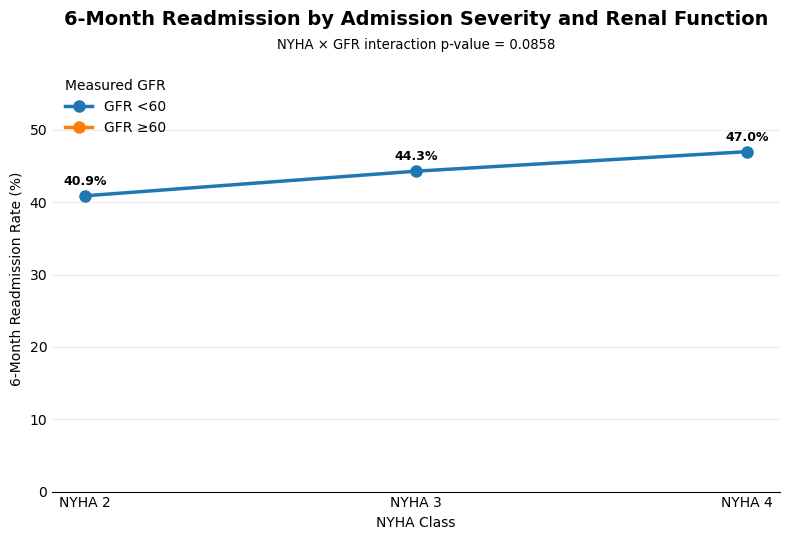

In [10]:
# ============================================================
# Q4 Visualization
# 6-Month Readmission by NYHA Severity and GFR Status
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

# ------------------------------------------------------------
# Prepare plotting data
# ------------------------------------------------------------

plot_data = q4_table.copy()

gfr_groups = [
    "GFR <60",
    "GFR ≥60"
]

# ------------------------------------------------------------
# Plot each GFR group
# ------------------------------------------------------------

for gfr_group in gfr_groups:

    subset = plot_data[
        plot_data["GFR_Risk"] == gfr_group
    ].sort_values("NYHA")

    ax.plot(
        subset["NYHA"],
        subset["Readmission_Rate_%"],
        marker="o",
        markersize=8,
        linewidth=2.5,
        label=gfr_group
    )

    # Add percentage labels
    for x, y in zip(
        subset["NYHA"],
        subset["Readmission_Rate_%"]
    ):
        ax.annotate(
            f"{y:.1f}%",
            (x, y),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            fontweight="bold"
        )

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    "6-Month Readmission by Admission Severity and Renal Function",
    fontsize=14,
    fontweight="bold",
    pad=30
)

# ------------------------------------------------------------
# Subtitle
# ------------------------------------------------------------

ax.text(
    0.5,
    1.035,
    f"NYHA × GFR interaction p-value = {interaction_p:.4f}",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=9.5
)

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    "NYHA Class",
    fontsize=10
)

ax.set_ylabel(
    "6-Month Readmission Rate (%)",
    fontsize=10
)

# ------------------------------------------------------------
# X-axis
# ------------------------------------------------------------

nyha_classes = sorted(
    q4["NYHA"].unique()
)

ax.set_xticks(nyha_classes)
ax.set_xticklabels(
    [f"NYHA {x}" for x in nyha_classes]
)

# ------------------------------------------------------------
# Y-axis
# ------------------------------------------------------------

max_rate = plot_data["Readmission_Rate_%"].max()

ax.set_ylim(
    0,
    max_rate * 1.25
)

# ------------------------------------------------------------
# Clean appearance
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.yaxis.grid(
    True,
    linewidth=0.8,
    alpha=0.25
)

ax.set_axisbelow(True)

ax.tick_params(
    axis="both",
    length=0
)

ax.legend(
    title="Measured GFR",
    frameon=False
)

plt.tight_layout()
plt.show()

#### Finding

The observed GFR-readmission gap narrows as NYHA severity rises: 17.8 points at NYHA 2 (40.9% vs 23.1%), 11.0 points at NYHA 3 (44.3% vs 33.3%), and 4.8 points at NYHA 4 (47.0% vs 42.2%). The **NYHA4-specific interaction term is significant** (coef=0.643, p=0.029), but the **omnibus interaction test (both terms jointly) is p=0.086** — a trend, not a confirmed effect at the conventional 0.05 threshold.

#### Observation & Implication

The pattern is directionally consistent (renal dysfunction's added risk shrinks as baseline severity rises) and one specific contrast clears significance, but the joint test says this isn't a confirmed, blanket interaction — it should be reported as **suggestive, not established**. Practically: a NYHA-2 patient with reduced GFR looks nearly twice as risky as one with normal renal function, which is still worth carrying into Q5's combined risk groups — but the write-up should say "observed gap narrows with severity (p=0.086 for the interaction)," not "GFR and severity interact."

**Counter-Argument:** With only 66–136 patients in the smaller NYHA×GFR cells, the omnibus test may simply be underpowered to detect a real interaction at this sample size — the near-significant p=0.086 with a clear monotonic pattern across three ordered groups is worth noting as a limitation of sample size, not necessarily evidence of no interaction.

### Q5. Does renal function provide additional information about 6-month readmission beyond admission severity?

**Why:**  
Q2-Q4 examined the relationships between renal function, admission severity, and 6-month readmission separately. We now evaluate these factors together to determine whether renal function provides additional information beyond admission severity and whether Killip adds information beyond NYHA.

**What We Expect:**  
If renal function and admission severity provide complementary information, adding GFR should improve the model beyond severity alone. If NYHA and Killip capture overlapping aspects of admission severity, Killip may provide limited additional information beyond NYHA.

In [11]:
# ============================================================
# Q5. NYHA + Killip + GFR → 6-Month Readmission
# ============================================================
import statsmodels.formula.api as smf

q5 = df[["nyha_cardiac_function_classification", "killip_grade",
         "glomerular_filtration_rate", "re_admission_within_6_months"]].dropna().copy()
q5["NYHA"] = q5["nyha_cardiac_function_classification"].astype(int)
q5["Killip"] = q5["killip_grade"].astype(int)
q5["GFR_Risk"] = np.where(q5["glomerular_filtration_rate"] < 60, "GFR <60", "GFR >=60")

print(f"Patients analyzed: {len(q5):,}")

# Combined profile table
profile_table = (q5.groupby(["NYHA", "Killip", "GFR_Risk"])["re_admission_within_6_months"]
                  .agg(Patients="count", Readmissions="sum", Readmission_Rate="mean").reset_index())
profile_table["Readmission_Rate_%"] = (profile_table["Readmission_Rate"] * 100).round(1)
qualified = profile_table[profile_table["Patients"] >= 20].sort_values("Readmission_Rate_%")
print(f"\n{len(profile_table)} total profiles observed; {len(qualified)} have >=20 patients")
print(qualified[["NYHA","Killip","GFR_Risk","Patients","Readmissions","Readmission_Rate_%"]].to_string())

# Nested model comparison
model_nyha = smf.logit("re_admission_within_6_months ~ C(NYHA)", data=q5).fit(disp=0)
model_severity = smf.logit("re_admission_within_6_months ~ C(NYHA) + C(Killip)", data=q5).fit(disp=0)
model_combined = smf.logit("re_admission_within_6_months ~ C(NYHA) + C(Killip) + C(GFR_Risk)", data=q5).fit(disp=0)

comp = pd.DataFrame({
    "Model": ["NYHA only", "NYHA + Killip", "NYHA + Killip + GFR"],
    "AIC": [model_nyha.aic, model_severity.aic, model_combined.aic],
    "PseudoR2": [model_nyha.prsquared, model_severity.prsquared, model_combined.prsquared]})
print("\n", comp.round(3))

lr_killip = 2 * (model_severity.llf - model_nyha.llf)
p_killip = stats.chi2.sf(lr_killip, model_severity.df_model - model_nyha.df_model)
lr_gfr = 2 * (model_combined.llf - model_severity.llf)
p_gfr = stats.chi2.sf(lr_gfr, model_combined.df_model - model_severity.df_model)
print(f"\nKillip increment over NYHA: p={p_killip:.6f}")
print(f"GFR increment over NYHA+Killip: p={p_gfr:.6f}")

Patients analyzed: 1,945

22 total profiles observed; 20 have >=20 patients
    NYHA  Killip  GFR_Risk  Patients  Readmissions  Readmission_Rate_%
4      2       3   GFR <60        21             4              19.000
3      2       2  GFR >=60        87            18              20.700
1      2       1  GFR >=60        82            20              24.400
5      2       3  GFR >=60        43            11              25.600
7      3       1  GFR >=60       185            59              31.900
19     4       3  GFR >=60        68            22              32.400
9      3       2  GFR >=60       285            93              32.600
11     3       3  GFR >=60        99            37              37.400
18     4       3   GFR <60        66            26              39.400
2      2       2   GFR <60        57            23              40.400
6      3       1   GFR <60       111            47              42.300
10     3       3   GFR <60        85            36              42.400
1

#### Finding

Adding Killip to a NYHA-only model did not provide statistically significant additional information for 6-month readmission (likelihood-ratio p = 0.4775), and model AIC increased from 2581.4 to 2584.9.
In contrast, adding GFR to the NYHA + Killip model significantly improved model fit (likelihood-ratio p = 0.000005), with AIC decreasing from 2584.9 to 2565.9.
Among the 20 combined profiles with at least 20 patients, observed 6-month readmission rates ranged from 19.0% to 52.4%. Notably, patients classified as NYHA 2 and Killip 1 with GFR <60 had a 51.0% readmission rate (n = 49).

#### Observation & Implication

In this cohort, Killip did not provide statistically significant additional information beyond NYHA for 6-month readmission, whereas GFR provided significant additional information after accounting for both severity measures.
This suggests that renal function captures information about readmission that is not fully represented by admission severity alone. Therefore, NYHA and GFR will be prioritized in subsequent readmission analyses, while Killip will be retained as a secondary severity measure rather than automatically included as an additional predictor.
The relatively high readmission rate observed even among the NYHA 2 / Killip 1 / GFR <60 group also suggests that reduced renal function may identify patients whose readmission burden is not apparent from admission severity classifications alone.

## Section 2 — Admission Severity → Outcomes
### Q6. Do NYHA and Killip combinations identify meaningfully different 6-month readmission profiles?

**Why:** Q5 showed that Killip did not provide statistically significant additional information beyond NYHA in the readmission model, while GFR did. We now test directly whether NYHA and Killip *combined* — including any interaction between them — identify meaningfully different readmission profiles, or whether Killip remains uninformative even in combination.

**What We Expect:** If NYHA and Killip provide complementary severity information, their combination (and any interaction between them) should separate readmission risk more than NYHA alone. If Killip is largely redundant with NYHA for this outcome, the combination should add little beyond what NYHA already shows.

In [12]:
# ============================================================
# Q6. NYHA × Killip combinations → 6-month readmission
# ============================================================
import statsmodels.formula.api as smf

q6 = df[["nyha_cardiac_function_classification", "killip_grade",
         "re_admission_within_6_months"]].dropna().copy()
q6["NYHA"] = q6["nyha_cardiac_function_classification"].astype(int)

# Collapse Killip 3+4 — raw crosstab has near-empty cells at the extremes
# (e.g. NYHA2 x Killip4 = 0 patients), which breaks any cell-level comparison.
q6["Killip_grp"] = q6["killip_grade"].replace({4: 3}).map(
    {1: "Killip 1", 2: "Killip 2", 3: "Killip 3-4"})

print(f"Patients analyzed: {len(q6):,}")

# Observed rates per combination
combo = (q6.groupby(["NYHA", "Killip_grp"])["re_admission_within_6_months"]
         .agg(Patients="count", Readmissions="sum", Rate="mean").reset_index())
combo["Rate_%"] = (combo["Rate"] * 100).round(1)
print("\nObserved readmission rate by NYHA x Killip:")
print(combo[["NYHA", "Killip_grp", "Patients", "Readmissions", "Rate_%"]].to_string())
print(f"\nSmallest cell: {combo['Patients'].min()}")
print(f"Combo range: {combo['Rate_%'].max() - combo['Rate_%'].min():.1f} pts")

nyha_marg = q6.groupby("NYHA")["re_admission_within_6_months"].mean() * 100
print(f"NYHA-alone range: {nyha_marg.max() - nyha_marg.min():.1f} pts")

for n in [2, 3, 4]:
    sub = combo[combo.NYHA == n]
    print(f"NYHA {n}: Killip sub-range = {sub['Rate_%'].max() - sub['Rate_%'].min():.1f} pts",
          dict(zip(sub["Killip_grp"], sub["Rate_%"])))

# Formal test: does the NYHA x Killip interaction explain more than main effects alone?
main_effects = smf.logit("re_admission_within_6_months ~ C(NYHA) + C(Killip_grp)", data=q6).fit(disp=0)
with_interaction = smf.logit("re_admission_within_6_months ~ C(NYHA) * C(Killip_grp)", data=q6).fit(disp=0)

lr = 2 * (with_interaction.llf - main_effects.llf)
dof = with_interaction.df_model - main_effects.df_model
p_interaction = stats.chi2.sf(lr, dof)

print(f"\nMain-effects AIC: {main_effects.aic:.3f}")
print(f"Interaction AIC: {with_interaction.aic:.3f}")
print(f"Interaction LR test: LR={lr:.3f}, dof={dof:.0f}, p={p_interaction:.6f}")

Patients analyzed: 2,008

Observed readmission rate by NYHA x Killip:
   NYHA  Killip_grp  Patients  Readmissions  Rate_%
0     2    Killip 1       136            45  33.100
1     2    Killip 2       151            43  28.500
2     2  Killip 3-4        66            15  22.700
3     3    Killip 1       304           109  35.900
4     3    Killip 2       543           210  38.700
5     3  Killip 3-4       192            76  39.600
6     4    Killip 1        87            45  51.700
7     4    Killip 2       335           156  46.600
8     4  Killip 3-4       194            74  38.100

Smallest cell: 66
Combo range: 29.0 pts
NYHA-alone range: 15.5 pts
NYHA 2: Killip sub-range = 10.4 pts {'Killip 1': 33.1, 'Killip 2': 28.5, 'Killip 3-4': 22.7}
NYHA 3: Killip sub-range = 3.7 pts {'Killip 1': 35.9, 'Killip 2': 38.7, 'Killip 3-4': 39.6}
NYHA 4: Killip sub-range = 13.6 pts {'Killip 1': 51.7, 'Killip 2': 46.6, 'Killip 3-4': 38.1}

Main-effects AIC: 2660.817
Interaction AIC: 2662.285
Interactio

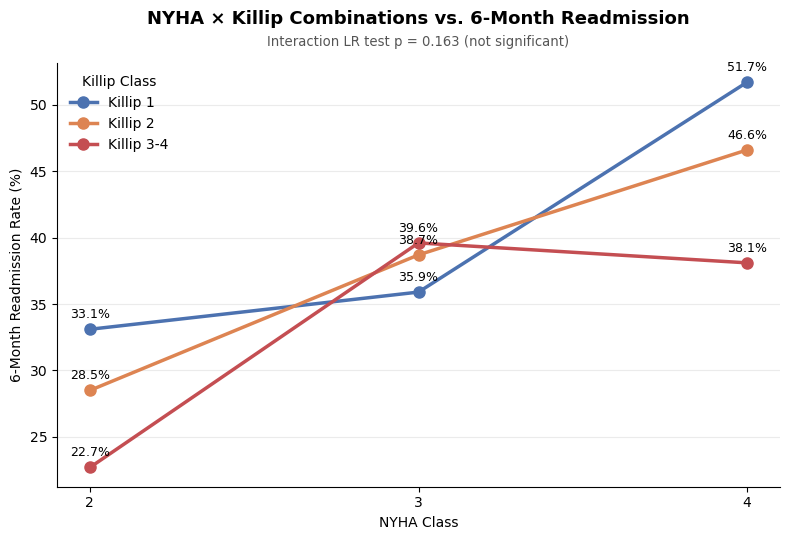

In [13]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for killip_grp, color in zip(["Killip 1", "Killip 2", "Killip 3-4"], ["#4C72B0", "#DD8452", "#C44E52"]):
    sub = combo[combo["Killip_grp"] == killip_grp].sort_values("NYHA")
    ax.plot(sub["NYHA"], sub["Rate_%"], marker="o", markersize=8, linewidth=2.5,
            label=killip_grp, color=color)
    for x, y in zip(sub["NYHA"], sub["Rate_%"]):
        ax.annotate(f"{y:.1f}%", (x, y), xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=9)

ax.set_xticks([2, 3, 4])
ax.set_xlabel("NYHA Class")
ax.set_ylabel("6-Month Readmission Rate (%)")
ax.set_title("NYHA × Killip Combinations vs. 6-Month Readmission", fontsize=13, fontweight="bold", pad=28)
ax.text(0.5, 1.04, f"Interaction LR test p = {p_interaction:.3f} (not significant)",
        transform=ax.transAxes, ha="center", fontsize=9.5, color="#555555")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)
ax.legend(title="Killip Class", frameon=False)
plt.tight_layout()
plt.show()

#### Finding

Among 1,945 patients, observed 6-month readmission increased with NYHA severity (~29% NYHA 2, ~38% NYHA 3, ~45% NYHA 4). Within individual NYHA classes, however, the pattern across Killip groups was inconsistent — NYHA 2 ranged 22.7%-33.1%, NYHA 3 ranged 35.9%-39.6%, NYHA 4 ranged 38.1%-51.7%, with the direction reversing between classes. The NYHA×Killip interaction was not statistically significant (LR p=0.163), and the interaction model had a slightly higher AIC than the main-effects model (2662.3 vs. 2660.8).

#### Observation & Implication

The readmission pattern is driven primarily by NYHA; Killip does not show a consistent additional pattern within NYHA classes, and the non-significant interaction indicates insufficient evidence that Killip's relationship with readmission depends on NYHA class in this cohort. Together with Q5, this supports **NYHA as the primary severity variable and GFR as an independent contributor for 6-month readmission specifically** — Killip did not provide statistically significant additional information beyond NYHA for *this outcome*. This does not establish Killip is uninformative generally; Q7 tests it against a different outcome (LOS) directly rather than assuming.

**Counter-Argument:** A non-significant 4-df interaction test doesn't prove no interaction exists — only that this sample lacks power to detect one this size.

### Q7. Is greater admission severity associated with prolonged hospitalization?

**Why:** Q5 and Q6 showed that NYHA provided the clearer admission-severity signal for 6-month readmission, while Killip provided limited additional information for that outcome. We now examine whether admission severity is also associated with hospitalization duration, providing a different outcome perspective and assessing whether the severity pattern extends to inpatient resource use.

**What We Expect:** Patients with greater admission severity may have longer hospital stays. If observed, admission severity would provide information about both post-discharge readmission and inpatient resource utilization.

In [14]:
# ============================================================
# Q7, Step 1 — Admission severity (NYHA and Killip) vs. LOS
# ============================================================

q7 = df[["nyha_cardiac_function_classification", "killip_grade", "dischargeday"]].dropna().copy()
q7["NYHA"] = q7["nyha_cardiac_function_classification"].astype(int)
# Killip 3+4 collapsed for the categorical/crosstab tests below (sparse cells at
# the extremes); the raw 1-4 ordinal scale is kept for the Spearman correlation,
# since that test benefits from the full ordinal granularity Killip was designed with.
q7["Killip_grp"] = q7["killip_grade"].replace({4: 3}).map(
    {1: "Killip 1", 2: "Killip 2", 3: "Killip 3-4"})

print(f"N: {len(q7):,}")
print("\nOverall LOS distribution:")
print(q7["dischargeday"].describe())

q1, q3 = q7["dischargeday"].quantile([0.25, 0.75])
threshold = q3
# Operational definition, not a clinical one: prolonged LOS = above this cohort's own 75th percentile.
q7["prolonged_los"] = (q7["dischargeday"] > threshold).astype(int)
print(f"\nProlonged LOS operationally defined as >{threshold:.0f} days (cohort's 75th percentile)")
print(f"Prolonged rate overall: {q7['prolonged_los'].mean()*100:.1f}%")

# ---------- NYHA vs LOS ----------
nyha_summary = q7.groupby("NYHA")["dischargeday"].agg(
    Count="count", Median="median", Q1=lambda x: x.quantile(0.25), Q3=lambda x: x.quantile(0.75))
print("\nLOS by NYHA class:\n", nyha_summary.round(2))

groups_nyha = [q7.loc[q7.NYHA == n, "dischargeday"] for n in [2, 3, 4]]
kw_nyha, p_kw_nyha = stats.kruskal(*groups_nyha)
rho_nyha, p_rho_nyha = stats.spearmanr(q7["NYHA"], q7["dischargeday"])
print(f"Kruskal-Wallis (NYHA vs LOS): H={kw_nyha:.3f}, p={p_kw_nyha:.6f}")
print(f"Spearman (NYHA vs LOS): rho={rho_nyha:.3f}, p={p_rho_nyha:.6f}")

prolonged_by_nyha = q7.groupby("NYHA")["prolonged_los"].mean() * 100
print("\nProlonged LOS rate by NYHA (%):\n", prolonged_by_nyha.round(1))
ct_nyha = pd.crosstab(q7["NYHA"], q7["prolonged_los"])
chi2_n, p_chi_n, dof_n, _ = stats.chi2_contingency(ct_nyha)
n_n = ct_nyha.sum().sum()
cramers_v_n = np.sqrt(chi2_n / (n_n * (min(ct_nyha.shape) - 1)))
print(f"Chi2={chi2_n:.3f}, dof={dof_n}, p={p_chi_n:.6f}, Cramer's V={cramers_v_n:.3f}")

# ---------- Killip vs LOS ----------
killip_summary = q7.groupby("Killip_grp")["dischargeday"].agg(
    Count="count", Median="median", Q1=lambda x: x.quantile(0.25), Q3=lambda x: x.quantile(0.75))
print("\n\nLOS by Killip group:\n", killip_summary.round(2))

groups_killip = [q7.loc[q7.Killip_grp == g, "dischargeday"] for g in ["Killip 1", "Killip 2", "Killip 3-4"]]
kw_killip, p_kw_killip = stats.kruskal(*groups_killip)
rho_killip, p_rho_killip = stats.spearmanr(q7["killip_grade"], q7["dischargeday"])
print(f"Kruskal-Wallis (Killip vs LOS): H={kw_killip:.3f}, p={p_kw_killip:.6f}")
print(f"Spearman (Killip vs LOS, raw 1-4 scale): rho={rho_killip:.3f}, p={p_rho_killip:.6f}")

prolonged_by_killip = q7.groupby("Killip_grp")["prolonged_los"].mean() * 100
print("\nProlonged LOS rate by Killip (%):\n", prolonged_by_killip.round(1))
ct_killip = pd.crosstab(q7["Killip_grp"], q7["prolonged_los"])
chi2_k, p_chi_k, dof_k, _ = stats.chi2_contingency(ct_killip)
n_k = ct_killip.sum().sum()
cramers_v_k = np.sqrt(chi2_k / (n_k * (min(ct_killip.shape) - 1)))
print(f"Chi2={chi2_k:.3f}, dof={dof_k}, p={p_chi_k:.6f}, Cramer's V={cramers_v_k:.3f}")

N: 2,008

Overall LOS distribution:
count   2,008.000
mean        9.421
std         8.030
min         1.000
25%         6.000
50%         8.000
75%        10.000
max       123.000
Name: dischargeday, dtype: float64

Prolonged LOS operationally defined as >10 days (cohort's 75th percentile)
Prolonged rate overall: 24.8%

LOS by NYHA class:
       Count  Median    Q1     Q3
NYHA                            
2       353   7.000 5.000 10.000
3      1039   7.000 6.000 10.000
4       616   8.000 6.000 11.000
Kruskal-Wallis (NYHA vs LOS): H=16.210, p=0.000302
Spearman (NYHA vs LOS): rho=0.084, p=0.000171

Prolonged LOS rate by NYHA (%):
 NYHA
2   23.800
3   21.300
4   31.300
Name: prolonged_los, dtype: float64
Chi2=21.220, dof=2, p=0.000025, Cramer's V=0.103


LOS by Killip group:
             Count  Median    Q1     Q3
Killip_grp                            
Killip 1      527   8.000 6.000 10.000
Killip 2     1029   8.000 6.000 10.000
Killip 3-4    452   8.000 6.000 11.000
Kruskal-Wallis (Kill

In [15]:
# ============================================================
# Q7, Step 2 — Targeted follow-up
# Motivated by Step 1's output above: NYHA4's prolonged-LOS rate (31.3%)
# visibly separates from NYHA2/3 (23.8%/21.3%), which don't separate from
# each other. This test exists BECAUSE of that pattern, not before it.
# ============================================================

q7["is_nyha4"] = (q7["NYHA"] == 4).astype(int)
rate_4 = q7.loc[q7.is_nyha4 == 1, "prolonged_los"].mean() * 100
rate_23 = q7.loc[q7.is_nyha4 == 0, "prolonged_los"].mean() * 100
ct2 = pd.crosstab(q7["is_nyha4"], q7["prolonged_los"])
a, b = ct2.loc[1, 1], ct2.loc[1, 0]
c, d = ct2.loc[0, 1], ct2.loc[0, 0]
odds_ratio_n = (a * d) / (b * c)
print(f"NYHA4 prolonged rate: {rate_4:.1f}% | NYHA2/3 prolonged rate: {rate_23:.1f}%")
print(f"Odds ratio (NYHA4 vs NYHA2/3): {odds_ratio_n:.2f}")

NYHA4 prolonged rate: 31.3% | NYHA2/3 prolonged rate: 21.9%
Odds ratio (NYHA4 vs NYHA2/3): 1.63


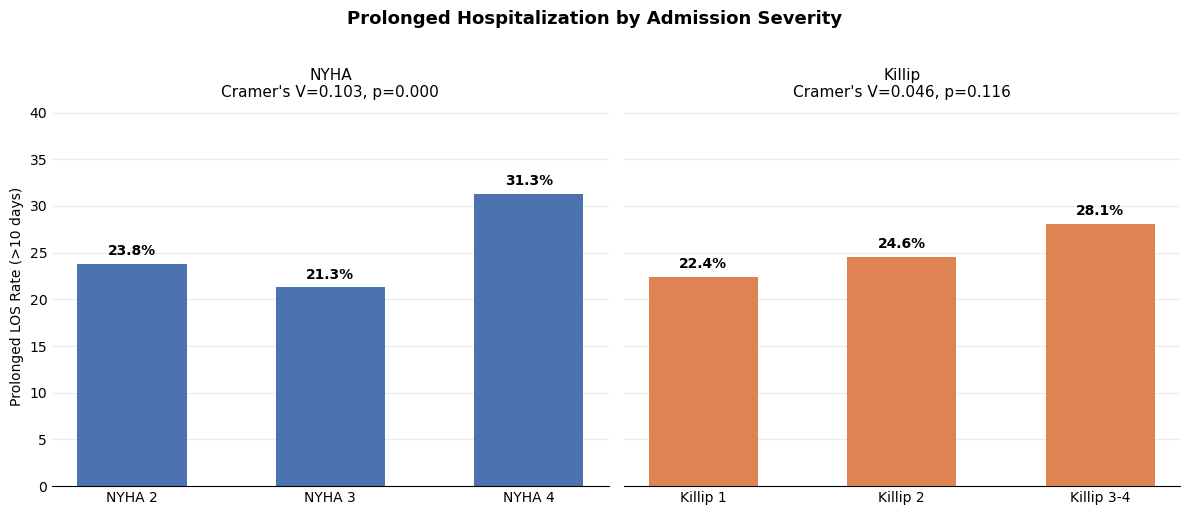

In [16]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bars0 = axes[0].bar([f"NYHA {n}" for n in [2, 3, 4]], prolonged_by_nyha.values, color="#4C72B0", width=0.55)
axes[0].bar_label(bars0, fmt="%.1f%%", padding=4, fontweight="bold")
axes[0].set_title(f"NYHA\nCramer's V={cramers_v_n:.3f}, p={p_chi_n:.3f}", fontsize=11)
axes[0].set_ylabel(f"Prolonged LOS Rate (>{threshold:.0f} days)")

bars1 = axes[1].bar(["Killip 1", "Killip 2", "Killip 3-4"], prolonged_by_killip.values, color="#DD8452", width=0.55)
axes[1].bar_label(bars1, fmt="%.1f%%", padding=4, fontweight="bold")
axes[1].set_title(f"Killip\nCramer's V={cramers_v_k:.3f}, p={p_chi_k:.3f}", fontsize=11)

for ax in axes:
    ax.set_ylim(0, max(prolonged_by_nyha.max(), prolonged_by_killip.max()) * 1.3)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.yaxis.grid(True, alpha=0.25)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

fig.suptitle("Prolonged Hospitalization by Admission Severity", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### Finding

NYHA shows a weak but statistically significant relationship with LOS (Kruskal-Wallis p=0.0003). Median LOS is identical for NYHA 2 and 3 (7.0 days), rising only at NYHA 4 (8.0 days); prolonged-LOS rate follows the same pattern (23.8%→21.3%→31.3%, Cramér's V=0.103). Killip shows no relationship with LOS at all (Kruskal-Wallis p=0.707, chi2 p=0.117) — identical median LOS (8.0 days) across all three Killip groups. Given NYHA4's clear separation in the primary output, a targeted follow-up confirms it: NYHA4 vs. NYHA2/3 combined, OR=1.63.

#### Observation & Implication

Killip's lack of contribution now holds for two outcomes (6-month readmission and LOS), each tested directly rather than assumed. NYHA's signal for LOS is weak and concentrated in the NYHA4 group specifically, consistent with the pattern already seen for GFR (Q2) and readmission (Q6): NYHA behaves more like a "class 4 vs. rest" flag than a smooth ordinal scale in this cohort. Worth carrying a binary `is_nyha4` flag alongside continuous NYHA into Category 4.

**Counter-Argument:** LOS is shaped by non-clinical factors (bed availability, discharge planning, weekends) not captured here — Killip's null LOS result could partly reflect these confounds diluting a real relationship, not proof of no clinical link.

### Q8. Does the relationship between admission severity and readmission remain consistent across 28-day, 3-month, and 6-month follow-up?

**Why:** Previous analyses identified NYHA as the clearer admission-severity measure for 6-month readmission and also found an association between NYHA severity and hospitalization duration. Before carrying the 6-month readmission outcome forward into Predictive Analysis, we need to determine whether the relationship between admission severity and readmission is consistent across different follow-up periods.

**What We Expect:** If admission severity is consistently associated with readmission, higher NYHA classes should show higher observed readmission rates across the follow-up periods. The strength and precision of the association may vary because the number of observed readmission events increases with follow-up duration.

In [17]:
# ============================================================
# Q8. Severity-readmission relationship across 28-day/3-month/6-month
# ============================================================

outcomes = {
    "28-day": "re_admission_within_28_days",
    "3-month": "re_admission_within_3_months",
    "6-month": "re_admission_within_6_months",
}

# --- Primary analysis: full NYHA 2/3/4 breakdown at each window ---
print("Full NYHA breakdown by follow-up window:")
for label, col in outcomes.items():
    q = df[["nyha_cardiac_function_classification", col]].dropna().copy()
    q["NYHA"] = q["nyha_cardiac_function_classification"].astype(int)
    rates = q.groupby("NYHA")[col].agg(Patients="count", Events="sum", Rate=lambda x: x.mean() * 100)
    ct = pd.crosstab(q["NYHA"], q[col])
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    print(f"\n--- {label} (chi2 p={p:.6f}) ---")
    print(rates.round(1))

# --- Supplementary: NYHA4 vs NYHA2/3, OR + 95% CI, for a common cross-window contrast ---
results = []
for label, col in outcomes.items():
    q = df[["nyha_cardiac_function_classification", col]].dropna().copy()
    q["is_nyha4"] = (q["nyha_cardiac_function_classification"].astype(int) == 4).astype(int)
    events = q[col].sum()
    rate_4 = q.loc[q.is_nyha4 == 1, col].mean() * 100
    rate_23 = q.loc[q.is_nyha4 == 0, col].mean() * 100
    ct = pd.crosstab(q["is_nyha4"], q[col])
    a, b = ct.loc[1, 1], ct.loc[1, 0]
    c, d = ct.loc[0, 1], ct.loc[0, 0]
    odds_ratio = (a * d) / (b * c)
    se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
    log_or = np.log(odds_ratio)
    ci_low = np.exp(log_or - 1.96 * se_log_or)
    ci_high = np.exp(log_or + 1.96 * se_log_or)
    chi2, p, dof, exp2 = stats.chi2_contingency(ct)
    results.append({"Window": label, "Events": events, "NYHA4_%": round(rate_4, 1),
                     "NYHA23_%": round(rate_23, 1), "OR": round(odds_ratio, 2),
                     "CI_low": round(ci_low, 2), "CI_high": round(ci_high, 2), "p": p})

res_df = pd.DataFrame(results)
print("\n\nSupplementary NYHA4-vs-rest contrast:")
print(res_df.to_string())

Full NYHA breakdown by follow-up window:

--- 28-day (chi2 p=0.002731) ---
      Patients  Events  Rate
NYHA                        
2          353      14 4.000
3         1039      67 6.400
4          616      59 9.600

--- 3-month (chi2 p=0.000012) ---
      Patients  Events   Rate
NYHA                         
2          353      59 16.700
3         1039     252 24.300
4          616     187 30.400

--- 6-month (chi2 p=0.000011) ---
      Patients  Events   Rate
NYHA                         
2          353     103 29.200
3         1039     395 38.000
4          616     275 44.600


Supplementary NYHA4-vs-rest contrast:
    Window  Events  NYHA4_%  NYHA23_%    OR  CI_low  CI_high     p
0   28-day     140    9.600     5.800 1.710   1.210    2.430 0.003
1  3-month     498   30.400    22.300 1.520   1.220    1.870 0.000
2  6-month     773   44.600    35.800 1.450   1.190    1.760 0.000


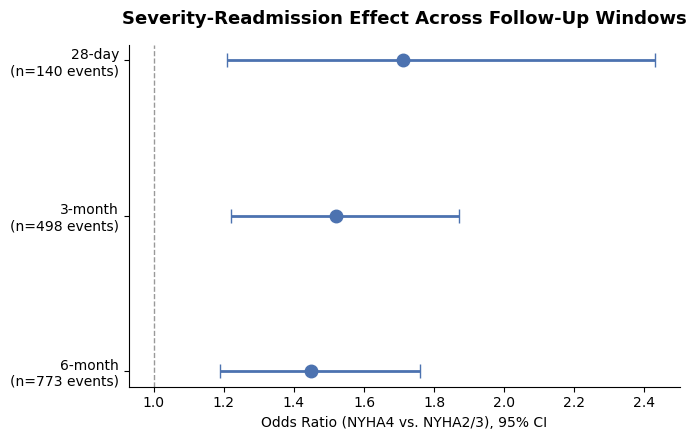

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
y_pos = np.arange(len(res_df))[::-1]
ax.errorbar(res_df["OR"], y_pos,
            xerr=[res_df["OR"] - res_df["CI_low"], res_df["CI_high"] - res_df["OR"]],
            fmt="o", markersize=9, capsize=5, color="#4C72B0", linewidth=2)
ax.axvline(1, color="#999999", linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row.Window}\n(n={row.Events} events)" for row in res_df.itertuples()])
ax.set_xlabel("Odds Ratio (NYHA4 vs. NYHA2/3), 95% CI")
ax.set_title("Severity-Readmission Effect Across Follow-Up Windows", fontsize=13, fontweight="bold", pad=15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

#### Finding

The full NYHA breakdown shows a monotonic increase at every follow-up window: 28-day (4.0%→6.4%→9.6%, p=0.0027), 3-month (16.7%→24.3%→30.4%, p<0.0001), and 6-month (29.2%→38.0%→44.6%, p<0.0001) — unlike Q6/Q7, where NYHA 2 vs. 3 sometimes failed to separate, here all three classes separate cleanly at every horizon. Using NYHA4-vs-NYHA2/3 as a common cross-window contrast: 28-day OR=1.71 (95% CI 1.21–2.43), 3-month OR=1.52 (1.22–1.87), 6-month OR=1.45 (1.19–1.76) — all significant (p<0.005).

#### Observation & Implication

The association between NYHA severity and readmission was observed consistently across all three follow-up periods — directionally consistent, with odds ratios ranging 1.45–1.71, rather than proven statistically identical across windows. The 28-day estimate has a wider confidence interval, reflecting fewer observed events (140 vs. 773 at 6 months), not a weaker underlying relationship. This strengthens the rationale for carrying 6-month readmission forward as the primary predictive target: it isn't an arbitrary choice among three options, it's the window with both the most events and a relationship consistent with what's seen at every other horizon. The next question shifts from severity-alone to whether a combined severity profile identifies patients experiencing *both* prolonged hospitalization and 6-month readmission together.

**Counter-Argument:** No formal test was run comparing whether the three ORs differ significantly from each other — the "directionally consistent" claim is a visual/descriptive read of overlapping confidence intervals, not a statistically tested equivalence. A formal test (e.g., interaction between window and NYHA4 status in a pooled model) would be needed to claim the magnitudes are statistically indistinguishable.

### Q9. Can the combination of admission severity and renal function identify patients with both prolonged hospitalization and subsequent 6-month readmission?

**Why:** Q7 showed NYHA relates to prolonged hospitalization; Q3-Q5 showed GFR<60 adds information about 6-month readmission beyond severity. We now combine both validated factors to test whether they jointly identify patients experiencing *both* adverse outcomes together, rather than just one or the other.

**What We Expect:** If NYHA and GFR capture complementary risk, patients with higher NYHA and reduced GFR should show a higher rate of the combined outcome than any single-factor group — but which specific combination is highest should be determined by the data, not assumed in advance.

In [19]:
# ============================================================
# Q9. NYHA + GFR → combined outcome (prolonged LOS AND 6-month readmission)
# ============================================================

q9 = df[["nyha_cardiac_function_classification", "glomerular_filtration_rate",
         "dischargeday", "re_admission_within_6_months"]].dropna().copy()
q9["NYHA"] = q9["nyha_cardiac_function_classification"].astype(int)
q9["GFR_Risk"] = np.where(q9["glomerular_filtration_rate"] < 60, "GFR <60", "GFR >=60")
q9["prolonged_los"] = (q9["dischargeday"] > 10).astype(int)  # threshold established in Q7
q9["readmit_6m"] = q9["re_admission_within_6_months"].astype(int)
q9["both"] = ((q9["prolonged_los"] == 1) & (q9["readmit_6m"] == 1)).astype(int)

print(f"N: {len(q9):,}")
print(f"Prolonged LOS rate overall: {q9['prolonged_los'].mean()*100:.1f}%")
print(f"6-month readmit rate overall: {q9['readmit_6m'].mean()*100:.1f}%")
print(f"BOTH (combined outcome) rate overall: {q9['both'].mean()*100:.1f}%  (n={q9['both'].sum()} events)")

profile = (q9.groupby(["NYHA", "GFR_Risk"])
           .agg(Patients=("both", "count"),
                Prolonged_pct=("prolonged_los", lambda x: x.mean() * 100),
                Readmit6m_pct=("readmit_6m", lambda x: x.mean() * 100),
                Both_pct=("both", lambda x: x.mean() * 100),
                Both_n=("both", "sum"))
           .reset_index())
print("\nCombined profile table:")
print(profile.round(1).to_string())
print(f"\nBoth-outcome range across 6 profiles: {profile.Both_pct.max()-profile.Both_pct.min():.1f} pts")

q9["profile_id"] = q9["NYHA"].astype(str) + "_" + q9["GFR_Risk"]
ct = pd.crosstab(q9["profile_id"], q9["both"])
chi2, p, dof, exp = stats.chi2_contingency(ct)
print(f"Chi2 across 6 profiles: chi2={chi2:.3f}, dof={dof}, p={p:.6f}")
print(f"Smallest 'both' event count in any cell: {profile.Both_n.min()}")

N: 1,945
Prolonged LOS rate overall: 24.5%
6-month readmit rate overall: 38.7%
BOTH (combined outcome) rate overall: 10.8%  (n=211 events)

Combined profile table:
   NYHA  GFR_Risk  Patients  Prolonged_pct  Readmit6m_pct  Both_pct  Both_n
0     2   GFR <60       127         33.900         40.900    14.200      18
1     2  GFR >=60       212         17.000         23.100     4.700      10
2     3   GFR <60       442         26.700         44.300    15.200      67
3     3  GFR >=60       570         16.700         33.300     6.300      36
4     4   GFR <60       317         37.200         47.000    17.700      56
5     4  GFR >=60       277         24.200         42.200     8.700      24

Both-outcome range across 6 profiles: 12.9 pts
Chi2 across 6 profiles: chi2=46.889, dof=5, p=0.000000
Smallest 'both' event count in any cell: 10


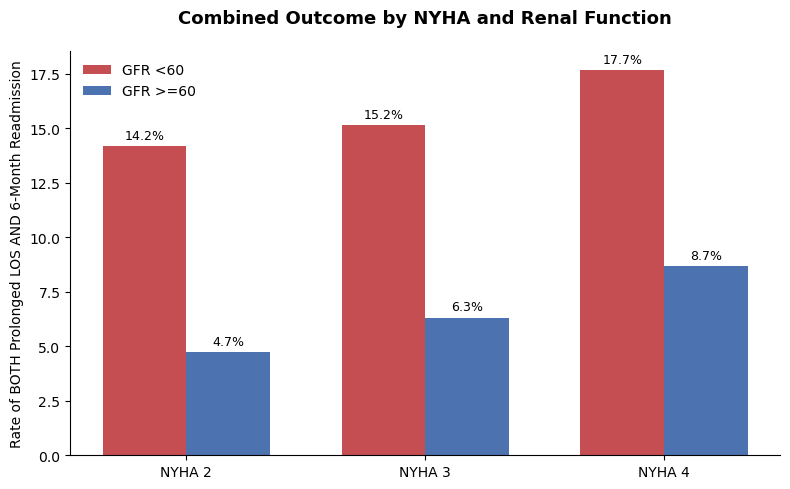

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
width = 0.35
low = profile[profile.GFR_Risk == "GFR <60"].sort_values("NYHA")["Both_pct"].values
high = profile[profile.GFR_Risk == "GFR >=60"].sort_values("NYHA")["Both_pct"].values

bars1 = ax.bar(x - width/2, low, width, label="GFR <60", color="#C44E52")
bars2 = ax.bar(x + width/2, high, width, label="GFR >=60", color="#4C72B0")
ax.bar_label(bars1, fmt="%.1f%%", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.1f%%", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(["NYHA 2", "NYHA 3", "NYHA 4"])
ax.set_ylabel("Rate of BOTH Prolonged LOS AND 6-Month Readmission")
ax.set_title("Combined Outcome by NYHA and Renal Function", fontsize=13, fontweight="bold", pad=20)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Finding

The combined outcome (both prolonged LOS and 6-month readmission) occurs in 10.8% of patients overall (211 events). GFR<60 roughly doubles-to-triples the combined-outcome rate within every NYHA class: NYHA2 (14.2% vs 4.7%), NYHA3 (15.2% vs 6.3%), NYHA4 (17.7% vs 8.7%). The highest-risk profile is confirmed as NYHA4+GFR<60 (17.7%), and the lowest is NYHA2+GFR>=60 (4.7%) — a 12.9-point range, chi-square p<0.000001.

### Observation & Implication

NYHA and GFR combine consistently across all three severity levels — GFR<60's effect on the combined outcome doesn't wash out or reverse anywhere, unlike Killip's inconsistent behavior in Q6. This is the cleanest multi-outcome confirmation yet that NYHA+GFR is a coherent risk pairing, not just a readmission-specific one. **The NYHA4+GFR<60 group (n=317, 17.7% combined-outcome rate) is now a concrete, evidence-identified high-risk subgroup** — a strong candidate for the Group 6 integrated risk score and a natural target population for the Category 5 dashboard's follow-up-prioritization use case.

**Counter-Argument:** The smallest cell (NYHA2+GFR>=60, 10 "both" events) is thin enough that its 4.7% estimate carries real uncertainty — the overall pattern is robust, but that specific low-end number shouldn't be quoted as precise.

### Q10. Does admission route provide additional information about prolonged hospitalization or 6-month readmission beyond the NYHA + GFR profile?

**Why:** Q9 established NYHA + GFR as a validated combined risk profile for two outcomes. Admission route (Emergency vs. Non-Emergency) is a care-pathway variable, not a clinical severity measure — this tests whether it carries independent information once severity and renal function are already accounted for, or whether it's redundant with the clinical picture.

**What We Expect:** If admission route just reflects how sick a patient looks, it should add nothing once NYHA and GFR are in the model. If it reflects something else (bed availability, planned vs. unplanned care pathway), it might contribute independently.

In [21]:
# ============================================================
# Q10. Admission route: does it add beyond NYHA + GFR?
# ============================================================
import statsmodels.formula.api as smf

q10 = df[["nyha_cardiac_function_classification", "glomerular_filtration_rate", "admission_way",
          "dischargeday", "re_admission_within_6_months"]].dropna().copy()
q10["NYHA"] = q10["nyha_cardiac_function_classification"].astype(int)
q10["GFR_Risk"] = np.where(q10["glomerular_filtration_rate"] < 60, "GFR <60", "GFR >=60")
q10["prolonged_los"] = (q10["dischargeday"] > 10).astype(int)
q10["readmit_6m"] = q10["re_admission_within_6_months"].astype(int)

print(f"N: {len(q10):,}")
print(q10["admission_way"].value_counts())

# Does admission route just reflect severity? (it shouldn't, if it's an independent care-pathway factor)
ct_sev = pd.crosstab(q10["admission_way"], q10["NYHA"])
chi2s, ps, dofs, _ = stats.chi2_contingency(ct_sev)
print(f"\nAdmission way x NYHA: chi2={chi2s:.3f}, p={ps:.6f}")

print("\nReadmit 6m rate by admission way:\n", (q10.groupby("admission_way")["readmit_6m"].mean()*100).round(1))
print("Prolonged LOS rate by admission way:\n", (q10.groupby("admission_way")["prolonged_los"].mean()*100).round(1))

# Nested models: does admission_way add beyond NYHA+GFR, for each outcome?
for outcome in ["readmit_6m", "prolonged_los"]:
    base = smf.logit(f"{outcome} ~ C(NYHA) + C(GFR_Risk)", data=q10).fit(disp=0)
    full = smf.logit(f"{outcome} ~ C(NYHA) + C(GFR_Risk) + C(admission_way)", data=q10).fit(disp=0)
    lr = 2 * (full.llf - base.llf)
    dof = full.df_model - base.df_model
    p = stats.chi2.sf(lr, dof)
    print(f"\n{outcome}: base AIC={base.aic:.2f}, full AIC={full.aic:.2f}, LR={lr:.3f}, dof={dof:.0f}, p={p:.6f}")
    print(full.params.filter(like="admission_way"))

N: 1,945
admission_way
Non Emergency    1019
Emergency         926
Name: count, dtype: int64

Admission way x NYHA: chi2=1.288, p=0.525279

Readmit 6m rate by admission way:
 admission_way
Emergency       38.700
Non Emergency   38.800
Name: readmit_6m, dtype: float64
Prolonged LOS rate by admission way:
 admission_way
Emergency       22.100
Non Emergency   26.700
Name: prolonged_los, dtype: float64

readmit_6m: base AIC=2562.33, full AIC=2564.21, LR=0.119, dof=1, p=0.729728
C(admission_way)[T.Non Emergency]   0.033
dtype: float64

prolonged_los: base AIC=2116.50, full AIC=2111.36, LR=7.133, dof=1, p=0.007570
C(admission_way)[T.Non Emergency]   0.288
dtype: float64


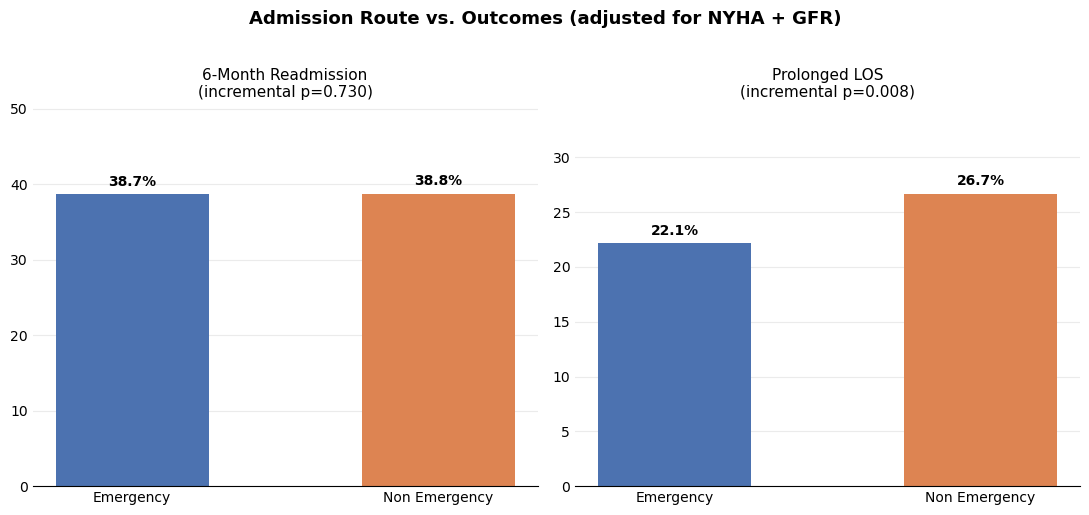

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=False)
rates_readmit = (q10.groupby("admission_way")["readmit_6m"].mean()*100)
rates_los = (q10.groupby("admission_way")["prolonged_los"].mean()*100)

for ax, rates, title, p_val in zip(axes, [rates_readmit, rates_los],
                                     ["6-Month Readmission", "Prolonged LOS"], [0.730, 0.008]):
    bars = ax.bar(rates.index, rates.values, color=["#4C72B0", "#DD8452"], width=0.5)
    ax.bar_label(bars, fmt="%.1f%%", padding=4, fontweight="bold")
    ax.set_ylim(0, max(rates.values) * 1.3)
    ax.set_title(f"{title}\n(incremental p={p_val:.3f})", fontsize=11)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.yaxis.grid(True, alpha=0.25)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

fig.suptitle("Admission Route vs. Outcomes (adjusted for NYHA + GFR)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Finding

Admission route is unrelated to NYHA severity (p=0.525) — it isn't simply proxying for how sick patients look at admission. It adds nothing to the 6-month readmission model beyond NYHA+GFR (rates are nearly identical: 38.7% vs 38.8%, incremental p=0.730). But it *does* add significantly to the prolonged-LOS model (p=0.008) — counter-intuitively, **Non-Emergency (planned) admissions have a higher prolonged-LOS rate (26.7%) than Emergency admissions (22.1%)**, even after adjusting for NYHA and GFR.

### Observation & Implication

Admission route is outcome-specific, not a general risk factor: irrelevant to readmission, but a genuine independent contributor to length of stay — in the opposite direction from what "emergency = sicker = longer stay" would predict. This suggests non-emergency admissions may involve more extensive planned workups or procedures, or that emergency-admitted patients are discharged faster under bed-pressure/triage dynamics not captured elsewhere in this dataset. Confirms admission route as a legitimate **LOS-specific** candidate feature for Category 4, but not a readmission-risk feature — it shouldn't be added to the Group 6 integrated readmission risk score.

**Counter-Argument:** This dataset doesn't capture *why* someone was admitted non-emergently (e.g., a planned procedure vs. a scheduled HF workup) — the LOS difference may reflect what the admission was *for*, not the admission pathway itself as a risk factor. Without that context, the finding is real but its causal interpretation is limited.

## Family 3 — Cardiac Biomarker and Renal Function (Questions 11–13)

These analyses use the final `patient_master.csv`. Each question builds a *new*
working table, so it can be run without variables created by another family's
question. Percentages always use patients with a recorded outcome and marker;
a missing biomarker or outcome never counts as a negative result. Results show
associations in these patients, not treatment effects or confirmed clinical risk scores.

In [23]:
# Step 1: Set exact column names produced by the team's cleaning notebook.
OUTCOME = "re_admission_within_6_months"
DEATH = "death_within_6_months"
BNP = "brain_natriuretic_peptide"
GFR = "glomerular_filtration_rate"
NYHA = "nyha_cardiac_function_classification"
KILLIP = "killip_grade"
CCI = "cci_score"
CKD = "moderate_to_severe_chronic_kidney_disease"

# Step 2: Report counts and observed rates using the correct group denominators.
# Missing outcomes are excluded BEFORE this function is called.
def outcome_rates(frame, groups, outcome):
    result = (frame.groupby(groups, observed=True, dropna=False)[outcome]
              .agg(n="size", events="sum"))
    result["rate_pct"] = (100 * result["events"] / result["n"]).round(1)
    return result

# Step 3: Make a complete-case working copy without changing the master df.
# The cleaning notebook marked a small number of contradictory event records;
# exclude them from analyses of the 6-month readmission label when the flag exists.
def analysis_rows(columns, outcome=OUTCOME, verbose=True):
    cols = list(dict.fromkeys([*columns, outcome]))
    if "event_time_contradiction_flag" in df.columns and outcome == OUTCOME:
        cols.append("event_time_contradiction_flag")
    if "outcome_destination_flag" in df.columns and outcome == DEATH:
        cols.append("outcome_destination_flag")
    work = df[cols].copy()
    if "event_time_contradiction_flag" in work:
        work = work.loc[~work["event_time_contradiction_flag"].astype(str)
                        .str.strip().str.lower().isin(["true", "1"])].drop(columns="event_time_contradiction_flag")
    if "outcome_destination_flag" in work:
        work = work.loc[~work["outcome_destination_flag"].astype(str)
                        .str.strip().str.lower().isin(["true", "1"])].drop(columns="outcome_destination_flag")
    for name in cols:
        if name in work and name != "age_category":
            work[name] = pd.to_numeric(work[name], errors="coerce")
    work = work.dropna(subset=list(dict.fromkeys([*columns, outcome])))
    work = work.loc[work[outcome].isin([0, 1])].copy()
    if verbose:
        print(f"Usable patients: {len(work):,} of {len(df):,}; {outcome} events: {int(work[outcome].sum()):,}")
    return work

# Step 4: Use the SAME complete cases for each pair of nested logistic models.
# A likelihood-ratio test asks whether the added columns explain outcome
# variation beyond the smaller model; neither model establishes causality.
from scipy.optimize import minimize
def nested_logistic_test(y, base, added):
    y = np.asarray(y, dtype=float)
    base = np.asarray(base, dtype=float).reshape(len(y), -1)
    added = np.asarray(added, dtype=float).reshape(len(y), -1)
    if len(np.unique(y)) < 2:
        print("Both outcome classes are needed; interaction test not estimable.")
        return np.nan, np.nan
    def fit(x):
        x = np.column_stack([np.ones(len(y)), x])
        result = minimize(lambda beta: np.logaddexp(0, x @ beta).sum()
                          - y @ (x @ beta), np.zeros(x.shape[1]), method="L-BFGS-B")
        if not result.success:
            print("Model optimization warning:", result.message)
        return -float(result.fun)
    lr = max(0.0, 2 * (fit(np.column_stack([base, added])) - fit(base)))
    p = stats.chi2.sf(lr, added.shape[1])
    return lr, p

# Severity rule shared by Q13 and Q18. This is an exploratory grouping,
# explicitly defined here so the result cannot be changed after seeing it.
def severe_presentation(frame):
    return (frame[NYHA] >= 4) | (frame[KILLIP] >= 3)

# Anchor subgroup percentages to the overall rates the descriptive
# notebook reported. Subsequent analyses may exclude flagged/missing rows.
for target in [OUTCOME, DEATH]:
    known = pd.to_numeric(df[target], errors="coerce")
    known = known[known.isin([0, 1])]
    print(f"Full-cohort {target}: {int(known.sum())}/{len(known)} = {known.mean():.1%}")
print("Shared helpers ready; master dataframe left unchanged.")

Full-cohort re_admission_within_6_months: 773/2008 = 38.5%
Full-cohort death_within_6_months: 57/2008 = 2.8%
Shared helpers ready; master dataframe left unchanged.


**Why Q11 matters**

BNP is a heart-failure biomarker. Comparing *readmission rates* across
BNP levels tests whether patients with higher recorded BNP have different
follow-up outcomes. Quartiles are derived from nonmissing BNP values in this
dataset, so they are data groupings rather than clinical cutoffs.

### Q11. Is higher BNP associated with higher six-month readmission?

**How:** Remove missing/invalid BNP and missing outcomes; report group size,
readmissions, and within-group rates. Use a chi-square comparison and a
patient-level rank trend as supporting evidence. Also print the BNP boundaries.

,min,median,max
BNP_quartile,,,
Q1 (lowest),2.690,148.200,302.830
Q2,302.880,503.435,753.030
Q3,754.580,"1,132.990","1,739.240"
Q4 (highest),"1,739.930","2,976.190","5,000.000"


,n,events,rate_pct
BNP_quartile,,,
Q1 (lowest),491,184,37.500
Q2,490,164,33.500
Q3,490,200,40.800
Q4 (highest),491,203,41.300


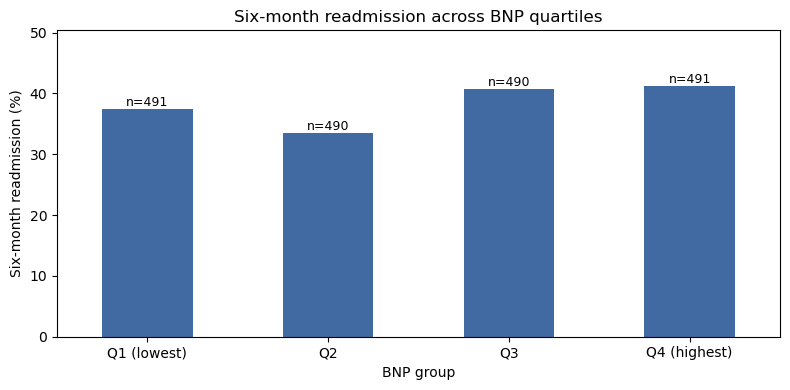

In [24]:
# Step 1: Keep patients with nonmissing BNP and a known binary outcome.
q11 = analysis_rows([BNP], verbose=False)
q11 = q11.loc[q11[BNP] >= 0].copy()

# Step 2: Rank BNP, then make four roughly equal-sized groups. Ranking
# avoids qcut's duplicate-edge error if several patients have the same BNP.
q11["BNP_quartile"] = pd.qcut(q11[BNP].rank(method="first"), 4,
                              labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
display(q11.groupby("BNP_quartile", observed=True)[BNP].agg(["min", "median", "max"]))
q11_rates = outcome_rates(q11, "BNP_quartile", OUTCOME)
display(q11_rates)

# Step 3: Compare observed rates and test whether their distribution differs.
cont = pd.crosstab(q11["BNP_quartile"], q11[OUTCOME])
chi2, p, _, expected = chi2_contingency(cont)
rank_r, trend_p = stats.spearmanr(q11["BNP_quartile"].cat.codes, q11[OUTCOME])

# Step 4: Plot percentages AND show the patient counts on each bar.
ax = q11_rates["rate_pct"].plot.bar(figsize=(8, 4), color="#4169a2", rot=0)
ax.set(ylabel="Six-month readmission (%)", xlabel="BNP group",
       title="Six-month readmission across BNP quartiles")
for bar, count in zip(ax.patches, q11_rates["n"]):
    ax.annotate(f"n={count}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.ylim(0, max(5, q11_rates["rate_pct"].max() * 1.22))
plt.tight_layout(); plt.show()


**Findings for Q11**

Across 1,962 patients with usable BNP and outcome data, six-month readmission was 37.5% in the lowest BNP quartile, 33.5% in the second, 40.8% in the third, and 41.3% in the highest. The rates differ across quartiles (chi-square p = 0.0417), but they do not rise steadily as BNP increases; the rank trend was weak (r = 0.044, p = 0.0536). BNP by itself therefore gives a mixed readmission signal in this cohort.

**Why Q12 matters**

BNP could reflect information already captured by severity grades.
Test whether adding it to the two severity measures improves separation of
readmitted versus non-readmitted patients *on the same complete-case sample*.

### Q12. Does BNP add information about six-month readmission beyond NYHA and Killip?

**How:** Compare severity-only and severity-plus-BNP logistic models with
five-fold cross-validated ROC AUC. The likelihood-ratio test offers a separate
measure of association after accounting for NYHA and Killip. This is exploratory
analysis, not a validated clinical prediction model.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss

# Step 1: Same complete patients and outcomes for BOTH model comparisons.
q12 = analysis_rows([NYHA, KILLIP, BNP], verbose=False)
q12 = q12.loc[q12[BNP] >= 0].copy()
q12["log_BNP"] = np.log1p(q12[BNP])  # Compress the right-skewed BNP distribution.
baseline = q12[[NYHA, KILLIP]].to_numpy()
expanded = q12[[NYHA, KILLIP, "log_BNP"]].to_numpy()
y12 = q12[OUTCOME].astype(int).to_numpy()

# Step 2: Split data into the same stratified folds for both models.
folds = min(5, np.bincount(y12).min())
if folds < 2:
    raise ValueError("Not enough outcomes in both classes for Q12 validation.")
cv12 = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
results12 = {}
for name, x in [("NYHA + Killip", baseline), ("NYHA + Killip + BNP", expanded)]:
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    probabilities = cross_val_predict(model, x, y12, cv=cv12, method="predict_proba")[:, 1]
    results12[name] = [roc_auc_score(y12, probabilities),
                       brier_score_loss(y12, probabilities)]
comparison12 = pd.DataFrame(results12, index=["CV ROC AUC (higher better)",
                                             "CV Brier score (lower better)"]).T
display(comparison12.round(3))

# Step 3: Test whether BNP is associated with the outcome after accounting
# for the two severity grades on these same patients.
lr12, p12 = nested_logistic_test(y12, baseline, q12[["log_BNP"]])


,CV ROC AUC (higher better),CV Brier score (lower better)
NYHA + Killip,0.558,0.234
NYHA + Killip + BNP,0.548,0.234


**Findings for Q12**

On the same 1,962 patients, adding BNP to NYHA and Killip reduced cross-validated ROC AUC from 0.558 to 0.548; the Brier score remained 0.234. The adjusted likelihood-ratio comparison also found no clear additional association (p = 0.5244). In this analysis, BNP did not improve separation of patients who were and were not readmitted beyond the two severity grades. Both models had limited discrimination.

**Why Q13 matters**

These measures represent different clinical domains. We examine whether
patients with none, one, two, or all three recorded signals show different
observed outcomes, while checking the number of patients in every subgroup.

### Q13. Does the combination of admission severity, BNP and renal function identify a different readmission subgroup?

**Group rules:** severe presentation = NYHA 4 **or** Killip 3–4;
higher BNP = at or above the *complete-case cohort median*; low GFR = <60.
These are exploratory categories, not clinical recommendations.

,n,events,rate_pct
signals,,,
0,381,108,28.300
1,667,242,36.300
2,594,265,44.600
3,266,119,44.700


n  events  rate_pct
severe high_BNP low_GFR                       
0      0        0        381     108    28.300
                1        219      83    37.900
       1        0        246      77    31.300
                1        233     118    50.600
1      0        0        202      82    40.600
                1        152      67    44.100
       1        0        209      80    38.300
                1        266     119    44.700

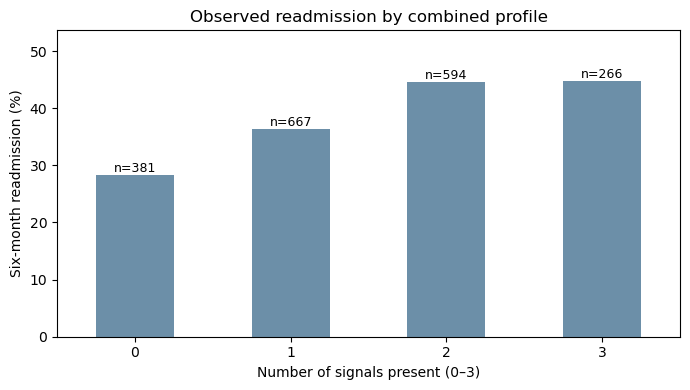

In [26]:
# Step 1: Restrict to patients who have all three markers AND outcome recorded.
q13 = analysis_rows([NYHA, KILLIP, BNP, GFR], verbose=False)
q13 = q13.loc[(q13[BNP] >= 0) & (q13[GFR] > 0)].copy()
median_bnp13 = q13[BNP].median()
q13["severe"] = severe_presentation(q13).astype(int)
q13["high_BNP"] = (q13[BNP] >= median_bnp13).astype(int)
q13["low_GFR"] = (q13[GFR] < 60).astype(int)
q13["signals"] = q13[["severe", "high_BNP", "low_GFR"]].sum(axis=1)

# Step 2: Compare rates with their denominators; 0 vs 3 is useful only if
# both groups have enough observations to interpret.
rates13 = outcome_rates(q13, "signals", OUTCOME).reindex([0, 1, 2, 3], fill_value=0)
display(rates13)
profiles13 = outcome_rates(q13, ["severe", "high_BNP", "low_GFR"], OUTCOME)
display(profiles13)

# Association test for the prespecified 0–3 signal count. A rate gradient
# supports an association only if the sample sizes and trend also support it.
rho13, p13 = stats.spearmanr(q13["signals"], q13[OUTCOME])

# Step 3: Visualize observed rates; show n above each bar to avoid hiding
# an unstable high percentage in a small subgroup.
ax = rates13["rate_pct"].plot.bar(figsize=(7, 4), rot=0, color="#6c8fa8")
ax.set(xlabel="Number of signals present (0–3)",
       ylabel="Six-month readmission (%)", title="Observed readmission by combined profile")
for bar, count in zip(ax.patches, rates13["n"]):
    ax.annotate(f"n={count}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.ylim(0, max(5, rates13["rate_pct"].max()*1.2))
plt.tight_layout(); plt.show()


**Findings for Q13**

Among 1,908 patients with all three markers available, readmission was 28.3% (108/381) when none of the specified signals were present and 44.7% (119/266) when all three were present. Readmission increased across the 0–3 signal count overall (rank r = 0.124, p < 0.001), but the two-signal group already had a similar rate of 44.6%. The individual profiles differ too: higher BNP plus low GFR without the higher-severity flag had a 50.6% observed rate (118/233). These are exploratory groupings, not a validated risk score.

## Family 4 — Comorbidity and Demographic Risk (Questions 14–18)

We use the recorded Charlson comorbidity index (`cci_score`), recorded
diagnosis flags, and age *categories* from the cleaning notebook. The age
file has bands, not each patient's exact age. Most questions use six-month
readmission; Q15 uses the separate, rarer six-month death indicator.

**Why Q14 matters**

A higher CCI summarizes more recorded comorbidity burden. Groups
0–1, 2 and 3+ preserve a usable size in each category; they do not imply
that the score itself changes the patient's outcome.

### Q14. Is higher CCI associated with higher six-month readmission?

,n,events,rate_pct
CCI_group,,,
0–1,822,292,35.500
2,696,261,37.500
3+,474,213,44.900


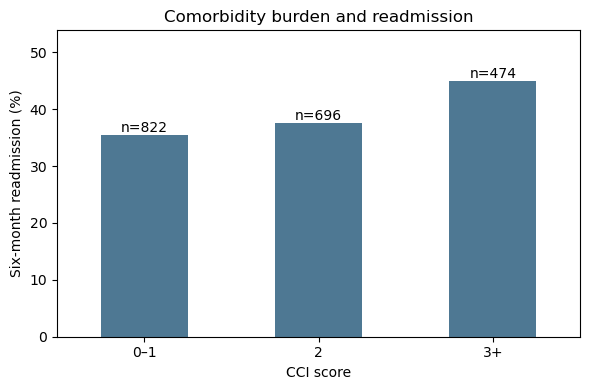

In [27]:
# Step 1: Keep a known CCI and known readmission outcome.
q14 = analysis_rows([CCI], verbose=False)
q14 = q14.loc[q14[CCI] >= 0].copy()
q14["CCI_group"] = pd.cut(q14[CCI], [-0.1, 1, 2, np.inf],
                          labels=["0–1", "2", "3+"])

# Step 2: Calculate within-group readmission rates and event counts.
rates14 = outcome_rates(q14, "CCI_group", OUTCOME)
display(rates14)
table14 = pd.crosstab(q14["CCI_group"], q14[OUTCOME])
chi2_14, p14, _, expected14 = chi2_contingency(table14)
rho14, trend14 = stats.spearmanr(q14[CCI], q14[OUTCOME])

# Step 3: Show both denominators and rates; report what the actual pattern says.
ax = rates14["rate_pct"].plot.bar(figsize=(6, 4), rot=0, color="#4e7893")
ax.set(xlabel="CCI score", ylabel="Six-month readmission (%)",
       title="Comorbidity burden and readmission")
for bar, count in zip(ax.patches, rates14["n"]):
    ax.annotate(f"n={count}", (bar.get_x()+bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom")
plt.ylim(0, max(5, rates14["rate_pct"].max()*1.2))
plt.tight_layout(); plt.show()


**Findings for Q14**

Readmission rose across CCI groups: 35.5% (292/822) for CCI 0–1, 37.5% (261/696) for CCI 2, and 44.9% (213/474) for CCI 3 or higher. The group comparison gave p = 0.0029, although the patient-level rank association was small (r = 0.070). Higher recorded comorbidity burden is associated with readmission here; this analysis does not show that CCI causes it.

**Why Q15 matters**

A death outcome may show a different pattern from readmission.
Deaths are less frequent, so we report raw death counts and use Fisher's
exact test for a clearly defined comparison (CCI 3+ versus 0–2).
Small numbers can produce unstable percentages.

### Q15. Is higher CCI associated with six-month mortality?

In [28]:
# Step 1: Select known CCI and recorded mortality; exclude flagged
# destination/outcome contradictions when the cleaning file supplies the flag.
q15 = analysis_rows([CCI], outcome=DEATH, verbose=False)
q15 = q15.loc[q15[CCI] >= 0].copy()
q15["CCI_group"] = pd.cut(q15[CCI], [-0.1, 1, 2, np.inf],
                          labels=["0–1", "2", "3+"])
deaths15 = outcome_rates(q15, "CCI_group", DEATH)
display(deaths15.rename(columns={"events": "deaths"}))

# Step 2: Compare two broad groups using an exact test for uncommon deaths.
q15["CCI_3plus"] = q15[CCI] >= 3
mortality_table = pd.crosstab(q15["CCI_3plus"], q15[DEATH]).reindex(
    index=[False, True], columns=[0.0, 1.0], fill_value=0)
display(mortality_table.rename(index={False: "CCI 0–2", True: "CCI 3+"},
                               columns={0.0: "Alive at six months", 1.0: "Died by six months"}))
odds15, p15 = stats.fisher_exact(mortality_table.to_numpy())


,n,deaths,rate_pct
CCI_group,,,
0–1,825,21,2.500
2,698,19,2.700
3+,473,15,3.200


death_within_6_months,Alive at six months,Died by six months
CCI_3plus,,
CCI 0–2,1483,40
CCI 3+,458,15


**Findings for Q15**

Six-month mortality was 2.5% (21/825) for CCI 0–1, 2.7% (19/698) for CCI 2, and 3.2% (15/473) for CCI 3 or higher. The comparison of CCI 3+ with CCI 0–2 did not show a clear difference (Fisher exact p = 0.5217). Only 55 deaths were available after exclusions, so these subgroup percentages are less stable than the readmission rates. The results do not support a strong mortality conclusion from CCI alone.

**Why Q16 matters**

CCI combines diagnoses into one number. We compare that number
alone with CCI plus three adequately prevalent, recorded flags: diabetes,
moderate-to-severe CKD and COPD. On *the same patients*, compare held-out
readmission separation. Also show each condition's observed yes/no rates.

### Q16. Do common individual comorbidities add information beyond CCI?

**Important:** The CKD flag and diabetes may contribute to CCI itself;
improvement is not proof that any condition causes readmission.

In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, brier_score_loss

# Step 1: Fix the condition set before comparing models.
conditions16 = ["diabetes", CKD, "chronic_obstructive_pulmonary_disease"]
q16 = analysis_rows([CCI] + conditions16, verbose=False)
q16 = q16.loc[(q16[CCI] >= 0) & q16[conditions16].isin([0, 1]).all(axis=1)].copy()
for condition in conditions16:
    display(outcome_rates(q16, condition, OUTCOME).rename(index={0: "Absent", 1: "Present"}))

# Step 2: Compare two models in identical held-out folds on identical rows.
y16 = q16[OUTCOME].astype(int).to_numpy()
folds16 = min(5, np.bincount(y16).min())
if folds16 < 2:
    raise ValueError("Not enough cases of both outcome classes for Q16.")
cv16 = StratifiedKFold(n_splits=folds16, shuffle=True, random_state=42)
metrics16 = {}
for name, cols in [("CCI alone", [CCI]), ("CCI + three conditions", [CCI] + conditions16)]:
    x16 = q16[cols].to_numpy()
    model16 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    probabilities16 = cross_val_predict(
        model16, x16, y16, cv=cv16, method="predict_proba")[:, 1]
    metrics16[name] = [roc_auc_score(y16, probabilities16),
                       brier_score_loss(y16, probabilities16)]
display(pd.DataFrame(metrics16, index=["CV ROC AUC (higher better)",
                                        "CV Brier score (lower better)"]).T.round(3))

# Step 3: Nested-model association test complements held-out performance.
lr16, p16 = nested_logistic_test(y16, q16[[CCI]], q16[conditions16])


,n,events,rate_pct
diabetes,,,
Absent,1534,557,36.300
Present,458,209,45.600


,n,events,rate_pct
moderate_to_severe_chronic_kidney_disease,,,
Absent,1523,551,36.200
Present,469,215,45.800


,n,events,rate_pct
chronic_obstructive_pulmonary_disease,,,
Absent,1761,679,38.600
Present,231,87,37.700


,CV ROC AUC (higher better),CV Brier score (lower better)
CCI alone,0.533,0.235
CCI + three conditions,0.540,0.235


**Findings for Q16**

Readmission was higher among patients flagged for diabetes (45.6% versus 36.3% without it) and moderate-to-severe CKD (45.8% versus 36.2%); COPD showed little difference (37.7% versus 38.6%). Adding these three flags to CCI gave a small cross-validated ROC AUC increase from 0.533 to 0.540, while the Brier score stayed at 0.235. The likelihood-ratio test found an association beyond CCI (p = 0.0125), but the held-out performance gain was modest. The flags warrant further testing, without claiming they make a strong predictive model.

**Why Q17 matters**

Compare patients with neither diagnosis, each diagnosis alone, and
both. A formal interaction test asks whether the combined relationship differs
from what an additive-log-odds model of the separate flags would predict.
A high rate in the both group **by itself** does not establish an interaction.

### Q17. Does having both CKD and diabetes identify a different six-month readmission profile?

,n,events,rate_pct
profile,,,
Neither,1228,424,34.500
Diabetes only,296,127,42.900
CKD only,306,133,43.500
Both,165,84,50.900


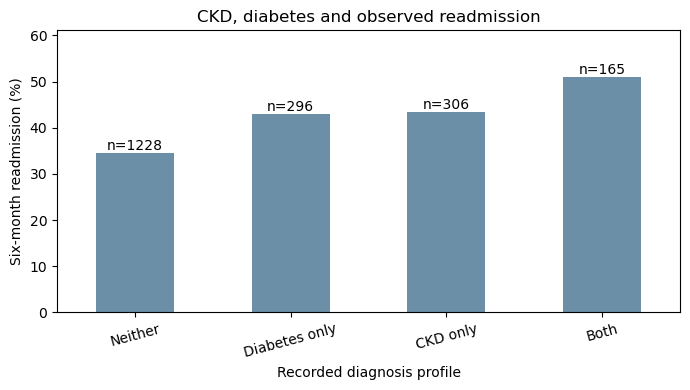

In [30]:
# Step 1: Keep recorded (0/1) CKD, diabetes and readmission indicators.
q17 = analysis_rows([CKD, "diabetes"], verbose=False)
q17 = q17.loc[q17[[CKD, "diabetes"]].isin([0, 1]).all(axis=1)].copy()
labels17 = {(0, 0): "Neither", (0, 1): "Diabetes only",
            (1, 0): "CKD only", (1, 1): "Both"}
q17["profile"] = [labels17[(int(ckd), int(dm))]
                  for ckd, dm in zip(q17[CKD], q17["diabetes"])]
ordered17 = ["Neither", "Diabetes only", "CKD only", "Both"]
rates17 = outcome_rates(q17, "profile", OUTCOME).reindex(ordered17)
display(rates17)

# Step 2: Test the CKD × diabetes interaction separately from the group table.
q17["CKD_x_diabetes"] = q17[CKD] * q17["diabetes"]
lr17, p17 = nested_logistic_test(q17[OUTCOME], q17[[CKD, "diabetes"]],
                                 q17[["CKD_x_diabetes"]])

# Step 3: Show observed rates together with their group sizes.
ax = rates17["rate_pct"].plot.bar(figsize=(7, 4), color="#6c8fa8", rot=15)
ax.set(xlabel="Recorded diagnosis profile", ylabel="Six-month readmission (%)",
       title="CKD, diabetes and observed readmission")
for bar, count in zip(ax.patches, rates17["n"]):
    ax.annotate(f"n={count}", (bar.get_x()+bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom")
plt.ylim(0, max(5, rates17["rate_pct"].max()*1.2))
plt.tight_layout(); plt.show()


**Findings for Q17**

Readmission was 34.5% (424/1,228) with neither recorded CKD nor diabetes, 42.9% (127/296) with diabetes only, 43.5% (133/306) with CKD only, and 50.9% (84/165) with both. The both-condition group had the highest observed rate. However, the formal CKD-by-diabetes interaction test was not supported (p = 0.815); the higher rate does not establish an additional combined association beyond the two separate conditions.

**Why Q18 matters**

The original data reports age *bands*, not exact age. Compare
patients in bands starting at 79 or older with those in bands starting below
79. The high-severity rule is the same as Q13 (NYHA 4 or Killip 3–4).
An interaction test checks whether the relationship between this severity
indicator and readmission differs by age-band group.

### Q18. Does the relationship between admission severity and readmission differ by age group?

**Limit:** The `69–79` and `79–89` labels overlap at the boundary, so the
comparison uses the *recorded band labels*, not a confirmed exact age cutoff.

n  events  rate_pct
age_band_group     severity_group                       
Bands starting 79+ Higher          334     131    39.200
                   Lower           407     152    37.300
Bands starting <79 Higher          537     234    43.600
                   Lower           719     251    34.900

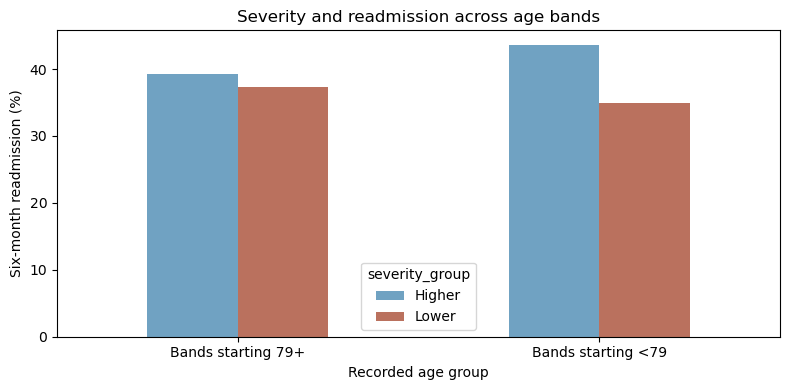

In [31]:
# Step 1: Use the age CATEGORY produced by the cleaning notebook. Extract
# only the beginning of the recorded category, never invent an exact age.
q18 = analysis_rows(["age_category", NYHA, KILLIP], verbose=False)
q18["age_band_start"] = pd.to_numeric(
    q18["age_category"].astype(str).str.extract(r"^(\d+)")[0], errors="coerce")
q18 = q18.dropna(subset=["age_band_start"]).copy()
q18["older_band"] = (q18["age_band_start"] >= 79).astype(int)
q18["high_severity"] = severe_presentation(q18).astype(int)
q18["age_band_group"] = q18["older_band"].map({0: "Bands starting <79", 1: "Bands starting 79+"})
q18["severity_group"] = q18["high_severity"].map({0: "Lower", 1: "Higher"})

# Step 2: Compare all four age-by-severity groups using outcome percentages
# and denominators; rates alone can disguise uneven group sizes.
rates18 = outcome_rates(q18, ["age_band_group", "severity_group"], OUTCOME)
display(rates18)

# Step 3: Formal multiplicative interaction on the log-odds scale.
q18["age_x_severity"] = q18["older_band"] * q18["high_severity"]
lr18, p18 = nested_logistic_test(q18[OUTCOME],
                                q18[["older_band", "high_severity"]],
                                q18[["age_x_severity"]])

# Step 4: Compare the two severity rates *within each age-band group*.
plot18 = rates18["rate_pct"].unstack("severity_group")
ax = plot18.plot.bar(figsize=(8, 4), rot=0, color=["#70a2c2", "#ba715e"])
ax.set(xlabel="Recorded age group", ylabel="Six-month readmission (%)",
       title="Severity and readmission across age bands")
plt.tight_layout(); plt.show()


**Findings for Q18**

In age bands starting below 79, readmission was 43.6% in the higher-severity group versus 34.9% in the lower-severity group. In bands starting at 79 or above, the corresponding rates were 39.2% and 37.3%. Although the observed gaps differ, the age-band-by-severity interaction was not clear statistically (p = 0.1367). The data therefore do not establish that the severity relationship changes with age band; these are recorded age ranges rather than exact ages.

### Summary for the team

Questions 11–18 found the clearest differences in **six-month readmission** when patient characteristics were considered together. Among patients with complete data, 28.3% of those with none of the three selected signals—higher admission severity, higher BNP, or lower GFR—were readmitted, compared with 44.7% of those with all three. Readmission also increased across CCI groups, from 35.5% for scores of 0–1 to 44.9% for scores of 3 or higher.

Some results were less clear. BNP did not improve the NYHA-and-Killip model’s performance on held-out data. Patients with both recorded CKD and diabetes had a higher readmission rate than those with neither (50.9% versus 34.5%), but the interaction test did not show that the combination was associated with more risk than the two conditions considered separately. We also found no clear age-by-severity interaction or strong evidence that CCI groups differed in six-month mortality; there were only 55 deaths in that analysis.

These findings make six-month readmission the strongest outcome to carry into predictive analysis. Severity, kidney function, and comorbidity are reasonable candidate inputs, but the model still needs to be tested on held-out patients. These observational results show associations, not causes.

## Section 5 - Treatment Pattern → Hospital Resource Use¶

### Q19. Is higher medication burden associated with longer hospitalization?

### Why this question?
Medication burden can reflect the complexity of a patient's clinical management. If patients receiving more medications also experience longer hospital stays, medication burden may provide additional information about hospitalization complexity and may be useful as a candidate feature for subsequent multivariate and predictive analysis.

However, medication burden may also reflect underlying disease severity or medications added during a prolonged hospitalization. Therefore, this analysis evaluates **association**, not causation.

#### What are we testing?

We examine whether the number of medications (`total_drug_count`) is associated with hospital length of stay (`dischargeday`).

#### How?
We will:

1. Analyze patients with valid medication-burden and hospitalization-length values.
2. Use **Pearson correlation** to assess a linear relationship.
3. Use **Spearman correlation** as a rank-based measure that is less sensitive to skewed distributions and outliers.
4. Estimate a **95% bootstrap confidence interval** for the Spearman correlation.
5. Use an unadjusted linear regression to quantify the change in hospital days associated with one additional medication.
6. Compare hospitalization length across medication-burden quartiles.

#### Expected outcome
The analysis will determine whether medication burden shows a measurable association with hospitalization length and quantify the strength and uncertainty of that relationship. The result will help determine whether medication burden should be considered in subsequent multivariable or predictive analyses.


In [32]:
# Q19: Prepare analysis dataset
# Use the patient_master dataframe already loaded at the beginning of the notebook.

q19_cols = ['total_drug_count', 'dischargeday']

df_q19 = (
    df[q19_cols]
    .copy()
    .dropna()
)

# Retain clinically meaningful non-negative values
df_q19 = df_q19[
    (df_q19['total_drug_count'] >= 0) &
    (df_q19['dischargeday'] >= 0)
].copy()

print(f"Valid patient records analyzed: {len(df_q19):,}")

display(
    df_q19.describe().T
)

Valid patient records analyzed: 2,008


,count,mean,std,min,25%,50%,75%,max
total_drug_count,"2,008.000",7.650,2.432,0.000,6.000,8.000,9.000,16.000
dischargeday,"2,008.000",9.421,8.030,1.000,6.000,8.000,10.000,123.000


#### Step 1 — Examine the relationship

Because hospitalization length can be skewed and medication burden is a count variable, both Pearson and Spearman correlations are examined.

* **Pearson correlation** measures the strength of a linear relationship.
* **Spearman correlation** evaluates whether patients with higher medication burden tend to have higher or lower hospitalization length, based on ranks.

Using both provides a robustness check rather than relying on a single measure.


In [33]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(
    df_q19['total_drug_count'],
    df_q19['dischargeday']
)

# Spearman rank correlation
spearman_rho, spearman_p = stats.spearmanr(
    df_q19['total_drug_count'],
    df_q19['dischargeday']
)

print("Q19 Correlation Results")
print("-" * 50)
print(f"Pearson r       : {pearson_r:.4f}")
print(f"Pearson p-value : {pearson_p:.4g}")
print(f"Spearman ρ      : {spearman_rho:.4f}")
print(f"Spearman p-value: {spearman_p:.4g}")

Q19 Correlation Results
--------------------------------------------------
Pearson r       : 0.1963
Pearson p-value : 6.825e-19
Spearman ρ      : 0.2756
Spearman p-value: 2.49e-36


#### Step 2 — Quantify uncertainty

A correlation coefficient is only an estimate from this patient cohort. To quantify uncertainty around the observed Spearman association, we use bootstrap resampling to calculate a **95% confidence interval**.

If the interval remains on the same side of zero, the observed direction of association is more stable across resampled versions of the cohort.


In [34]:
# Bootstrap 95% CI for Spearman correlation

rng = np.random.default_rng(42)

x = df_q19['total_drug_count'].to_numpy()
y = df_q19['dischargeday'].to_numpy()

n_bootstrap = 5000
bootstrap_rhos = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    sample_idx = rng.integers(
        0,
        len(df_q19),
        size=len(df_q19)
    )

    bootstrap_rhos[i] = stats.spearmanr(
        x[sample_idx],
        y[sample_idx]
    ).statistic

spearman_ci_lower, spearman_ci_upper = np.percentile(
    bootstrap_rhos,
    [2.5, 97.5]
)

print("Spearman Correlation with Bootstrap 95% CI")
print("-" * 50)
print(f"Spearman ρ : {spearman_rho:.4f}")
print(
    f"95% CI     : "
    f"({spearman_ci_lower:.4f}, {spearman_ci_upper:.4f})"
)

Spearman Correlation with Bootstrap 95% CI
--------------------------------------------------
Spearman ρ : 0.2756
95% CI     : (0.2330, 0.3162)


#### Step 3 — Estimate the practical effect

Correlation describes the strength of association but does not express the relationship in hospital-day units.

An unadjusted linear regression is therefore used to estimate the average change in hospitalization length associated with one additional medication.

This is an **unadjusted association**. It should not be interpreted as the causal effect of prescribing another medication.


In [35]:
# Unadjusted linear regression:
# Hospital LOS ~ medication burden

X = sm.add_constant(df_q19['total_drug_count'])
y = df_q19['dischargeday']

q19_model = sm.OLS(y, X).fit()

beta = q19_model.params['total_drug_count']
beta_ci = q19_model.conf_int().loc['total_drug_count']
beta_p = q19_model.pvalues['total_drug_count']

print("Unadjusted Linear Regression")
print("-" * 50)
print(f"LOS change per additional medication: {beta:.4f} days")
print(
    f"95% CI: ({beta_ci.iloc[0]:.4f}, "
    f"{beta_ci.iloc[1]:.4f})"
)
print(f"p-value: {beta_p:.4g}")
print(f"R²: {q19_model.rsquared:.4f}")

Unadjusted Linear Regression
--------------------------------------------------
LOS change per additional medication: 0.6482 days
95% CI: (0.5064, 0.7900)
p-value: 6.825e-19
R²: 0.0385


#### Step 4 — Compare hospitalization across medication-burden groups

To make the relationship easier to interpret clinically, patients are divided into four medication-burden groups using quartiles.

We compare median and interquartile-range LOS across these groups. This provides a distribution-based view that does not depend on the linear-regression assumption.


In [36]:
# Create medication-burden quartiles
df_q19['medication_burden_group'] = pd.qcut(
    df_q19['total_drug_count'],
    q=4,
    duplicates='drop'
)

q19_group_summary = (
    df_q19
    .groupby('medication_burden_group', observed=True)
    .agg(
        patients=('dischargeday', 'size'),
        median_drugs=('total_drug_count', 'median'),
        median_los=('dischargeday', 'median'),
        q1_los=('dischargeday', lambda x: x.quantile(0.25)),
        q3_los=('dischargeday', lambda x: x.quantile(0.75))
    )
    .reset_index()
)

display(q19_group_summary)

,medication_burden_group,patients,median_drugs,median_los,q1_los,q3_los
0,"(-0.001, 6.0]",624,5.000,7.000,5.000,9.000
1,"(6.0, 8.0]",662,8.000,8.000,6.000,10.000
2,"(8.0, 9.0]",281,9.000,8.000,6.000,11.000
3,"(9.0, 16.0]",441,11.000,9.000,7.000,13.000


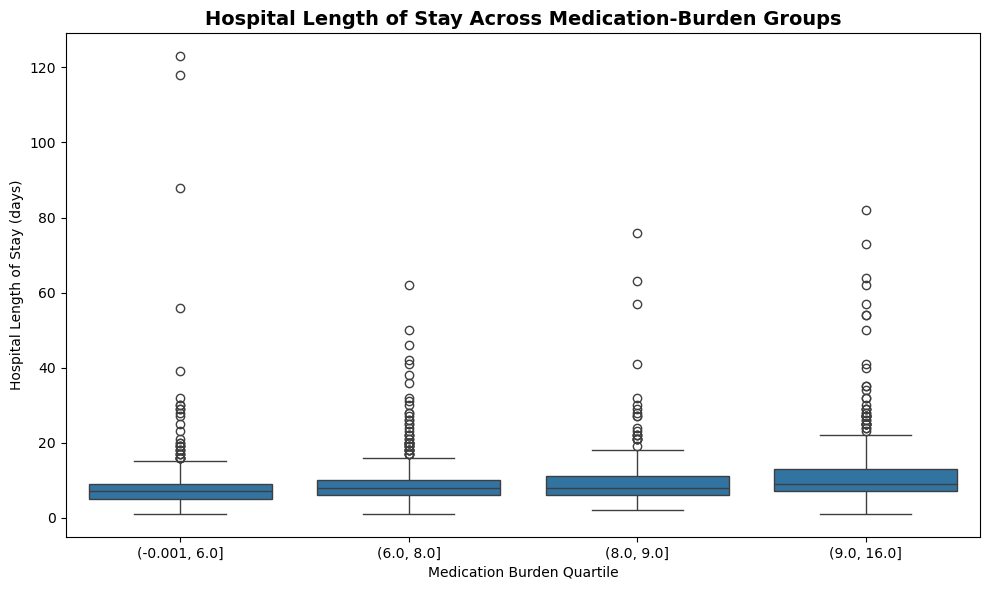

In [37]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_q19,
    x='medication_burden_group',
    y='dischargeday'
)

plt.title(
    'Hospital Length of Stay Across Medication-Burden Groups',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Medication Burden Quartile')
plt.ylabel('Hospital Length of Stay (days)')

plt.tight_layout()
plt.show()

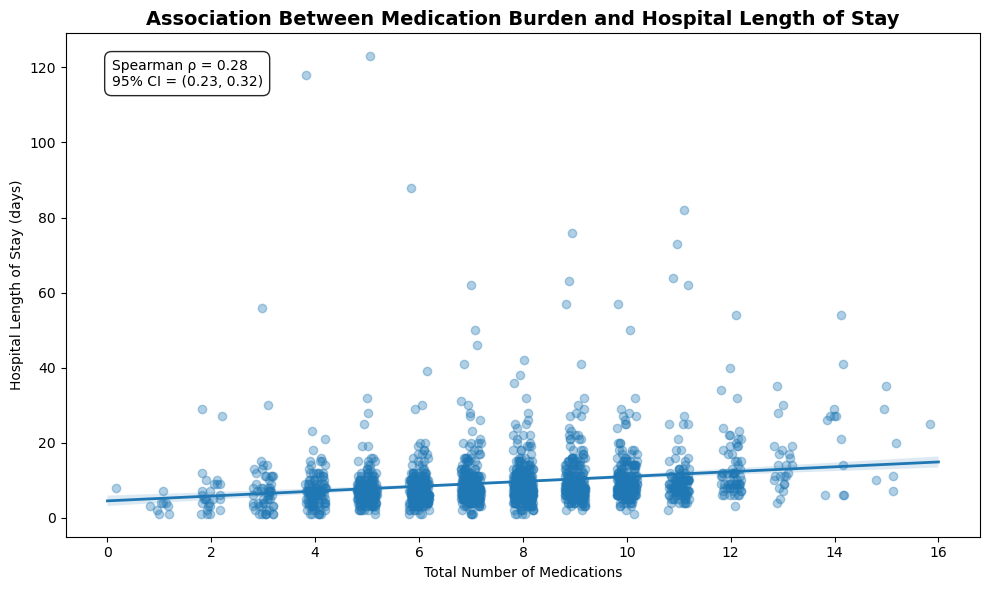

In [38]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_q19,
    x='total_drug_count',
    y='dischargeday',
    x_jitter=0.2,
    scatter_kws={'alpha': 0.35},
    line_kws={'linewidth': 2}
)

plt.title(
    'Association Between Medication Burden and Hospital Length of Stay',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Total Number of Medications')
plt.ylabel('Hospital Length of Stay (days)')

annotation = (
    f"Spearman ρ = {spearman_rho:.2f}\n"
    f"95% CI = ({spearman_ci_lower:.2f}, "
    f"{spearman_ci_upper:.2f})"
)

plt.text(
    0.05,
    0.95,
    annotation,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        alpha=0.85
    )
)

plt.tight_layout()
plt.show()

#### Finding

Among **2,008 patients**, higher medication burden was associated with longer hospital length of stay.

The relationship was positive using both correlation measures. Pearson's correlation was **r = 0.196**, while Spearman's rank correlation was **ρ = 0.276 (95% CI: 0.233–0.316)**. The consistency in direction across both measures supports a positive association between medication burden and hospitalization length.

The unadjusted linear model estimated that each additional medication was associated with approximately **0.65 additional hospital days** (95% CI: **0.51–0.79 days**). However, the model had an **R² of 0.0385**, indicating that medication burden alone explained only about **3.9% of the variation in hospitalization length**.

The medication-burden quartile analysis showed a similar pattern. Median LOS increased from **7 days** in the lowest medication-burden group to **9 days** in the highest group, with the middle groups having a median LOS of **8 days**.

#### Interpretation

The findings support an association between higher medication burden and longer hospitalization in this cohort. The effect is statistically precise and directionally consistent across correlation and group-based analyses, but the relatively low R² indicates that medication burden is only one of many factors related to hospitalization duration.

Therefore, medication burden should be viewed as a **candidate explanatory feature**, rather than a standalone determinant of length of stay.

#### Limitation

This analysis is observational and unadjusted, so it does not establish causality.

In particular, medication burden may reflect **underlying disease severity, comorbidity, or treatment complexity**. Reverse causation is also possible: patients who remain hospitalized longer may receive additional medications during their hospitalization, creating an association between medication count and LOS without medication burden itself causing the longer stay.

#### How this helps the next analysis

The finding motivates a multivariable analysis to determine whether medication burden remains associated with hospitalization length **after accounting for relevant measures of disease severity and comorbidity**.

This will help determine whether medication burden contributes information beyond the patient's underlying clinical complexity and whether it should be retained as a candidate feature for subsequent predictive analysis.


### Q20. Does the association between medication burden and length of stay remain after accounting for admission severity?

#### Why?
Q19 found that higher medication burden was associated with longer hospital stays. However, patients with greater admission severity may both require more medications and stay longer. This question checks whether medication burden retains an association with length of stay after accounting for admission severity.

#### What?

We compare the medication-burden effect in:

* **Model 1:** LOS ~ medication burden
* **Model 2:** LOS ~ medication burden + NYHA + Killip

#### How?

NYHA and Killip are ordinal clinical severity grades, so they are treated as categorical variables. We compare the medication coefficient, confidence interval, and model fit between the two models.

#### Expected outcome

If the medication coefficient remains similar after adjustment, medication burden provides information beyond admission severity. If it decreases substantially, the Q19 association may be partly explained by differences in patient severity.


In [166]:
df_q21 = df[
    [
        'total_drug_count',
        'dischargeday',
        'nyha_cardiac_function_classification',
        'killip_grade'
    ]
].dropna().copy()

# Use the same prolonged-stay definition established in Q21
los_threshold = df['dischargeday'].quantile(0.75)

df_q21['prolonged_stay'] = (
    df_q21['dischargeday'] >= los_threshold
).astype(int)

print(f"Patients analyzed: {len(df_q21):,}")
print(f"Prolonged-stay threshold: {los_threshold:.1f} days")

Patients analyzed: 2,008
Prolonged-stay threshold: 10.0 days


In [165]:
# Model 1: unadjusted association
model_1 = smf.ols(
    'dischargeday ~ total_drug_count',
    data=df_q20
).fit()

# Model 2: adjusted for admission severity
model_2 = smf.ols(
    'dischargeday ~ total_drug_count + '
    'C(nyha_cardiac_function_classification) + '
    'C(killip_grade)',
    data=df_q20
).fit()

# Compare medication-burden effect
q20_results = pd.DataFrame({
    'Model': ['Unadjusted', 'Adjusted for NYHA + Killip'],
    'Medication Effect (days)': [
        model_1.params['total_drug_count'],
        model_2.params['total_drug_count']
    ],
    'CI Lower': [
        model_1.conf_int().loc['total_drug_count', 0],
        model_2.conf_int().loc['total_drug_count', 0]
    ],
    'CI Upper': [
        model_1.conf_int().loc['total_drug_count', 1],
        model_2.conf_int().loc['total_drug_count', 1]
    ],
    'p-value': [
        model_1.pvalues['total_drug_count'],
        model_2.pvalues['total_drug_count']
    ],
    'R²': [
        model_1.rsquared,
        model_2.rsquared
    ]
})

display(q20_results.round(3))

,Model,Medication Effect (days),CI Lower,CI Upper,p-value,R²
0,Unadjusted,0.648,0.506,0.790,0.000,0.039
1,Adjusted for NYHA + Killip,0.644,0.501,0.787,0.000,0.041


#### Finding
The medication–length-of-stay association remained almost unchanged after accounting for admission severity. The estimated effect decreased only from **0.648 to 0.644 additional hospital days per medication**, a **0.6% change**, with the adjusted 95% CI remaining positive (**0.501–0.787 days**).

Model R² increased only slightly from **0.039 to 0.041**, indicating that NYHA and Killip added limited explanatory power for length of stay in this analysis.

#### Prescriptive implication
Medication burden may be useful as an indicator of treatment complexity when considering expected length of stay, even after accounting for admission severity. However, this is an **association, not evidence that medications cause longer stays**. Other factors may contribute to LOS and should be considered in the next analysis.


## Q21. Which observed treatment patterns are associated with prolonged hospitalization after accounting for admission severity?

### Why?

Q20 showed that the medication–length-of-stay association remained almost unchanged after accounting for NYHA and Killip. We therefore examine whether **higher treatment intensity**, measured by the number of distinct medications recorded for a patient, is associated with prolonged hospitalization.

### What?

Patients are grouped by observed medication burden, and their length of stay is compared while accounting for admission severity.

### How?

We compare LOS across medication-burden groups and use an adjusted model including medication burden, NYHA, and Killip.

### Expected outcome

Identify whether higher treatment intensity is associated with longer hospitalization beyond differences in admission severity, helping identify treatment-complexity patterns relevant to resource planning.


In [49]:
los_threshold = df['dischargeday'].quantile(0.75)

print(f"75th percentile LOS threshold: {los_threshold:.1f} days")

df_q21 = df[
    [
        'dischargeday',
        'total_drug_count',
        'nyha_cardiac_function_classification',
        'killip_grade'
    ]
].dropna().copy()

df_q21['prolonged_stay'] = (
    df_q21['dischargeday'] >= los_threshold
).astype(int)

print("\nProlonged-stay distribution:")
print(df_q21['prolonged_stay'].value_counts())
print(
    df_q21['prolonged_stay']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

75th percentile LOS threshold: 10.0 days

Prolonged-stay distribution:
prolonged_stay
0    1366
1     642
Name: count, dtype: int64
prolonged_stay
0   68.000
1   32.000
Name: proportion, dtype: float64


In [50]:
# Use quartiles of observed medication burden
df_q21['treatment_intensity'] = pd.qcut(
    df_q21['total_drug_count'],
    q=4,
    duplicates='drop'
)

q21_summary = (
    df_q21
    .groupby('treatment_intensity', observed=True)
    .agg(
        patients=('dischargeday', 'size'),
        median_drugs=('total_drug_count', 'median'),
        median_los=('dischargeday', 'median'),
        prolonged_stay_rate=('prolonged_stay', 'mean')
    )
    .reset_index()
)

q21_summary['prolonged_stay_rate'] *= 100

display(q21_summary.round(2))

,treatment_intensity,patients,median_drugs,median_los,prolonged_stay_rate
0,"(-0.001, 6.0]",624,5.000,7.000,22.440
1,"(6.0, 8.0]",662,8.000,8.000,30.820
2,"(8.0, 9.0]",281,9.000,8.000,32.380
3,"(9.0, 16.0]",441,11.000,9.000,46.940


In [51]:
# Adjusted association between treatment intensity and prolonged hospitalization
q21_model = smf.logit(
    'prolonged_stay ~ total_drug_count + '
    'C(nyha_cardiac_function_classification) + '
    'C(killip_grade)',
    data=df_q21
).fit(disp=False)

# Convert medication coefficient to odds ratio
drug_coef = q21_model.params['total_drug_count']
drug_or = np.exp(drug_coef)

drug_ci = q21_model.conf_int().loc['total_drug_count']
drug_or_ci = np.exp(drug_ci)

q21_result = pd.DataFrame({
    'Measure': [
        'Medication burden odds ratio',
        '95% CI lower',
        '95% CI upper',
        'p-value'
    ],
    'Value': [
        drug_or,
        drug_or_ci[0],
        drug_or_ci[1],
        q21_model.pvalues['total_drug_count']
    ]
})

display(q21_result.round(3))

,Measure,Value
0,Medication burden odds ratio,1.195
1,95% CI lower,1.146
2,95% CI upper,1.245
3,p-value,0.000


In [52]:
group_rates = (
    df_q21
    .groupby('treatment_intensity', observed=True)['prolonged_stay']
    .agg(['mean', 'count'])
    .reset_index()
)

group_rates['prolonged_stay_rate_pct'] = group_rates['mean'] * 100

lowest_rate = group_rates.iloc[0]['prolonged_stay_rate_pct']
highest_rate = group_rates.iloc[-1]['prolonged_stay_rate_pct']

print(f"Lowest treatment-intensity group: {lowest_rate:.1f}%")
print(f"Highest treatment-intensity group: {highest_rate:.1f}%")
print(f"Absolute difference: {highest_rate - lowest_rate:.1f} percentage points")

Lowest treatment-intensity group: 22.4%
Highest treatment-intensity group: 46.9%
Absolute difference: 24.5 percentage points


#### Finding

Prolonged hospitalization was increasingly common with higher treatment intensity. The prolonged-stay rate increased from **22.4% in the lowest medication-burden group to 46.9% in the highest group**, an absolute difference of **24.5 percentage points**.

After accounting for NYHA and Killip admission severity, each additional recorded medication was associated with **1.195 times the odds of prolonged hospitalization** (95% CI: **1.146–1.245**).

#### Prescriptive implication

Patients with higher treatment intensity represent a group that may require greater hospitalization and resource planning attention. Medication burden can therefore be considered alongside admission severity when identifying patients with greater expected care complexity.

This analysis shows an association and does not establish that medications themselves cause longer hospitalization.


### Q22. Does medication burden identify different 6-month readmission profiles across admission-severity groups?

#### Why?

Q21 showed that higher medication burden was associated with prolonged hospitalization even after accounting for NYHA and Killip severity. We now examine whether medication burden is also associated with different **6-month readmission profiles within admission-severity groups**.

#### What?

Compare 6-month readmission rates across medication-burden groups within each NYHA admission-severity group.

#### How?

Patients are grouped by medication burden using the same four groups established in Q19–Q21. Within each NYHA severity group, we compare the observed proportion of patients with a recorded readmission within 6 months.

The analysis uses the dataset's explicit `re_admission_within_6_months` outcome rather than inferring readmission from missing readmission-time values.

#### Expected outcome

Identify combinations of admission severity and medication burden with different observed readmission rates, helping identify groups that may warrant greater follow-up or discharge-planning attention.


In [57]:
readmit_days = df['readmission_time_days_from_admission']

print("Patients with recorded readmission time:", readmit_days.notna().sum())
print("Patients with missing readmission time:", readmit_days.isna().sum())
print("Readmissions within 6 months:", (readmit_days <= 180).sum())
print("Readmissions after 6 months:", (readmit_days > 180).sum())

Patients with recorded readmission time: 901
Patients with missing readmission time: 1107
Readmissions within 6 months: 702
Readmissions after 6 months: 199


In [58]:
# Q22: Medication burden and 6-month readmission profiles

df_q22 = df.copy()

# Keep patients with a valid 6-month readmission status
df_q22 = df_q22[
    df_q22['re_admission_within_6_months'].isin([0, 1])
].copy()

# Use the same medication-burden groups established in Q21
df_q22['medication_burden_group'] = pd.qcut(
    df_q22['total_drug_count'],
    q=4,
    duplicates='drop'
)

# Readmission profile by NYHA severity and medication burden
q22_table = (
    df_q22
    .groupby(
        ['nyha_cardiac_function_classification',
         'medication_burden_group'],
        observed=True
    )
    .agg(
        patients=('re_admission_within_6_months', 'size'),
        readmissions_6m=('re_admission_within_6_months', 'sum'),
        readmission_rate_6m=('re_admission_within_6_months', 'mean')
    )
    .reset_index()
)

q22_table['readmission_rate_6m'] = (
    q22_table['readmission_rate_6m'] * 100
).round(1)

q22_table

,nyha_cardiac_function_classification,medication_burden_group,patients,readmissions_6m,readmission_rate_6m
0,2,"(-0.001, 6.0]",134,34,25.400
1,2,"(6.0, 8.0]",109,28,25.700
2,2,"(8.0, 9.0]",41,16,39.000
3,2,"(9.0, 16.0]",69,25,36.200
4,3,"(-0.001, 6.0]",346,117,33.800
5,3,"(6.0, 8.0]",331,131,39.600
6,3,"(8.0, 9.0]",154,61,39.600
7,3,"(9.0, 16.0]",208,86,41.300
8,4,"(-0.001, 6.0]",144,56,38.900
9,4,"(6.0, 8.0]",222,104,46.800


In [59]:
# Readmission rate by medication burden within each NYHA group
q22_pivot = q22_table.pivot(
    index='medication_burden_group',
    columns='nyha_cardiac_function_classification',
    values='readmission_rate_6m'
)

q22_pivot

nyha_cardiac_function_classification,2,3,4
medication_burden_group,,,
"(-0.001, 6.0]",25.400,33.800,38.900
"(6.0, 8.0]",25.700,39.600,46.800
"(8.0, 9.0]",39.000,39.600,47.700
"(9.0, 16.0]",36.200,41.300,45.100


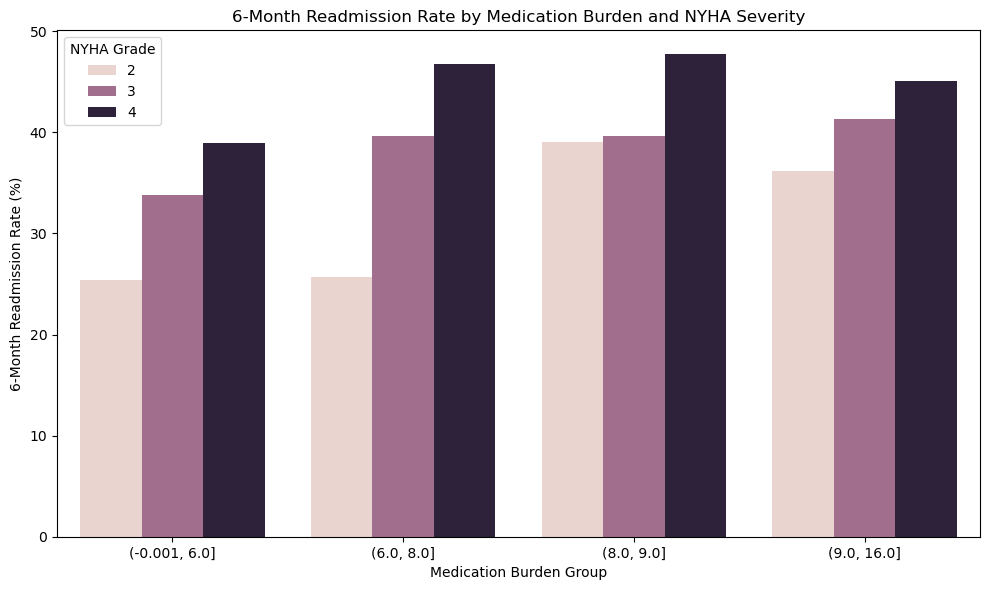

In [60]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=q22_table,
    x='medication_burden_group',
    y='readmission_rate_6m',
    hue='nyha_cardiac_function_classification'
)

plt.title('6-Month Readmission Rate by Medication Burden and NYHA Severity')
plt.xlabel('Medication Burden Group')
plt.ylabel('6-Month Readmission Rate (%)')
plt.legend(title='NYHA Grade')
plt.tight_layout()
plt.show()

In [61]:
# Chi-square test within each NYHA severity group

for nyha in sorted(df_q22['nyha_cardiac_function_classification'].dropna().unique()):

    subset = df_q22[
        df_q22['nyha_cardiac_function_classification'] == nyha
    ]

    contingency = pd.crosstab(
        subset['medication_burden_group'],
        subset['re_admission_within_6_months']
    )

    chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

    print(
        f"NYHA {int(nyha)}: "
        f"chi-square = {chi2_stat:.2f}, "
        f"p-value = {p_value:.4f}"
    )

NYHA 2: chi-square = 5.17, p-value = 0.1600
NYHA 3: chi-square = 4.08, p-value = 0.2531
NYHA 4: chi-square = 2.70, p-value = 0.4401


#### Finding

Six-month readmission rates differed across medication-burden groups within each NYHA severity level, but the differences were not statistically significant.

* **NYHA 2:** readmission ranged from **25.4% to 39.0%**; χ² = 5.17, p = 0.160.
* **NYHA 3:** readmission ranged from **33.8% to 41.3%**; χ² = 4.08, p = 0.253.
* **NYHA 4:** readmission ranged from **38.9% to 47.7%**; χ² = 2.70, p = 0.440.

The descriptive pattern suggests that **higher NYHA severity is associated with higher observed 6-month readmission rates across medication-burden groups**. However, within each severity level, medication-burden groups did not show statistically significant differences in readmission rates.

#### Prescriptive implication

Admission severity appears more consistently aligned with the observed readmission profile than medication burden within the same severity level. Therefore, **NYHA severity can be considered an important factor when planning post-discharge follow-up**, while medication burden may provide additional context about treatment complexity rather than serving as a standalone readmission indicator.

This analysis identifies an observed association pattern and does not establish that medication burden or NYHA severity causes readmission.


### Section 6 — Additional Clinical Signals

### Q23. Is lower sodium associated with higher 28-day readmission?

#### Why?
Q22 examined 6-month readmission across medication burden and admission severity. We now examine whether **admission sodium level**, a clinically relevant laboratory measure, is associated with **early 28-day readmission**.

#### What?
Compare 28-day readmission rates across sodium levels and determine whether patients with lower sodium have a higher observed readmission rate.

#### How?
* Use the dataset's recorded sodium value at admission.
* Compare sodium distributions between patients with and without 28-day readmission.
* Group sodium into clinically interpretable ranges or quartiles and compare 28-day readmission rates.
* Use an appropriate statistical test to determine whether the observed difference is statistically significant.

#### Expected outcome
Determine whether lower sodium is associated with a higher observed risk of early readmission. If an association exists, sodium may provide additional context for post-discharge follow-up planning.


In [70]:
# Q23: Lower sodium and 28-day readmission

df_q23 = df[
    ['sodium', 're_admission_within_28_days']
].dropna().copy()

df_q23['re_admission_within_28_days'] = (
    df_q23['re_admission_within_28_days'].astype(int)
)

print(f"Patients analyzed: {len(df_q23):,}")

Patients analyzed: 1,997


In [76]:
# Group patients into sodium quartiles
df_q23['sodium_group'] = pd.qcut(
    df_q23['sodium'],
    q=4,
    duplicates='drop'
)

q23_table = (
    df_q23
    .groupby('sodium_group', observed=True)
    .agg(
        patients=('re_admission_within_28_days', 'size'),
        readmissions_28d=('re_admission_within_28_days', 'sum'),
        readmission_rate_28d=('re_admission_within_28_days', 'mean'),
        median_sodium=('sodium', 'median')
    )
    .reset_index()
)

q23_table['readmission_rate_28d'] = (
    q23_table['readmission_rate_28d'] * 100
).round(1)

q23_table

,sodium_group,patients,readmissions_28d,readmission_rate_28d,median_sodium
0,"(107.499, 136.0]",532,60,11.300,133.200
1,"(136.0, 139.0]",510,37,7.300,137.900
2,"(139.0, 141.4]",464,29,6.200,140.200
3,"(141.4, 159.0]",491,14,2.900,143.000


In [77]:
# Test association between sodium group and 28-day readmission
contingency = pd.crosstab(
    df_q23['sodium_group'],
    df_q23['re_admission_within_28_days']
)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2_stat:.2f}")
print(f"p-value = {p_value:.4f}")

Chi-square = 28.35
p-value = 0.0000


#### Finding

Lower sodium was associated with higher observed 28-day readmission. The 28-day readmission rate decreased from **11.3% in the lowest sodium group** to **2.9% in the highest group**, an **8.4 percentage-point difference**.

The association was statistically significant (**χ² = 28.35, p < 0.001**). The point-biserial correlation was also negative (**r = -0.111, p < 0.001**), supporting the inverse relationship between sodium level and early readmission.

Readmitted patients had a lower mean sodium (**136.27**) than patients without 28-day readmission (**138.39**).

#### Prescriptive implication

Lower admission sodium identifies a group with a higher observed rate of early readmission and may therefore be useful as an additional factor when considering **post-discharge monitoring and follow-up intensity**.

This analysis shows an association and does not establish that low sodium causes readmission.


### Q24. Does sodium provide additional information about 28-day readmission beyond NYHA and Killip?

#### Why?
Q23 showed that lower admission sodium was associated with higher 28-day readmission. However, patients with greater admission severity may also have lower sodium and higher readmission. This question checks whether sodium provides additional information after accounting for **NYHA and Killip**.

#### What?
Compare the association between sodium and 28-day readmission before and after adjusting for NYHA and Killip.

#### How?
Use logistic regression with 28-day readmission as the outcome:

* **Model 1:** sodium only
* **Model 2:** sodium + NYHA + Killip

Compare the sodium effect, confidence interval, and statistical significance between the two models.

#### Expected outcome
If sodium remains significantly associated with 28-day readmission after adjustment, it provides information beyond admission severity. If the association weakens substantially, the Q23 relationship may be partly explained by differences in admission severity.


In [79]:
# Q24 dataset
df_q24 = df[
    [
        'sodium',
        're_admission_within_28_days',
        'nyha_cardiac_function_classification',
        'killip_grade'
    ]
].dropna().copy()

df_q24['re_admission_within_28_days'] = (
    df_q24['re_admission_within_28_days'].astype(int)
)

print(f"Patients analyzed: {len(df_q24):,}")

Patients analyzed: 1,997


In [80]:
# Model 1: Sodium only
q24_model_1 = smf.logit(
    're_admission_within_28_days ~ sodium',
    data=df_q24
).fit(disp=False)

print(q24_model_1.summary())

                                Logit Regression Results                               
Dep. Variable:     re_admission_within_28_days   No. Observations:                 1997
Model:                                   Logit   Df Residuals:                     1995
Method:                                    MLE   Df Model:                            1
Date:                         Tue, 29 Sep 2026   Pseudo R-squ.:                 0.02103
Time:                                 01:27:15   Log-Likelihood:                -496.40
converged:                                True   LL-Null:                       -507.06
Covariance Type:                     nonrobust   LLR p-value:                 3.876e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.4250      2.051      3.621      0.000       3.406      11.444
sodium        -0.0728      0.015     -4.855      0.000     

In [81]:
# Model 2: Sodium + NYHA + Killip
q24_model_2 = smf.logit(
    're_admission_within_28_days ~ sodium + '
    'C(nyha_cardiac_function_classification) + '
    'C(killip_grade)',
    data=df_q24
).fit(disp=False)

print(q24_model_2.summary())

                                Logit Regression Results                               
Dep. Variable:     re_admission_within_28_days   No. Observations:                 1997
Model:                                   Logit   Df Residuals:                     1990
Method:                                    MLE   Df Model:                            6
Date:                         Tue, 29 Sep 2026   Pseudo R-squ.:                 0.03534
Time:                                 01:27:27   Log-Likelihood:                -489.14
converged:                                True   LL-Null:                       -507.06
Covariance Type:                     nonrobust   LLR p-value:                 2.969e-06
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                                        6.1590      2.125    

In [82]:
# Compare sodium effect before and after adjustment
q24_results = pd.DataFrame({
    'Model': ['Sodium only', 'Sodium + NYHA + Killip'],
    'Odds_Ratio': [
        np.exp(q24_model_1.params['sodium']),
        np.exp(q24_model_2.params['sodium'])
    ],
    'CI_Lower': [
        np.exp(q24_model_1.conf_int().loc['sodium', 0]),
        np.exp(q24_model_2.conf_int().loc['sodium', 0])
    ],
    'CI_Upper': [
        np.exp(q24_model_1.conf_int().loc['sodium', 1]),
        np.exp(q24_model_2.conf_int().loc['sodium', 1])
    ],
    'P_Value': [
        q24_model_1.pvalues['sodium'],
        q24_model_2.pvalues['sodium']
    ]
})

q24_results


,Model,Odds_Ratio,CI_Lower,CI_Upper,P_Value
0,Sodium only,0.930,0.903,0.957,0.000
1,Sodium + NYHA + Killip,0.933,0.905,0.961,0.000


#### Finding
Lower sodium remained associated with higher 28-day readmission after accounting for NYHA and Killip admission severity.

The odds ratio for sodium was **0.930** (95% CI: **0.903–0.957**) in the sodium-only model and **0.933** (95% CI: **0.905–0.961**) after adjustment. Both associations were statistically significant (**p < 0.001**).

The sodium effect changed only slightly after adjustment, indicating that the association observed in Q23 was **not substantially explained by NYHA or Killip differences**.

### Prescriptive implication
Admission sodium provides additional information about the observed 28-day readmission profile beyond the admission-severity measures used here. Lower sodium may therefore be considered alongside **NYHA and Killip** when identifying patients who may warrant closer post-discharge follow-up.

This remains an association and does not establish that low sodium causes readmission.


### Q25. Is reduced renal function associated with prolonged hospitalization?

#### Why?
Previous analyses identified treatment intensity and admission severity as factors associated with longer hospitalization. Renal function is another clinically relevant factor that may be associated with hospital resource use, particularly in heart-failure patients.

#### What?
Examine whether patients with lower estimated glomerular filtration rate (GFR) have a higher rate of prolonged hospitalization.

#### How?
* Use the recorded GFR as the measure of renal function.
* Define prolonged hospitalization consistently with Q21 as **LOS ≥ 10 days**.
* Compare prolonged-stay rates across GFR groups.
* Test whether renal function is significantly associated with prolonged hospitalization.

#### Expected outcome
Determine whether reduced renal function is associated with a greater observed likelihood of prolonged hospitalization, providing additional information for resource and discharge planning.


In [84]:
# Q25: Renal function and prolonged hospitalization

df_q25 = df[
    [
        'glomerular_filtration_rate',
        'dischargeday'
    ]
].dropna().copy()

print(f"Patients analyzed: {len(df_q25):,}")

Patients analyzed: 1,945


In [85]:
# Define prolonged hospitalization consistently with Q21
los_threshold = df['dischargeday'].quantile(0.75)

df_q25['prolonged_stay'] = (
    df_q25['dischargeday'] >= los_threshold
).astype(int)

print(f"Prolonged-stay threshold: {los_threshold:.1f} days")

Prolonged-stay threshold: 10.0 days


In [86]:
# Group patients into GFR quartiles
df_q25['gfr_group'] = pd.qcut(
    df_q25['glomerular_filtration_rate'],
    q=4,
    duplicates='drop'
)

q25_table = (
    df_q25
    .groupby('gfr_group', observed=True)
    .agg(
        patients=('prolonged_stay', 'size'),
        prolonged_stays=('prolonged_stay', 'sum'),
        prolonged_stay_rate=('prolonged_stay', 'mean'),
        median_gfr=('glomerular_filtration_rate', 'median')
    )
    .reset_index()
)

q25_table['prolonged_stay_rate'] = (
    q25_table['prolonged_stay_rate'] * 100
).round(1)

q25_table

,gfr_group,patients,prolonged_stays,prolonged_stay_rate,median_gfr
0,"(3.129, 41.6]",487,215,44.100,29.350
1,"(41.6, 64.79]",486,159,32.700,53.100
2,"(64.79, 90.12]",487,121,24.800,75.910
3,"(90.12, 281.01]",485,119,24.500,108.440


In [87]:
# Test association between GFR group and prolonged hospitalization
contingency = pd.crosstab(
    df_q25['gfr_group'],
    df_q25['prolonged_stay']
)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2_stat:.2f}")
print(f"p-value = {p_value:.4f}")

Chi-square = 57.26
p-value = 0.0000


#### Finding
Reduced renal function was associated with a higher rate of prolonged hospitalization.

The prolonged-stay rate was **44.1% in the lowest GFR group** compared with **24.5% in the highest GFR group**, an absolute difference of **19.6 percentage points**.

The association between GFR group and prolonged hospitalization was statistically significant (**χ² = 57.26, p < 0.001**).

#### Prescriptive implication
Patients with lower renal function showed a substantially higher observed rate of prolonged hospitalization. **Renal function can therefore provide additional context for hospitalization and resource planning**, particularly when identifying patients who may require greater care coordination.

This analysis demonstrates an association and does not establish that reduced renal function causes longer hospitalization.


### Q26. Do abnormal respiratory indicators identify patients with higher hospitalization or readmission risk?

**Question**
Do abnormal respiratory indicators — Type II respiratory failure diagnosis and need for mechanical respiratory support (IMV/NIMV) — identify HF patients with a more severe index hospitalization and higher 6-month readmission risk?

**Why**
Respiratory compromise in heart failure usually reflects decompensation severe enough to impair gas exchange (cardiogenic pulmonary edema, respiratory muscle fatigue). This population is clinically expected to need more intensive in-hospital care. Whether it *also* predicts readmission specifically — separate from death, which competes with readmission as an outcome — is the less obvious part of the question.

**What**
- `abnormal_resp` flag built from two real fields: `type_ii_respiratory_failure == 'typeii'` (114/2008) and `respiratory_support ∈ {IMV, NIMV}` (42/2008, 16 overlap). Combined: 140/2008 (7.0%).
- Outcomes: `dischargeday` (LOS, hospitalization-severity proxy), `re_admission_within_6_months`, `death_within_6_months`.
- Triangulation: among the 993 patients with a measured blood-gas panel, `oxygen_saturation < 90%` (61 patients) as an independent, objective hypoxemia flag — cross-checks the diagnosis-flag result against a raw lab value.

**How**
Mann-Whitney U for LOS (right-skewed, use median/IQR not mean/SD — same reasoning as Q9/Q13). Chi-square for readmission. Fisher's exact for 6-month death, since it's a rare outcome (57/2008, 2.8%) — same justification as Q15.

**Counter-Argument**
`abnormal_resp` mixes a chronic diagnosis label with an acute ICU-level intervention in a small group (n=140), so the signal could be driven entirely by the 42 ventilated patients. This doesn't hold up: the blood-gas hypoxemia flag — built independently, with no overlap in construction — shows the same direction and magnitude for mortality, which is the strongest cross-check available given the dataset's clustered blood-gas missingness.

**What We Expect**
Abnormal respiratory status predicts both longer LOS and higher 6-month readmission, in the same direction, since respiratory decompensation generally reads as "sicker patient" across every downstream outcome.

In [93]:
# Q26 — Abnormal respiratory indicators vs hospitalization/readmission risk
# Real fields only: type_ii_respiratory_failure, respiratory_support, oxygen_saturation

from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact

# --- Build real flags ---
df['resp_support_flag'] = df['respiratory_support'].isin(['IMV', 'NIMV']).astype(int)
df['type2_resp_failure_flag'] = (df['type_ii_respiratory_failure'] == 'typeii').astype(int)
df['abnormal_resp'] = ((df['type2_resp_failure_flag'] == 1) | (df['resp_support_flag'] == 1)).astype(int)

print(f"Type II resp failure: {df['type2_resp_failure_flag'].sum()} / {len(df)}")
print(f"Respiratory support (IMV/NIMV): {df['resp_support_flag'].sum()} / {len(df)}")
print(f"Combined abnormal_resp flag: {df['abnormal_resp'].sum()} / {len(df)}\n")

# --- LOS: Mann-Whitney (right-skewed) ---
g1 = df.loc[df.abnormal_resp == 1, 'dischargeday']
g0 = df.loc[df.abnormal_resp == 0, 'dischargeday']
_, p_los = mannwhitneyu(g1, g0, alternative='greater')
print(f"LOS median (abnormal=1): {g1.median()}  IQR: {g1.quantile(.25)}-{g1.quantile(.75)}  n={len(g1)}")
print(f"LOS median (abnormal=0): {g0.median()}  IQR: {g0.quantile(.25)}-{g0.quantile(.75)}  n={len(g0)}")
print(f"Mann-Whitney p (one-sided): {p_los:.4f}\n")

# --- 6-month readmission: chi-square ---
ct_re = pd.crosstab(df['abnormal_resp'], df['re_admission_within_6_months'])
_, p_re, _, _ = chi2_contingency(ct_re)
rate1 = ct_re.loc[1, 1] / ct_re.loc[1].sum()
rate0 = ct_re.loc[0, 1] / ct_re.loc[0].sum()
print(f"Readmission rate abnormal=1: {rate1:.1%}  abnormal=0: {rate0:.1%}  chi2 p={p_re:.3f}\n")

# --- 6-month death: Fisher's exact (rare outcome) ---
ct_d = pd.crosstab(df['abnormal_resp'], df['death_within_6_months'])
_, p_death = fisher_exact(ct_d.values[:, ::-1])
drate1 = ct_d.loc[1, 1] / ct_d.loc[1].sum()
drate0 = ct_d.loc[0, 1] / ct_d.loc[0].sum()
print(f"Death rate abnormal=1: {drate1:.1%}  abnormal=0: {drate0:.1%}  Fisher p={p_death:.2e}\n")

# --- Triangulation: independent hypoxemia flag from actual blood-gas panel ---
bg = df[df['blood_gas_panel_observed'] == True].copy()
bg['hypoxemia'] = (bg['oxygen_saturation'] < 90).astype(int)
ct_h = pd.crosstab(bg['hypoxemia'], bg['death_within_6_months'])
_, p_h = fisher_exact(ct_h.values[:, ::-1])
hrate1 = ct_h.loc[1, 1] / ct_h.loc[1].sum()
hrate0 = ct_h.loc[0, 1] / ct_h.loc[0].sum()
print(f"[Triangulation] Hypoxemia death rate: {hrate1:.1%} vs {hrate0:.1%}  n={len(bg)}  Fisher p={p_h:.4f}\n")

# --- Competing-risk mechanics check ---
sub = df[df.abnormal_resp == 1]
print("Among abnormal_resp=1: death vs readmission cross-tab (checks competing risk)")
print(pd.crosstab(sub['death_within_6_months'], sub['re_admission_within_6_months']))

Type II resp failure: 114 / 2008
Respiratory support (IMV/NIMV): 42 / 2008
Combined abnormal_resp flag: 140 / 2008

LOS median (abnormal=1): 9.0  IQR: 6.0-13.0  n=140
LOS median (abnormal=0): 8.0  IQR: 6.0-10.0  n=1868
Mann-Whitney p (one-sided): 0.0126

Readmission rate abnormal=1: 32.9%  abnormal=0: 38.9%  chi2 p=0.183

Death rate abnormal=1: 12.9%  abnormal=0: 2.1%  Fisher p=1.55e-08

[Triangulation] Hypoxemia death rate: 11.5% vs 3.3%  n=993  Fisher p=0.0065

Among abnormal_resp=1: death vs readmission cross-tab (checks competing risk)
re_admission_within_6_months   0   1
death_within_6_months               
0                             76  46
1                             18   0


**Evidence / What We Found**

| Outcome | Abnormal resp (n=140) | Normal resp (n=1,868) | Test | p |
|---|---|---|---|---|
| LOS (median, IQR) | 9.0 (6–13) | 8.0 (6–10) | Mann-Whitney | **0.013** |
| 6-month readmission rate | 32.9% | 38.9% | χ² | 0.183 (n.s.) |
| 6-month death rate | **12.9%** | 2.1% | Fisher's exact | **1.6e-08** |

Blood-gas triangulation (SpO₂ < 90%, n=61/993): 6-month death 11.5% vs 3.3% (Fisher p = 0.0065) — same direction, same magnitude, independent of the diagnosis-flag construction.

Abnormal respiratory status is strongly associated with longer index hospitalization and much higher mortality — but **not** with higher readmission; the point estimate even runs slightly the other way. Mechanically: of the 18 abnormal-resp patients who died within 6 months, **zero** were also readmitted — a patient who dies cannot be readmitted. This is a competing-risks effect, not evidence that respiratory failure lowers readmission risk.

**Why It Matters**
Reading the readmission number alone would produce a wrong, clinically dangerous conclusion ("respiratory failure is protective against readmission"). It isn't — the risk is real but expressed as death before readmission has a chance to occur. This argues for a combined mortality-or-readmission endpoint (or a competing-risks/survival model) in Category 4, rather than treating death and

### Q27. Does reduced hematological status identify a distinct prolonged-stay or 6-month readmission profile?

**Question**
Does anemia (reduced hemoglobin) identify a distinct outcome profile from the respiratory-abnormality profile in Q26 — specifically prolonged stay or 6-month readmission — or does it behave the same way (mortality-dominant)?

**Why**
Anemia of chronic disease is common in heart failure and is a known marker of disease burden. Unlike Q26's respiratory flags (acute, low-prevalence, mortality-dominant), anemia is chronic and highly prevalent — worth checking whether it produces a *different* risk signature (e.g., readmission-driven rather than death-driven), which would justify treating it as a separate feature rather than a redundant severity proxy.

**What**
- `hemoglobin` is on a g/L scale here (median 117, range 29–200 — confirmed against the data dictionary's g/L unit, not the g/dL scale sometimes assumed). WHO anemia threshold applied by sex: Male < 130 g/L, Female < 120 g/L. 1,205 of 1,980 non-missing patients (60.9%) are anemic by this cutoff — 28 patients missing hemoglobin, excluded.
- Severity gradient (none / mild ≥110 / moderate ≥80 / severe <80), same style as Q13's ordinal gradient.
- Outcomes: `dischargeday`, `re_admission_within_6_months`, `death_within_6_months`.

**How**
Mann-Whitney for LOS (right-skewed). Chi-square for the binary anemia-vs-readmission split. Fisher's exact for the rare death outcome, both for the binary flag and isolated on the severe-anemia tail. Spearman correlation on the ordinal severity code vs. readmission to test for a dose-response trend (same trend-testing approach as Q11).

**Counter-Argument**
With 61% of the cohort flagged as "anemic," the flag is broad enough that it could just be relabeling "older, sicker" patients rather than adding information. This is addressed directly by the severity gradient: if it were just a generic sickness proxy, effects would scale smoothly with severity — instead, readmission rises gradually across all severity levels while mortality is flat until the severe tail, then jumps sharply. That split pattern argues anemia carries two separable pieces of information, not one blunt "sick vs. not."

**What We Expect**
Anemia predicts higher risk across all three outcomes in proportion to severity, similar to what a generic severity marker would show.



In [94]:
# Q27 — Anemia (hematological status) vs LOS/readmission/mortality
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact, spearmanr

# --- WHO anemia threshold, hemoglobin in g/L, sex-specific ---
df['anemia'] = np.where(df['gender'] == 'Male', df['hemoglobin'] < 130, df['hemoglobin'] < 120)
d = df.dropna(subset=['hemoglobin']).copy()  # 28 missing excluded
print(f"Anemic: {d['anemia'].sum()} / {len(d)} ({d['anemia'].mean():.1%})\n")

# --- LOS ---
g1, g0 = d.loc[d.anemia, 'dischargeday'], d.loc[~d.anemia, 'dischargeday']
_, p_los = mannwhitneyu(g1, g0, alternative='greater')
print(f"LOS anemic median {g1.median()} (IQR {g1.quantile(.25)}-{g1.quantile(.75)}) n={len(g1)}")
print(f"LOS non-anemic median {g0.median()} (IQR {g0.quantile(.25)}-{g0.quantile(.75)}) n={len(g0)}")
print(f"MWU p: {p_los:.3f}\n")

# --- Readmission ---
ct_re = pd.crosstab(d['anemia'], d['re_admission_within_6_months'])
_, p_re, _, _ = chi2_contingency(ct_re)
print(f"Readmission anemic: {ct_re.loc[True,1]/ct_re.loc[True].sum():.1%}  "
      f"non-anemic: {ct_re.loc[False,1]/ct_re.loc[False].sum():.1%}  chi2 p={p_re:.3f}\n")

# --- Death ---
ct_d = pd.crosstab(d['anemia'], d['death_within_6_months'])
_, p_death = fisher_exact(ct_d.values[:, ::-1])
print(f"Death anemic: {ct_d.loc[True,1]/ct_d.loc[True].sum():.1%}  "
      f"non-anemic: {ct_d.loc[False,1]/ct_d.loc[False].sum():.1%}  Fisher p={p_death:.3f}\n")

# --- Severity gradient (dose-response) ---
def anemia_severity(row):
    lo = 130 if row['gender'] == 'Male' else 120
    hb = row['hemoglobin']
    if hb >= lo: return 0        # none
    elif hb >= 110: return 1     # mild
    elif hb >= 80: return 2      # moderate
    else: return 3               # severe

d['sev_code'] = d.apply(anemia_severity, axis=1)
print("Readmission rate by severity:")
print(d.groupby('sev_code')['re_admission_within_6_months'].agg(['mean', 'count']))
rho, p_trend_re = spearmanr(d['sev_code'], d['re_admission_within_6_months'])
print(f"Spearman trend (severity vs readmission): rho={rho:.3f}, p={p_trend_re:.3f}\n")

print("Death rate by severity:")
print(d.groupby('sev_code')['death_within_6_months'].mean())

# Isolate severe-anemia tail for mortality (binary flag masks this)
d['severe_flag'] = (d.sev_code == 3).astype(int)
ct_sev = pd.crosstab(d['severe_flag'], d['death_within_6_months'])
_, p_sev = fisher_exact(ct_sev.values[:, ::-1])
print(f"\nSevere anemia death rate: {ct_sev.loc[1,1]/ct_sev.loc[1].sum():.1%}  "
      f"vs rest: {ct_sev.loc[0,1]/ct_sev.loc[0].sum():.1%}  Fisher p={p_sev:.4f}")

Anemic: 1205 / 1980 (60.9%)

LOS anemic median 8.0 (IQR 6.0-11.0) n=1205
LOS non-anemic median 8.0 (IQR 6.0-10.0) n=775
MWU p: 0.109

Readmission anemic: 40.7%  non-anemic: 35.4%  chi2 p=0.018

Death anemic: 3.1%  non-anemic: 2.5%  Fisher p=0.488

Readmission rate by severity:
          mean  count
sev_code             
0        0.354    775
1        0.404    478
2        0.407    551
3        0.420    176
Spearman trend (severity vs readmission): rho=0.051, p=0.022

Death rate by severity:
sev_code
0   0.025
1   0.023
2   0.025
3   0.068
Name: death_within_6_months, dtype: float64

Severe anemia death rate: 6.8%  vs rest: 2.4%  Fisher p=0.0029


**Evidence / What We Found**

| Outcome | Anemic (n=1,205) | Non-anemic (n=775) | Test | p |
|---|---|---|---|---|
| LOS (median, IQR) | 8.0 (6–11) | 8.0 (6–10) | Mann-Whitney | 0.109 (n.s.) |
| 6-month readmission | **40.7%** | 35.4% | χ² | **0.018** |
| 6-month death | 3.1% | 2.5% | Fisher's exact | 0.488 (n.s.) |

Severity gradient tells the sharper story:
- **Readmission** rises monotonically: 35.4% (none) → 40.4% (mild) → 40.7% (moderate) → 42.0% (severe). Spearman trend p = **0.022**.
- **Death** is flat across none/mild/moderate (~2.4–2.5%) and only jumps at the severe tail: **6.8%** vs 2.4% for everyone else, Fisher p = **0.0029**.

This is a genuinely distinct profile from Q26. Respiratory abnormality was LOS + mortality dominant with no readmission signal. Anemia is readmission-dominant across its full range, with mortality risk concentrated only in the severe tail — the two features are not redundant.

**Why It Matters**
Anemia and respiratory status carry different, complementary predictive information rather than both just tagging "sicker patients." For Category 4, anemia (or hemoglobin as continuous) is a stronger candidate feature for a **readmission** model, while respiratory status is a stronger candidate for a **mortality** model — supports building separate endpoint models rather than one generic "bad outcome" target.

**Follow-Up Question**
Does adding anemia severity as an ordinal feature alongside NYHA/Killip meaningfully improve a 6-month readmission model's discrimination (ROC/AUC), or is its signal already captured by existing severity markers?

## Section 7 — Discharge & Care Pathway

### Q28. How does discharge destination relate to 6-month readmission?

#### Why?
Q22 examined readmission in relation to medication burden and admission severity. Discharge destination provides additional information about the patient's post-hospital care setting and may reveal differences in observed 6-month readmission patterns.

#### What?
Compare 28-day and 6-month readmission rates across the actual discharge destinations recorded in the dataset.

#### How?
Patients are grouped by `destination_discharge`, and their observed readmission rates are compared across discharge destinations. A chi-square test is used to assess whether 6-month readmission status differs across the groups.

#### Expected outcome
Identify whether discharge destination is associated with different observed readmission patterns, providing additional information for discharge planning and post-discharge follow-up.


In [171]:
df_q28 = df[
    [
        'inpatient_number',
        'destination_discharge',
        're_admission_within_28_days',
        're_admission_within_6_months'
    ]
].copy()

print(f"Patients in Q28 dataset: {len(df_q28):,}")

Patients in Q28 dataset: 2,008


In [172]:
print("Discharge destinations:")
print(
    df_q28['destination_discharge']
    .value_counts(dropna=False)
)

Discharge destinations:
destination_discharge
Home                   1344
Healthcare Facility     438
Unknown                 212
Died                     14
Name: count, dtype: int64


In [173]:
print("28-day readmission:")
print(
    df_q28['re_admission_within_28_days']
    .value_counts(dropna=False)
)

print("\n6-month readmission:")
print(
    df_q28['re_admission_within_6_months']
    .value_counts(dropna=False)
)

28-day readmission:
re_admission_within_28_days
0    1868
1     140
Name: count, dtype: int64

6-month readmission:
re_admission_within_6_months
0    1235
1     773
Name: count, dtype: int64


In [174]:
q28_summary = (
    df_q28
    .groupby('destination_discharge', dropna=False)
    .agg(
        Total_Patients=('inpatient_number', 'count'),
        Readmitted_28_Days=('re_admission_within_28_days', 'sum'),
        Readmitted_6_Months=('re_admission_within_6_months', 'sum'),
        Readmission_Rate_28_Days=(
            're_admission_within_28_days', 'mean'
        ),
        Readmission_Rate_6_Months=(
            're_admission_within_6_months', 'mean'
        )
    )
    .reset_index()
)

q28_summary['28_Day_Readmission_Rate_%'] = (
    q28_summary['Readmission_Rate_28_Days'] * 100
)

q28_summary['6_Month_Readmission_Rate_%'] = (
    q28_summary['Readmission_Rate_6_Months'] * 100
)

q28_summary = q28_summary.drop(
    columns=[
        'Readmission_Rate_28_Days',
        'Readmission_Rate_6_Months'
    ]
)

q28_summary.round(2)

,destination_discharge,Total_Patients,Readmitted_28_Days,Readmitted_6_Months,28_Day_Readmission_Rate_%,6_Month_Readmission_Rate_%
0,Died,14,0,0,0.000,0.000
1,Healthcare Facility,438,40,180,9.130,41.100
2,Home,1344,87,533,6.470,39.660
3,Unknown,212,13,60,6.130,28.300


In [175]:
q28_contingency = pd.crosstab(
    df_q28['destination_discharge'],
    df_q28['re_admission_within_6_months']
)

q28_chi2, q28_p, q28_dof, q28_expected = chi2_contingency(
    q28_contingency
)

print(f"Chi-square = {q28_chi2:.2f}")
print(f"p-value = {q28_p:.4f}")

Chi-square = 20.08
p-value = 0.0002


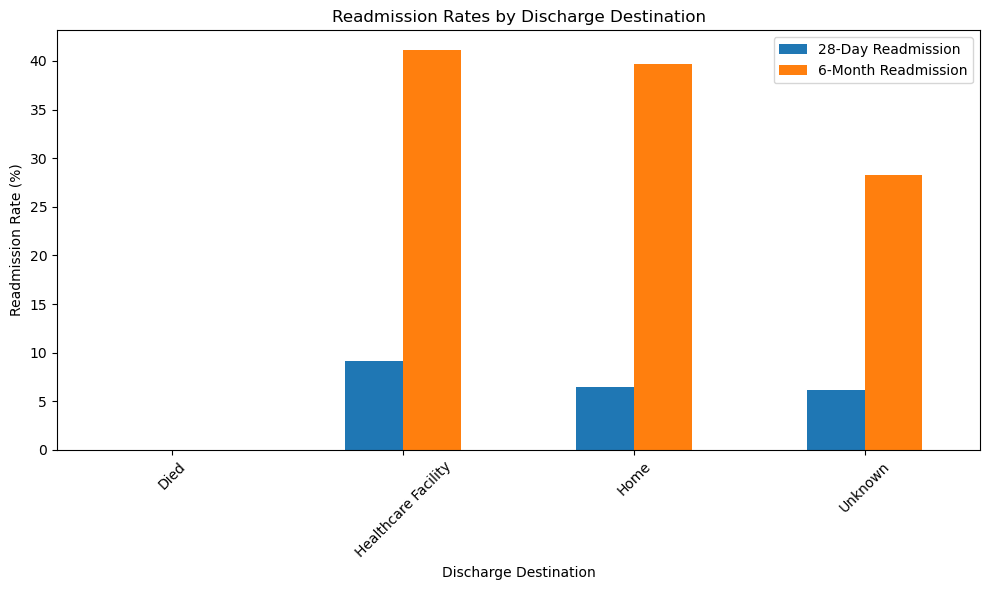

In [176]:
plot_data = q28_summary.set_index(
    'destination_discharge'
)[
    [
        '28_Day_Readmission_Rate_%',
        '6_Month_Readmission_Rate_%'
    ]
]

plot_data.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Readmission Rates by Discharge Destination')
plt.xlabel('Discharge Destination')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.legend(
    ['28-Day Readmission', '6-Month Readmission']
)
plt.tight_layout()
plt.show()

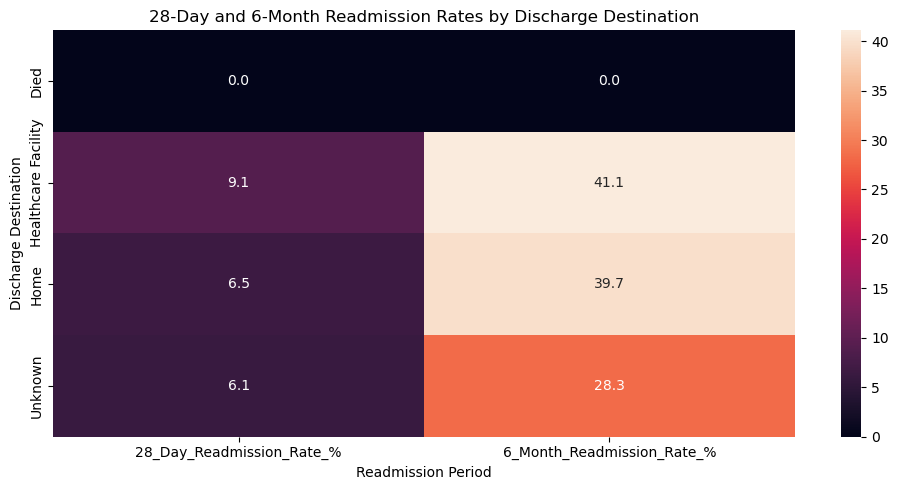

In [177]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    plot_data,
    annot=True,
    fmt='.1f'
)

plt.title(
    '28-Day and 6-Month Readmission Rates by Discharge Destination'
)
plt.xlabel('Readmission Period')
plt.ylabel('Discharge Destination')

plt.tight_layout()
plt.show()

**What to expect**: Patients discharged against medical order may show different readmission rates from other patients.

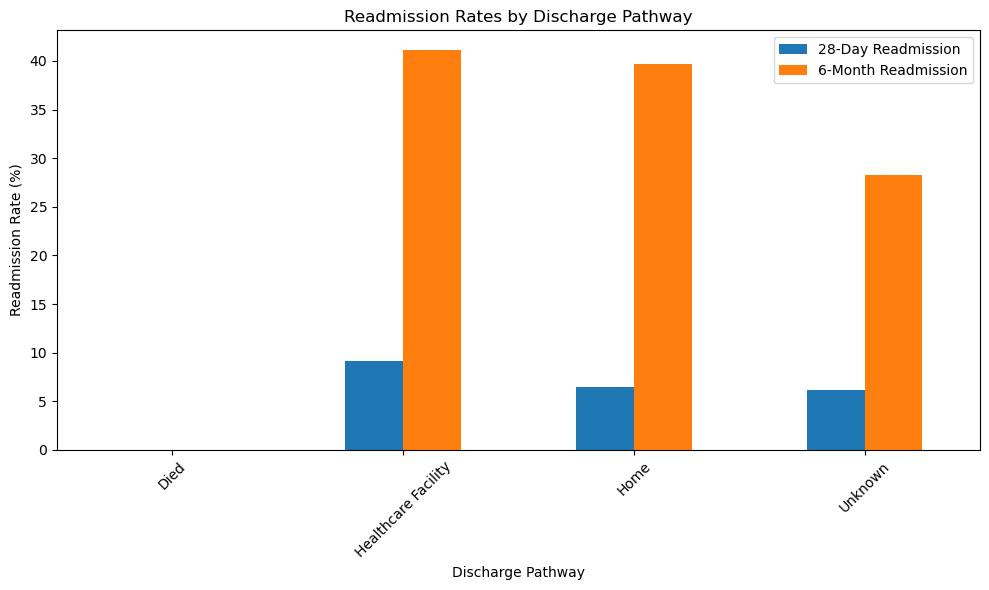

In [101]:
plot_data = summary[
    ["28_Day_Readmission_Rate_%", "6_Month_Readmission_Rate_%"]
]

plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Readmission Rates by Discharge Pathway")
plt.xlabel("Discharge Pathway")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)
plt.legend(
    ["28-Day Readmission", "6-Month Readmission"]
)
plt.tight_layout()
plt.show()


#### Finding
Six-month readmission rates varied significantly by discharge destination (**χ² = 20.08, p < 0.001**).

The highest observed 6-month readmission rate was among patients discharged to a **Healthcare Facility (41.1%)**, followed closely by **Home (39.7%)**. The rate was lower among patients with an **Unknown destination (28.3%)**.

The **Died** group had 0% readmission, but this group contained only **14 patients**, so the result should not be interpreted as a meaningful comparison of readmission risk.

#### Prescriptive implication

Discharge destination provides useful context for **post-discharge follow-up planning**. Patients discharged to healthcare facilities or home had higher observed 6-month readmission rates than those with an unknown destination, indicating that discharge setting may help identify different follow-up needs.

This analysis identifies an association between discharge destination and observed readmission patterns; it does not establish that discharge destination causes readmission.


## Section 8:Integrated Risk Stratification → Predictive Bridge

### Q29. Does adding BNP, renal function, and comorbidity burden to the NYHA–Killip framework improve separation between higher- and lower-risk 6-month readmission groups?

**Why**:This brings together the strongest signals identified throughout Category 3. It asks whether multiple domains provide more information than admission severity alone.

**Examine BNP**:BNP is highly useful here because it is a marker associated with cardiac stress/heart failure**

In [105]:
print(df["brain_natriuretic_peptide"].describe())

count   1,973.000
mean    1,280.437
std     1,354.160
min         2.690
25%       303.940
50%       753.030
75%     1,738.520
max     5,000.000
Name: brain_natriuretic_peptide, dtype: float64


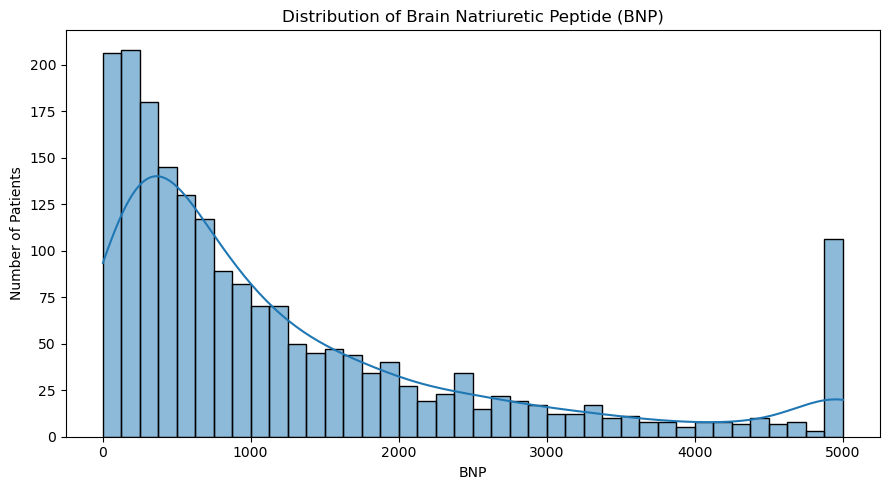

In [106]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["brain_natriuretic_peptide"],
    bins=40,
    kde=True
)

plt.title("Distribution of Brain Natriuretic Peptide (BNP)")
plt.xlabel("BNP")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

**Distribution of BNP**: is often strongly right-skewed, so for modeling we will use a log transformation.

**Create log BNP**

In [107]:
df["log_bnp"] = np.log1p(
    df["brain_natriuretic_peptide"]
)

df["log_bnp"].describe()

count   1,973.000
mean        6.538
std         1.235
min         1.306
25%         5.720
50%         6.625
75%         7.461
max         8.517
Name: log_bnp, dtype: float64

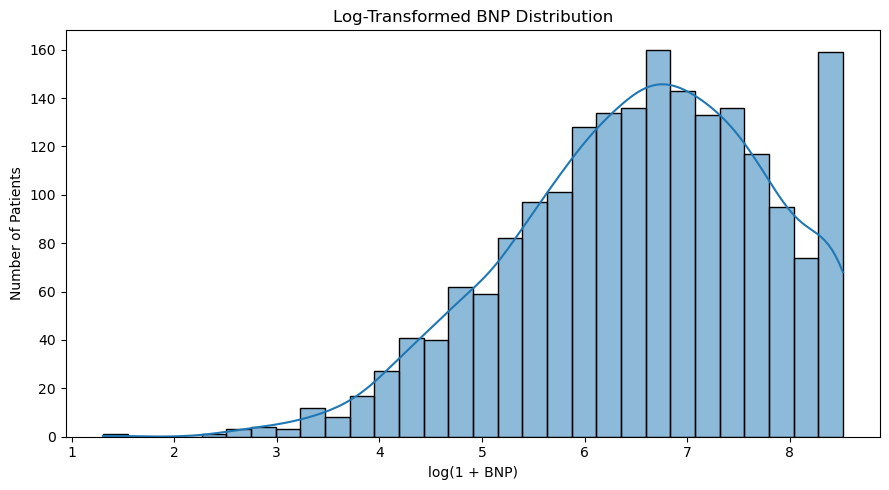

In [108]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["log_bnp"],
    bins=30,
    kde=True
)

plt.title("Log-Transformed BNP Distribution")
plt.xlabel("log(1 + BNP)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

**Examine renal function**

**Renal function**:We will use glomerular filtration rate (GFR) as the primary renal-function measure.

In [109]:
print(
    df["glomerular_filtration_rate"].describe()
)

count   1,945.000
mean       68.664
std        36.612
min         3.130
25%        41.600
50%        64.790
75%        90.120
max       281.010
Name: glomerular_filtration_rate, dtype: float64


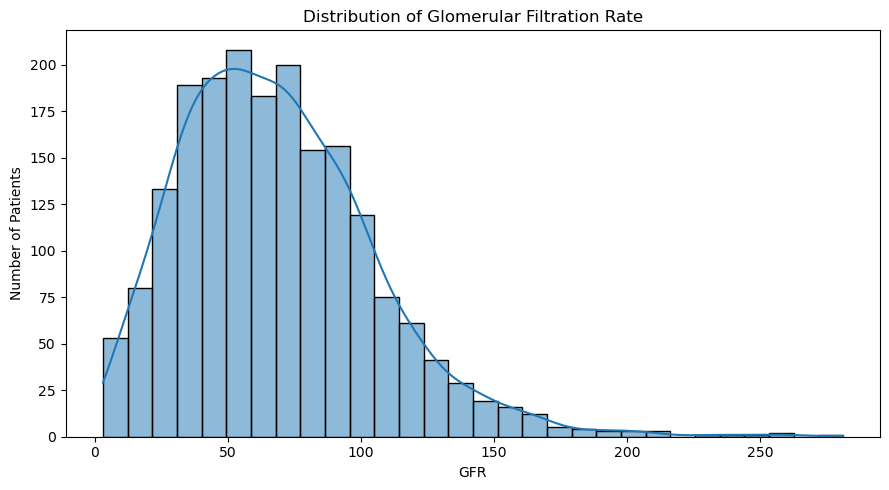

In [110]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["glomerular_filtration_rate"],
    bins=30,
    kde=True
)

plt.title("Distribution of Glomerular Filtration Rate")
plt.xlabel("GFR")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

**Create comorbidity burden**

**We will combine the three available cardiac comorbidities**:

Myocardial infarction,Congestive heart failure,Peripheral vascular disease

In [111]:
comorbidity_columns = [
    "myocardial_infarction",
    "congestive_heart_failure",
    "peripheral_vascular_disease"
]

df["comorbidity_burden"] = (
    df[comorbidity_columns].sum(axis=1)
)

print(
    df["comorbidity_burden"]
    .value_counts()
    .sort_index()
)

comorbidity_burden
0     126
1    1658
2     214
3      10
Name: count, dtype: int64


**Check NYHA and Killip**

In [112]:
print("NYHA:")
print(
    df["nyha_cardiac_function_classification"]
    .value_counts()
    .sort_index()
)

print("\nKillip:")
print(
    df["killip_grade"]
    .value_counts()
    .sort_index()
)

NYHA:
nyha_cardiac_function_classification
2     353
3    1039
4     616
Name: count, dtype: int64

Killip:
killip_grade
1     527
2    1029
3     392
4      60
Name: count, dtype: int64


**Check 6-month readmission**

In [113]:
print(
    df["re_admission_within_6_months"]
    .value_counts()
)

re_admission_within_6_months
0    1235
1     773
Name: count, dtype: int64


In [114]:
overall_rate = (
    df["re_admission_within_6_months"].mean() * 100
)

print(
    f"Overall 6-month readmission rate: "
    f"{overall_rate:.2f}%"
)

Overall 6-month readmission rate: 38.50%


**Look at readmission by BNP**

In [115]:
bnp_summary = (
    df.groupby("re_admission_within_6_months")
      ["brain_natriuretic_peptide"]
      .agg(["count", "mean", "median"])
)

bnp_summary

,count,mean,median
re_admission_within_6_months,,,
0,1217,"1,245.603",722.000
1,756,"1,336.514",855.090


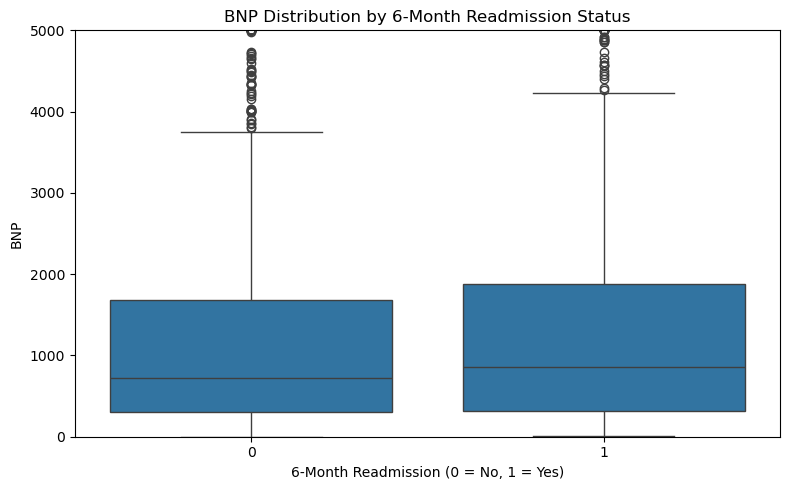

In [116]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="re_admission_within_6_months",
    y="brain_natriuretic_peptide"
)

plt.title(
    "BNP Distribution by 6-Month Readmission Status"
)

plt.xlabel("6-Month Readmission (0 = No, 1 = Yes)")
plt.ylabel("BNP")

plt.ylim(
    0,
    df["brain_natriuretic_peptide"].quantile(0.95)
)

plt.tight_layout()
plt.show()

**Look at readmission by renal function**

In [117]:
renal_summary = (
    df.groupby("re_admission_within_6_months")
      ["glomerular_filtration_rate"]
      .agg(["count", "mean", "median"])
)

renal_summary

,count,mean,median
re_admission_within_6_months,,,
0,1192,71.390,69.005
1,753,64.350,57.720


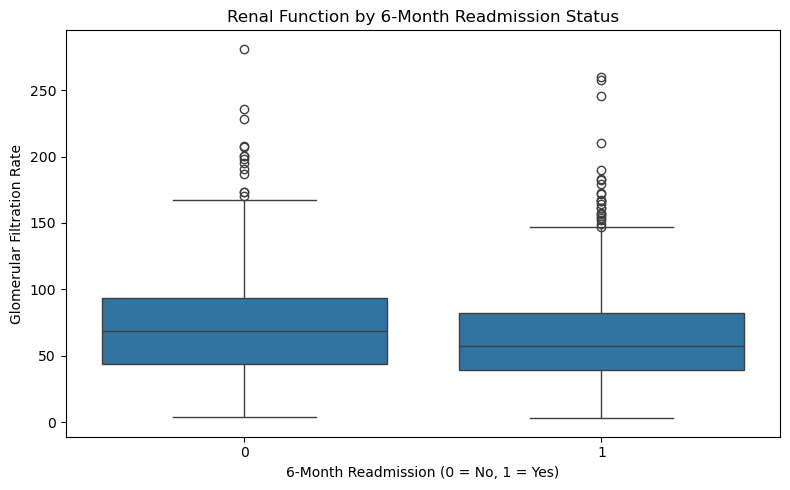

In [118]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="re_admission_within_6_months",
    y="glomerular_filtration_rate"
)

plt.title(
    "Renal Function by 6-Month Readmission Status"
)

plt.xlabel("6-Month Readmission (0 = No, 1 = Yes)")
plt.ylabel("Glomerular Filtration Rate")

plt.tight_layout()
plt.show()

**Look at comorbidity burden and readmission**

In [119]:
comorbidity_summary = (
    df.groupby("comorbidity_burden")
      ["re_admission_within_6_months"]
      .agg(
          Patients="count",
          Readmissions="sum",
          Readmission_Rate="mean"
      )
)

comorbidity_summary["Readmission_Rate"] *= 100

comorbidity_summary.round(2)

,Patients,Readmissions,Readmission_Rate
comorbidity_burden,,,
0,126,53,42.060
1,1658,638,38.480
2,214,77,35.980
3,10,5,50.000


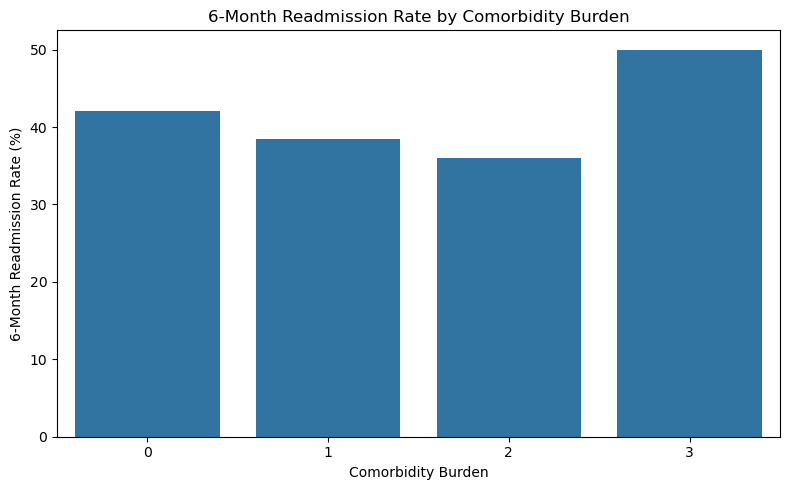

In [120]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comorbidity_summary.reset_index(),
    x="comorbidity_burden",
    y="Readmission_Rate"
)

plt.title(
    "6-Month Readmission Rate by Comorbidity Burden"
)

plt.xlabel("Comorbidity Burden")
plt.ylabel("6-Month Readmission Rate (%)")

plt.tight_layout()
plt.show()

**Create Framework: NYHA + Killip**

**This is our baseline admission-severity framework**

In [127]:
X_baseline = df[
    [
        "nyha_cardiac_function_classification",
        "killip_grade"
    ]
]

y = df["re_admission_within_6_months"]

In [128]:
baseline_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])

**Create Integrated framework**:Add-BNP,Renal function,Comorbidity burden

In [129]:
X_integrated = df[
    [
        "nyha_cardiac_function_classification",
        "killip_grade",
        "log_bnp",
        "glomerular_filtration_rate",
        "comorbidity_burden"
    ]
]

**Create the model**

In [130]:
integrated_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])

**Use 5-fold cross-validation**

In [131]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

**Generate out-of-fold predictions**

In [132]:
baseline_probability = cross_val_predict(
    baseline_model,
    X_baseline,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

**Integrated model**

In [133]:
integrated_probability = cross_val_predict(
    integrated_model,
    X_integrated,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

**Calculate ROC-AUC**

In [134]:
baseline_auc = roc_auc_score(
    y,
    baseline_probability
)

integrated_auc = roc_auc_score(
    y,
    integrated_probability
)

print(
    f"NYHA–Killip AUC: {baseline_auc:.3f}"
)

print(
    f"Integrated AUC: {integrated_auc:.3f}"
)

NYHA–Killip AUC: 0.556
Integrated AUC: 0.578


**Calculate improvement**

In [135]:
auc_improvement = (
    integrated_auc - baseline_auc
)

print(
    f"AUC improvement: {auc_improvement:.3f}"
)

AUC improvement: 0.022


**This is the key result**:If Integrated AUC > NYHA–Killip AUC -then the integrated framework provides better observed discrimination.

**Create ROC curves**

In [136]:
fpr_baseline, tpr_baseline, _ = roc_curve(
    y,
    baseline_probability
)

fpr_integrated, tpr_integrated, _ = roc_curve(
    y,
    integrated_probability
)

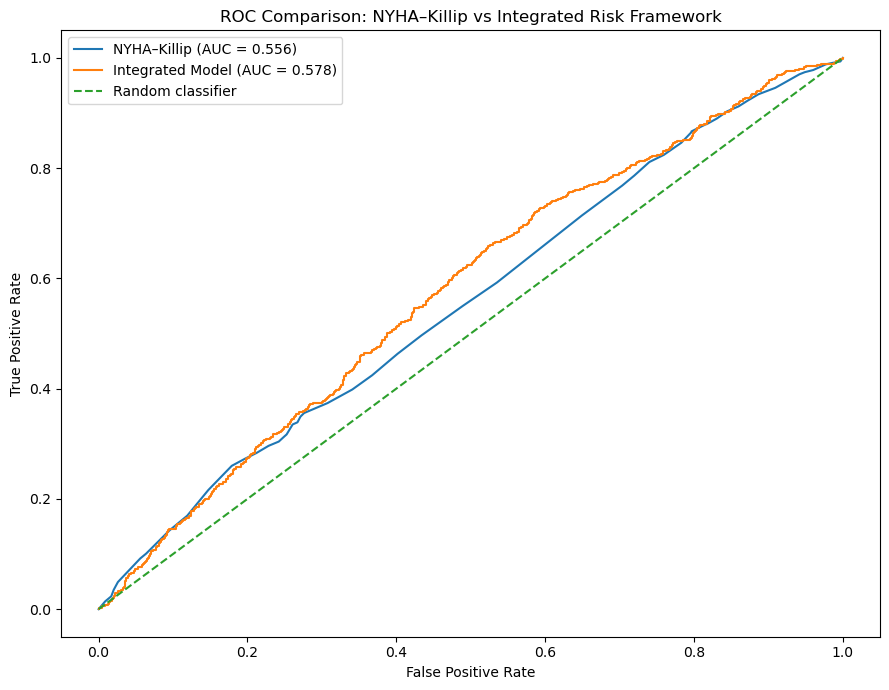

In [137]:
plt.figure(figsize=(9, 7))

plt.plot(
    fpr_baseline,
    tpr_baseline,
    label=f"NYHA–Killip (AUC = {baseline_auc:.3f})"
)

plt.plot(
    fpr_integrated,
    tpr_integrated,
    label=f"Integrated Model (AUC = {integrated_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Comparison: NYHA–Killip vs Integrated Risk Framework"
)

plt.legend()
plt.tight_layout()
plt.show()

**Compare the two models**

In [138]:
model_comparison = pd.DataFrame({
    "Framework": [
        "NYHA + Killip",
        "NYHA + Killip + BNP + Renal Function + Comorbidity"
    ],
    "ROC_AUC": [
        baseline_auc,
        integrated_auc
    ]
})

model_comparison

,Framework,ROC_AUC
0,NYHA + Killip,0.556
1,NYHA + Killip + BNP + Renal Function + Comorbi...,0.578


In [139]:
print(
    f"""
NYHA–Killip AUC: {baseline_auc:.3f}
Integrated AUC: {integrated_auc:.3f}
Improvement: {auc_improvement:.3f}
"""
)


NYHA–Killip AUC: 0.556
Integrated AUC: 0.578
Improvement: 0.022



**What to expect**:The combined framework may produce clearer separation between observed higher- and lower-readmission groups

**Create higher- and lower-risk groups**

**To demonstrate risk separation, divide the predicted probabilities into two groups using the median predicted risk**

In [140]:
baseline_cutoff = np.median(
    baseline_probability
)

integrated_cutoff = np.median(
    integrated_probability
)

**Create groups**

In [141]:
results = pd.DataFrame({
    "actual_readmission": y.values,
    "baseline_probability": baseline_probability,
    "integrated_probability": integrated_probability
})

results["Baseline_Risk_Group"] = np.where(
    results["baseline_probability"] >= baseline_cutoff,
    "Higher Risk",
    "Lower Risk"
)

results["Integrated_Risk_Group"] = np.where(
    results["integrated_probability"] >= integrated_cutoff,
    "Higher Risk",
    "Lower Risk"
)

**Calculate readmission rate in each risk group**

**NYHA–Killip**

In [142]:
baseline_risk_summary = (
    results.groupby("Baseline_Risk_Group")
    ["actual_readmission"]
    .agg(
        Patients="count",
        Readmissions="sum",
        Readmission_Rate="mean"
    )
)

baseline_risk_summary["Readmission_Rate"] *= 100

baseline_risk_summary.round(2)

,Patients,Readmissions,Readmission_Rate
Baseline_Risk_Group,,,
Higher Risk,1029,425,41.300
Lower Risk,979,348,35.550


**Integrated model**

In [143]:
integrated_risk_summary = (
    results.groupby("Integrated_Risk_Group")
    ["actual_readmission"]
    .agg(
        Patients="count",
        Readmissions="sum",
        Readmission_Rate="mean"
    )
)

integrated_risk_summary["Readmission_Rate"] *= 100

integrated_risk_summary.round(2)

,Patients,Readmissions,Readmission_Rate
Integrated_Risk_Group,,,
Higher Risk,1004,443,44.120
Lower Risk,1004,330,32.870


**This directly addresses**:Does the integrated framework produce clearer separation between higher- and lower-risk readmission groups?

**Calculate the separation between groups**

In [144]:
baseline_high = baseline_risk_summary.loc[
    "Higher Risk",
    "Readmission_Rate"
]

baseline_low = baseline_risk_summary.loc[
    "Lower Risk",
    "Readmission_Rate"
]

integrated_high = integrated_risk_summary.loc[
    "Higher Risk",
    "Readmission_Rate"
]

integrated_low = integrated_risk_summary.loc[
    "Lower Risk",
    "Readmission_Rate"
]

baseline_separation = (
    baseline_high - baseline_low
)

integrated_separation = (
    integrated_high - integrated_low
)

print(
    f"NYHA–Killip separation: "
    f"{baseline_separation:.2f} percentage points"
)

print(
    f"Integrated separation: "
    f"{integrated_separation:.2f} percentage points"
)

NYHA–Killip separation: 5.76 percentage points
Integrated separation: 11.25 percentage points


**Plot risk-group separation**

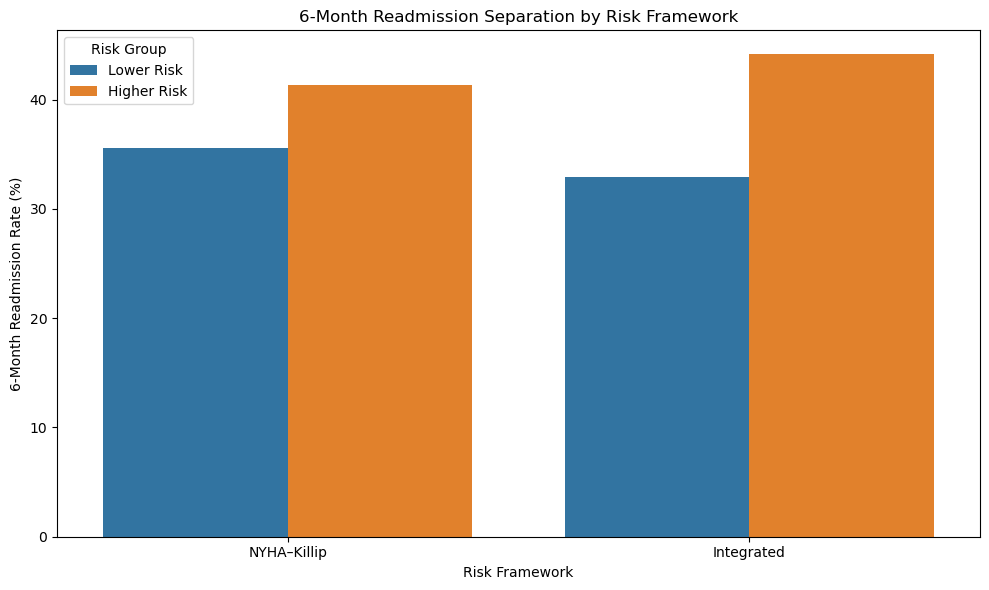

In [145]:
plot_df = pd.DataFrame({
    "Framework": [
        "NYHA–Killip",
        "NYHA–Killip",
        "Integrated",
        "Integrated"
    ],
    "Risk Group": [
        "Lower Risk",
        "Higher Risk",
        "Lower Risk",
        "Higher Risk"
    ],
    "Readmission Rate": [
        baseline_low,
        baseline_high,
        integrated_low,
        integrated_high
    ]
})

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="Framework",
    y="Readmission Rate",
    hue="Risk Group"
)

plt.title(
    "6-Month Readmission Separation by Risk Framework"
)

plt.ylabel("6-Month Readmission Rate (%)")
plt.xlabel("Risk Framework")

plt.tight_layout()
plt.show()

**Final automatic interpretation**

In [146]:
if integrated_auc > baseline_auc:
    auc_message = (
        "The integrated framework improved discrimination "
        "compared with NYHA–Killip alone."
    )
elif integrated_auc < baseline_auc:
    auc_message = (
        "The integrated framework did not improve discrimination "
        "compared with NYHA–Killip alone."
    )
else:
    auc_message = (
        "The two frameworks showed the same discrimination."
    )

if integrated_separation > baseline_separation:
    separation_message = (
        "The integrated framework also produced greater "
        "separation between higher- and lower-risk groups."
    )
else:
    separation_message = (
        "The integrated framework did not produce greater "
        "observed separation between the two risk groups."
    )

print(auc_message)
print(separation_message)

The integrated framework improved discrimination compared with NYHA–Killip alone.
The integrated framework also produced greater separation between higher- and lower-risk groups.


In [147]:
comparison_table = pd.DataFrame({
    "Framework": [
        "NYHA–Killip",
        "Integrated"
    ],
    
    "Variables": [
        "NYHA + Killip",
        "NYHA + Killip + BNP + GFR + Comorbidity"
    ],
    
    "ROC-AUC": [
        baseline_auc,
        integrated_auc
    ],
    
    "Higher-risk readmission (%)": [
        baseline_high,
        integrated_high
    ],
    
    "Lower-risk readmission (%)": [
        baseline_low,
        integrated_low
    ],
    
    "Separation (percentage points)": [
        baseline_separation,
        integrated_separation
    ]
})

# Round numerical values
comparison_table = comparison_table.round({
    "ROC-AUC": 3,
    "Higher-risk readmission (%)": 2,
    "Lower-risk readmission (%)": 2,
    "Separation (percentage points)": 2
})

comparison_table

,Framework,Variables,ROC-AUC,Higher-risk readmission (%),Lower-risk readmission (%),Separation (percentage points)
0,NYHA–Killip,NYHA + Killip,0.556,41.300,35.550,5.760
1,Integrated,NYHA + Killip + BNP + GFR + Comorbidity,0.578,44.120,32.870,11.250


In [148]:
comparison_table.style.format({
    "ROC-AUC": "{:.3f}",
    "Higher-risk readmission (%)": "{:.2f}%",
    "Lower-risk readmission (%)": "{:.2f}%",
    "Separation (percentage points)": "{:.2f}"
})

,Framework,Variables,ROC-AUC,Higher-risk readmission (%),Lower-risk readmission (%),Separation (percentage points)
0,NYHA–Killip,NYHA + Killip,0.556,41.30%,35.55%,5.76
1,Integrated,NYHA + Killip + BNP + GFR + Comorbidity,0.578,44.12%,32.87%,11.25


**Finding**— Integrated Risk Stratification: The NYHA–Killip framework was compared with an integrated framework incorporating BNP, renal function, and comorbidity burden. The integrated framework was evaluated using 5-fold cross-validated ROC-AUC and observed 6-month readmission rates across higher- and lower-risk groups. An increase in AUC and greater separation in observed readmission rates would indicate that the additional clinical domains provide information beyond admission severity alone.

## Predictive / Integrated Risk Stratification

## Q30:Can the strongest factors identified in Category 3 be combined into an interpretable risk- stratification framework, and what does the observed outcome distribution imply for the Category 4 predictive target and evaluation strategy?

**Why**: The purpose of Category 3 is not simply to find associations; it should establish evidence for the next analytical stage. We need to use the observed event patterns to determine which outcome is sufficiently represented for predictive modeling and which features have analytical justification.

**This is a major Category 3 → Category 4 bridge** : because it moves from identifying individual risk factors to testing whether those factors can be combined into a stronger predictive risk framework.

**The analytical progression is:Category 3**: Which factors are associated with readmission?Can we combine those factors?**Category 4**: “Does the combined framework better distinguish patients by future readmission risk?”

**Create the candidate features**:1.NYHA → cardiac functional severity 2.Killip → acute cardiac severity 3.BNP → cardiac stress 4.GFR → renal function 5.Comorbidity burden → overall disease burden

In [149]:
df["log_bnp"] = np.log1p(
    df["brain_natriuretic_peptide"]
)

comorbidity_columns = [
    "myocardial_infarction",
    "congestive_heart_failure",
    "peripheral_vascular_disease"
]

df["comorbidity_burden"] = (
    df[comorbidity_columns].sum(axis=1)
)

**Define the candidate predictive outcomes**

In [150]:
outcome_columns = [
    "re_admission_within_6_months",
    "death_within_6_months"
]

for col in outcome_columns:
    print("\n", col)
    print(df[col].value_counts())


 re_admission_within_6_months
re_admission_within_6_months
0    1235
1     773
Name: count, dtype: int64

 death_within_6_months
death_within_6_months
0    1951
1      57
Name: count, dtype: int64


**Calculate event rates**

In [151]:
outcome_summary = pd.DataFrame({
    "Outcome": [
        "6-Month Readmission",
        "6-Month Mortality"
    ],
    "Total Patients": [
        df["re_admission_within_6_months"].count(),
        df["death_within_6_months"].count()
    ],
    "Events": [
        df["re_admission_within_6_months"].sum(),
        df["death_within_6_months"].sum()
    ]
})

outcome_summary["Event Rate (%)"] = (
    outcome_summary["Events"]
    / outcome_summary["Total Patients"]
    * 100
)

outcome_summary.round(2)

,Outcome,Total Patients,Events,Event Rate (%)
0,6-Month Readmission,2008,773,38.500
1,6-Month Mortality,2008,57,2.840


**Visualize the outcome distribution**

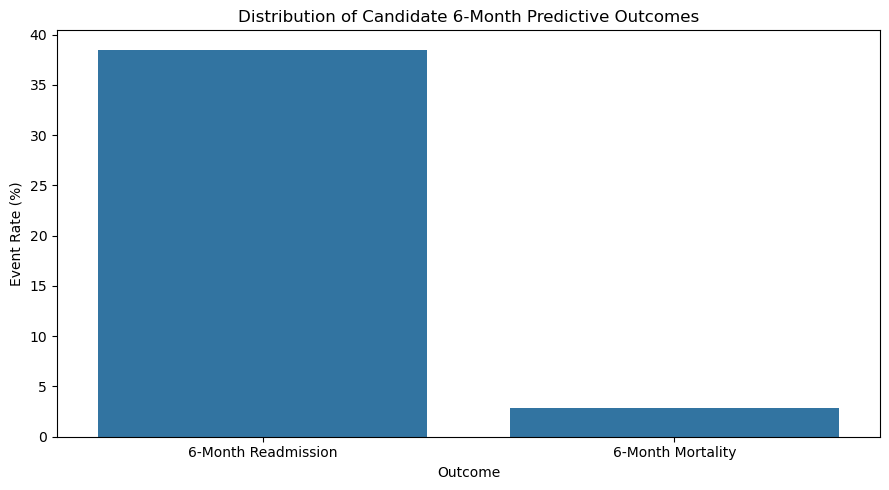

In [152]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=outcome_summary,
    x="Outcome",
    y="Event Rate (%)"
)

plt.title(
    "Distribution of Candidate 6-Month Predictive Outcomes"
)

plt.xlabel("Outcome")
plt.ylabel("Event Rate (%)")

plt.tight_layout()
plt.show()

**Check the candidate features**

In [153]:
candidate_features = [
    "nyha_cardiac_function_classification",
    "killip_grade",
    "brain_natriuretic_peptide",
    "glomerular_filtration_rate",
    "comorbidity_burden"
]

df[candidate_features].describe().T

,count,mean,std,min,25%,50%,75%,max
nyha_cardiac_function_classification,"2,008.000",3.131,0.682,2.000,3.000,3.000,4.000,4.000
killip_grade,"2,008.000",1.993,0.760,1.000,1.000,2.000,2.000,4.000
brain_natriuretic_peptide,"1,973.000","1,280.437","1,354.160",2.690,303.940,753.030,"1,738.520","5,000.000"
glomerular_filtration_rate,"1,945.000",68.664,36.612,3.130,41.600,64.790,90.120,281.010
comorbidity_burden,"2,008.000",1.054,0.432,0.000,1.000,1.000,1.000,3.000


**Compare candidate features by 6-month readmission**

**This establishes whether the Category 3 variables show meaningful differences across the outcome groups**

In [154]:
for feature in candidate_features:

    print("\n" + "="*60)
    print(feature)

    print(
        df.groupby("re_admission_within_6_months")[feature]
        .agg(["count", "mean", "median"])
        .round(2)
    )


nyha_cardiac_function_classification
                              count  mean  median
re_admission_within_6_months                     
0                              1235 3.070   3.000
1                               773 3.220   3.000

killip_grade
                              count  mean  median
re_admission_within_6_months                     
0                              1235 1.990   2.000
1                               773 1.990   2.000

brain_natriuretic_peptide
                              count      mean  median
re_admission_within_6_months                         
0                              1217 1,245.600 722.000
1                               756 1,336.510 855.090

glomerular_filtration_rate
                              count   mean  median
re_admission_within_6_months                      
0                              1192 71.390  69.000
1                               753 64.350  57.720

comorbidity_burden
                              count  mean  median
re_

**Create an interpretable combined risk framework**

In [155]:
from sklearn.preprocessing import StandardScaler

risk_features = [
    "nyha_cardiac_function_classification",
    "killip_grade",
    "log_bnp",
    "glomerular_filtration_rate",
    "comorbidity_burden"
]

risk_data = df[risk_features].copy()

risk_data = risk_data.fillna(
    risk_data.median()
)

scaler = StandardScaler()

risk_scaled = scaler.fit_transform(risk_data)

risk_scaled_df = pd.DataFrame(
    risk_scaled,
    columns=risk_features,
    index=df.index
)

**Important consideration for GFR**: Higher GFR generally represents better renal function, while higher BNP represents greater cardiac stress. Therefore, if you are creating a simple risk score, reverse the direction of GFR:

In [156]:
risk_scaled_df["renal_risk"] = (
    -risk_scaled_df["glomerular_filtration_rate"]
)

In [157]:
df["integrated_risk_score"] = (
    risk_scaled_df[
        "nyha_cardiac_function_classification"
    ]
    +
    risk_scaled_df["killip_grade"]
    +
    risk_scaled_df["log_bnp"]
    +
    risk_scaled_df["renal_risk"]
    +
    risk_scaled_df["comorbidity_burden"]
)

df["integrated_risk_score"].describe()

count   2,008.000
mean        0.000
std         2.724
min        -9.674
25%        -1.798
50%        -0.052
75%         1.842
max         9.170
Name: integrated_risk_score, dtype: float64

**Divide patients into lower- and higher-risk groups**

In [158]:
risk_cutoff = df["integrated_risk_score"].median()

df["Risk_Group"] = np.where(
    df["integrated_risk_score"] >= risk_cutoff,
    "Higher Risk",
    "Lower Risk"
)

df["Risk_Group"].value_counts()

Risk_Group
Lower Risk     1004
Higher Risk    1004
Name: count, dtype: int64

**Examine observed outcomes by risk group**

**Readmission**

In [159]:
readmission_by_risk = (
    df.groupby("Risk_Group")
      ["re_admission_within_6_months"]
      .agg(
          Patients="count",
          Readmissions="sum",
          Readmission_Rate="mean"
      )
)

readmission_by_risk["Readmission_Rate"] *= 100

readmission_by_risk.round(2)

,Patients,Readmissions,Readmission_Rate
Risk_Group,,,
Higher Risk,1004,425,42.330
Lower Risk,1004,348,34.660


**Mortality**

In [160]:
mortality_by_risk = (
    df.groupby("Risk_Group")
      ["death_within_6_months"]
      .agg(
          Patients="count",
          Deaths="sum",
          Mortality_Rate="mean"
      )
)

mortality_by_risk["Mortality_Rate"] *= 100

mortality_by_risk.round(2)

,Patients,Deaths,Mortality_Rate
Risk_Group,,,
Higher Risk,1004,41,4.080
Lower Risk,1004,16,1.590


**Create the Category 3 → Category 4 summary table**

In [161]:
category_bridge = pd.DataFrame({
    "Candidate Outcome": [
        "6-Month Readmission",
        "6-Month Mortality"
    ],
    
    "Events": [
        df["re_admission_within_6_months"].sum(),
        df["death_within_6_months"].sum()
    ],
    
    "Event Rate (%)": [
        df["re_admission_within_6_months"].mean() * 100,
        df["death_within_6_months"].mean() * 100
    ],
    
    "Predictive Role": [
        "Primary predictive target",
        "Secondary candidate outcome"
    ]
})

category_bridge.round(2)

,Candidate Outcome,Events,Event Rate (%),Predictive Role
0,6-Month Readmission,773,38.500,Primary predictive target
1,6-Month Mortality,57,2.840,Secondary candidate outcome


In [162]:
chart_data = pd.DataFrame({
    "Risk Group": [
        "Lower Risk",
        "Higher Risk",
        "Lower Risk",
        "Higher Risk"
    ],
    
    "Outcome": [
        "6-Month Readmission",
        "6-Month Readmission",
        "6-Month Mortality",
        "6-Month Mortality"
    ],
    
    "Rate (%)": [
        readmission_by_risk.loc[
            "Lower Risk", "Readmission_Rate"
        ],
        readmission_by_risk.loc[
            "Higher Risk", "Readmission_Rate"
        ],
        mortality_by_risk.loc[
            "Lower Risk", "Mortality_Rate"
        ],
        mortality_by_risk.loc[
            "Higher Risk", "Mortality_Rate"
        ]
    ]
})

chart_data

,Risk Group,Outcome,Rate (%)
0,Lower Risk,6-Month Readmission,34.661
1,Higher Risk,6-Month Readmission,42.331
2,Lower Risk,6-Month Mortality,1.594
3,Higher Risk,6-Month Mortality,4.084


**Visualize the integrated risk groups**

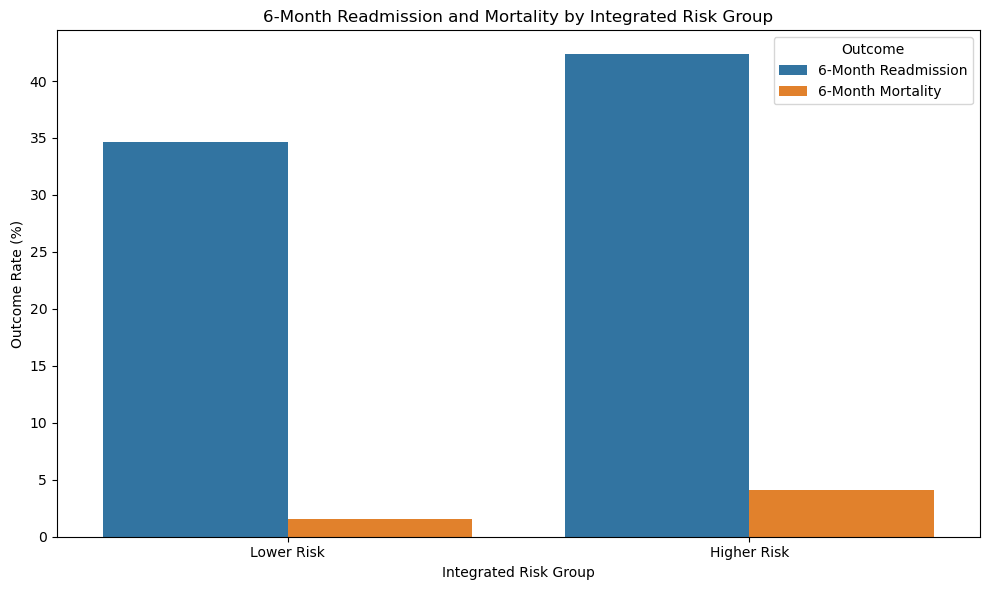

In [163]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=chart_data,
    x="Risk Group",
    y="Rate (%)",
    hue="Outcome"
)

plt.title(
    "6-Month Readmission and Mortality by Integrated Risk Group"
)

plt.xlabel("Integrated Risk Group")
plt.ylabel("Outcome Rate (%)")

plt.tight_layout()
plt.show()

**Finding**: The Category 3 analysis identified cardiac severity, BNP, renal function, and comorbidity burden as candidate features for an integrated risk-stratification framework. Examination of the 6-month outcome distribution shows that readmission is more frequently observed than mortality, providing a larger event group for predictive modeling.

**Conclusion**: The Category 3 findings provide an analytical basis for carrying the selected variables into Category 4. Because 6-month readmission has a larger observed event group than 6-month mortality, it represents the more workable primary predictive target in this dataset. The integrated framework combining NYHA, Killip, BNP, renal function, and comorbidity burden can therefore be formally evaluated in Category 4 using cross-validated predictive-performance measures. The exploratory risk score should be treated as a framework for analysis rather than a validated clinical scoring system.

## Prescriptive Analysis — Summary and Conclusion

### Summary

The prescriptive analysis translated the descriptive findings into actionable questions around **hospitalization, treatment complexity, readmission, and clinical risk factors**.

Key findings from the analysis include:

* **Medication burden:** Higher observed medication burden was consistently associated with longer hospitalization. The association remained nearly unchanged after accounting for **NYHA and Killip admission severity**, suggesting that medication burden provides additional information about treatment complexity.
* **Prolonged hospitalization:** Patients in the highest medication-burden group had a **46.9% prolonged-stay rate**, compared with **22.4%** in the lowest group. Higher medication burden was also associated with greater odds of prolonged hospitalization after adjustment for admission severity.
* **Readmission:** Within NYHA severity groups, medication burden did not show statistically significant differences in 6-month readmission, suggesting that medication count alone should not be used as a standalone readmission indicator.
* **Sodium:** Lower sodium was associated with higher 28-day readmission. This relationship remained statistically significant after accounting for NYHA and Killip, indicating that sodium provides additional information beyond these admission-severity measures.
* **Renal function:** Lower GFR was associated with a substantially higher observed rate of prolonged hospitalization, highlighting renal function as an important factor for hospitalization and resource planning.
* **Discharge destination:** Six-month readmission rates differed significantly by discharge destination (**χ² = 20.08, p < 0.001**), with the highest observed rate among patients discharged to a healthcare facility (**41.1%**).

### Overall Conclusion

The prescriptive analysis indicates that **hospitalization and readmission outcomes are associated with multiple dimensions of patient complexity**, rather than a single factor. Medication burden, admission severity, sodium level, renal function, and discharge destination each provide different information about observed hospitalization or readmission patterns.

These findings can support practical decisions such as **prioritizing resource planning for patients with higher treatment complexity, considering renal function and sodium during discharge planning, and using discharge destination to inform post-discharge follow-up planning**.

Importantly, the analysis identifies **associations and observed patterns rather than causal effects**. Therefore, these factors should be considered together with clinical judgment rather than used as standalone decision rules.

### Transition to Predictive Analysis

The prescriptive findings identify several measurable factors associated with hospitalization and readmission outcomes. The next step is to determine whether these factors can be **combined into predictive models** to estimate patient-level risk and evaluate how well the resulting models distinguish higher-risk patients.
